In [96]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
import xgboost as xgb


# ======================
# 1. Data Loading & Preprocessing
# ======================

In [99]:
file_path = "./data.csv"
df = pd.read_csv(file_path, encoding="latin1")

In [101]:
# Identify measurement columns
measurement_cols = [col for col in df.columns if "meters below ground level" in col]

In [103]:
# Define identifier columns
id_vars = ['Sr. No.', 'State_Name_With_LGD_Code', 'District_Name_With_LGD_Code', 
           'Block_Name_With_LGD_Code', 'GP_Name_With_LGD_Code', 'Village', 
           'Site_Name', 'TYPE', 'SOURCE', 'Well_ID', 'Latitude', 'Longitude', 
           'Well_Depth (meters)', 'Aquifer']


In [105]:
# Convert wide format to long (tidy) format
df_long = pd.melt(df, id_vars=id_vars, value_vars=measurement_cols, 
                  var_name='Measurement', value_name='Groundwater_Level')

In [107]:
# Extract Season and Year from the measurement column using regex
df_long[['Season', 'Year']] = df_long['Measurement'].str.extract(r'(Pre-monsoon|Post-monsoon)_(\d{4})')
df_long['Year'] = df_long['Year'].astype(int)


In [109]:
# Convert groundwater levels to numeric; non-numeric values like "Dry" become NaN
df_long['Groundwater_Level'] = pd.to_numeric(df_long['Groundwater_Level'], errors='coerce')

In [111]:
# Create a representative Month column: assume March (3) for Pre-monsoon, September (9) for Post-monsoon
def get_month(season):
    return 3 if season == "Pre-monsoon" else 9

df_long['Month'] = df_long['Season'].apply(get_month)
df_long['Date'] = pd.to_datetime(dict(year=df_long['Year'], month=df_long['Month'], day=1))
df_long.sort_values(by=['Site_Name', 'Date'], inplace=True)

# ======================
# 2. Select a Site and Clean Data
# ======================

In [114]:
# Select one site (the one with the maximum number of measurements)
site_counts = df_long.groupby('Site_Name')['Groundwater_Level'].count()
selected_site = site_counts.idxmax()
print("Selected Site:", selected_site)
df_site = df_long[df_long['Site_Name'] == selected_site].copy()
df_site.sort_values(by='Date', inplace=True)
df_site.reset_index(drop=True, inplace=True)

Selected Site: In the Village


In [116]:
# Interpolate missing groundwater level values
df_site['Groundwater_Level'] = df_site['Groundwater_Level'].interpolate()

In [118]:
# Normalize groundwater levels using MinMaxScaler
scaler = MinMaxScaler()
df_site['Groundwater_Level_scaled'] = scaler.fit_transform(df_site[['Groundwater_Level']])

# ======================
# 3. Feature Engineering
# ======================

In [121]:
# Create lag features (lags 1, 2, and 3) and a rolling mean (window=2)
for lag in [1, 2, 3]:
    df_site[f'lag_{lag}'] = df_site['Groundwater_Level_scaled'].shift(lag)
df_site['rolling_mean_2'] = df_site['Groundwater_Level_scaled'].rolling(window=2).mean()

In [123]:
# Create time-based features: use Year and Month as additional features
df_site['Year_feat'] = df_site['Year']
df_site['Month_feat'] = df_site['Month']

In [125]:
# Drop rows with NaN values created due to shifting/rolling
df_site.dropna(inplace=True)

In [127]:
# Define features and target variable
features = ['lag_1', 'lag_2', 'lag_3', 'rolling_mean_2', 'Year_feat', 'Month_feat']
target = 'Groundwater_Level_scaled'
X = df_site[features].values
y = df_site[target].values

# ======================
# 4. Data Splitting
# ======================

In [130]:
# Split the dataset chronologically: 70% training, 15% validation, 15% test
n = len(df_site)
train_end = int(0.7 * n)
val_end = int(0.85 * n)

X_train, y_train = X[:train_end], y[:train_end]
X_val, y_val = X[train_end:val_end], y[train_end:val_end]
X_test, y_test = X[val_end:], y[val_end:]

# ======================
# 5. Model Training
# ======================

# --- XGBoost Model ---

In [136]:
# XGBoost uses the structured (non-sequence) features
model_xgb = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, 
                             max_depth=3, learning_rate=0.1, random_state=42)
model_xgb.fit(X_train, y_train)
xgb_pred = model_xgb.predict(X_test)

# Because our LSTM sequence data starts at an offset (window_size),
# align XGBoost predictions by trimming the first window_size entries.
xgb_pred_aligned = xgb_pred[window_size:]

# ======================
# 6. LSTM Model 
# ======================


In [158]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [160]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

In [162]:
file_path = "./data.csv"
df = pd.read_csv(file_path, encoding="latin1")
# Convert 2022 columns to numeric
df['Post-monsoon_2022 (meters below ground level)'] = pd.to_numeric(df['Post-monsoon_2022 (meters below ground level)'], errors='coerce')

In [164]:
# Define the time-series columns for groundwater levels from 2015 to 2021.
time_series_cols = [
    'Pre-monsoon_2015 (meters below ground level)',
    'Post-monsoon_2015 (meters below ground level)',
    'Pre-monsoon_2016 (meters below ground level)',
    'Post-monsoon_2016 (meters below ground level)',
    'Pre-monsoon_2017 (meters below ground level)',
    'Post-monsoon_2017 (meters below ground level)',
    'Pre-monsoon_2018 (meters below ground level)',
    'Post-monsoon_2018 (meters below ground level)',
    'Pre-monsoon_2019 (meters below ground level)',
    'Post-monsoon_2019 (meters below ground level)',
    'Pre-monsoon_2020 (meters below ground level)',
    'Post-monsoon_2020 (meters below ground level)',
    'Pre-monsoon_2021 (meters below ground level)',
    'Post-monsoon_2021 (meters below ground level)'
]
target = 'Post-monsoon_2022 (meters below ground level)'

In [166]:
# Drop rows with missing values in the sequence or target columns
df_lstm = df.dropna(subset=time_series_cols + [target])
print(f"LSTM model data records: {df_lstm.shape[0]}")

LSTM model data records: 2168


In [168]:
# Extract the sequences and target values.
X_seq = df_lstm[time_series_cols].values
y_seq = df_lstm[target].values 

In [170]:
# Optional: Scale the features and target for better training.
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

In [172]:

X_seq_scaled = scaler_X.fit_transform(X_seq)
y_seq_scaled = scaler_y.fit_transform(y_seq.reshape(-1, 1))



In [174]:
# Reshape X to be [samples, time steps, features]
X_seq_scaled = X_seq_scaled.reshape(X_seq_scaled.shape[0], len(time_series_cols), 1)



In [176]:
# Split the data into training and testing sets
from sklearn.model_selection import train_test_split
X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(X_seq_scaled, y_seq_scaled, test_size=0.2, random_state=42)


In [178]:
model = Sequential()
model.add(LSTM(50, activation='relu', input_shape=(len(time_series_cols), 1), return_sequences=True))
model.add(Dropout(0.2))
model.add(LSTM(25, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1))

model.compile(optimizer='adam', loss='mse')
model.summary()


C:\D Drive\Anaconda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_5 (LSTM)                        │ (None, 14, 50)              │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 14, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_6 (LSTM)                        │ (None, 25)                  │           7,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 25)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 18,026 (70.41 KB)

 Trainable params: 18,026 (70.41 KB)

 Non-trainable params: 0 (0.00 B)

In [180]:

# Train the model
history = model.fit(X_train_seq, y_train_seq, epochs=50, batch_size=32, validation_split=0.1, verbose=1)


Epoch 1/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 4s 17ms/step - loss: 0.0240 - val_loss: 0.0043
Epoch 2/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 21ms/step - loss: 0.0058 - val_loss: 0.0031
Epoch 3/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - loss: 0.0051 - val_loss: 0.0027
Epoch 4/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - loss: 0.0052 - val_loss: 0.0027
Epoch 5/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0049 - val_loss: 0.0026
Epoch 6/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 0.0042 - val_loss: 0.0024
Epoch 7/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0055 - val_loss: 0.0022
Epoch 8/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0044 - val_loss: 0.0023
Epoch 9/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0054 - val_loss: 0.0019
Epoch 10/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 0.0036 - val_loss: 0.0019
Epoch 11/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0034 - val_loss: 0.0014
Epoch 12/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0030 

In [181]:

# ----- Evaluate the LSTM Model -----
loss = model.evaluate(X_test_seq, y_test_seq)
print("\nLSTM Model Test Loss (MSE):", loss)


14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - loss: 9.3121e-04

LSTM Model Test Loss (MSE): 0.0010215960210189223


In [185]:

# Make predictions and invert scaling for interpretability
y_pred_seq_scaled = model.predict(X_test_seq)
y_pred_seq = scaler_y.inverse_transform(y_pred_seq_scaled)
y_test_seq_inv = scaler_y.inverse_transform(y_test_seq)


14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step


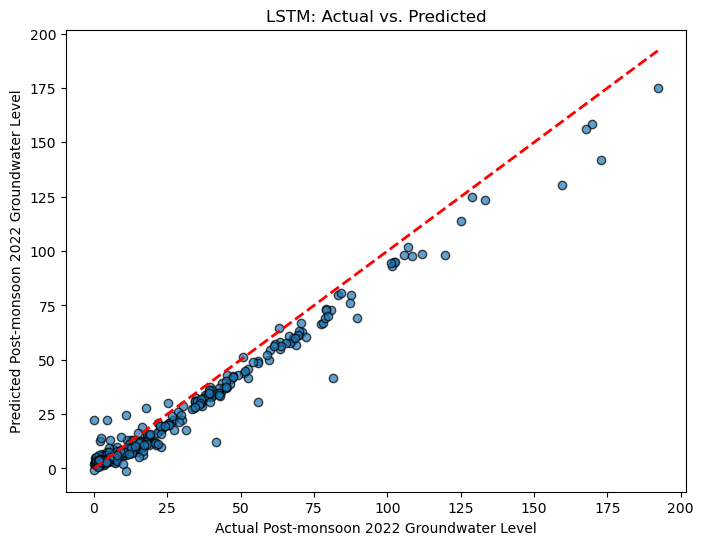

In [187]:
    
    # Plot Actual vs. Predicted values
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test_seq_inv, y_pred_seq, alpha=0.7, edgecolors='k')
    plt.plot([y_test_seq_inv.min(), y_test_seq_inv.max()], [y_test_seq_inv.min(), y_test_seq_inv.max()], 'r--', lw=2)
    plt.xlabel("Actual Post-monsoon 2022 Groundwater Level")
    plt.ylabel("Predicted Post-monsoon 2022 Groundwater Level")
    plt.title("LSTM: Actual vs. Predicted")
    plt.show()

In [189]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

y_pred_seq = scaler_y.inverse_transform(y_pred_seq_scaled)
y_test_seq_inv = scaler_y.inverse_transform(y_test_seq)

mse_unscaled = mean_squared_error(y_test_seq_inv, y_pred_seq)
rmse_unscaled = np.sqrt(mse_unscaled)
mae_unscaled = mean_absolute_error(y_test_seq_inv, y_pred_seq)
r2_unscaled = r2_score(y_test_seq_inv, y_pred_seq)

print("Unscaled MSE:", mse_unscaled)
print("Unscaled RMSE:", rmse_unscaled)
print("Unscaled MAE:", mae_unscaled)
print("Unscaled R²:", r2_unscaled)


Unscaled MSE: 37.71505269288216
Unscaled RMSE: 6.14125823369138
Unscaled MAE: 4.086032519269099
Unscaled R²: 0.9601747042156221


# ======================
# 6. Hybrid Model Integration
# ======================


# ======================
# 7. Evaluation
# ======================

In [191]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# --- Hybrid Integration using Weighted Average ---

In [210]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# ===== Unified Data Splitting for Both Models =====
# Assume df_site is your processed DataFrame for the selected site with engineered features.
# 'features' and 'target' are as defined previously.
features = ['lag_1', 'lag_2', 'lag_3', 'rolling_mean_2', 'Year_feat', 'Month_feat']
target = 'Groundwater_Level_scaled'

# Get the feature and target arrays
X_all = df_site[features].values
y_all = df_site[target].values

n = len(df_site)
indices = np.arange(n)
train_end = int(0.7 * n)
val_end = int(0.85 * n)
test_idx = indices[val_end:]  # These indices will be used for both models

# Split for XGBoost
X_train_xgb = X_all[:train_end]
y_train_xgb = y_all[:train_end]
X_test_xgb = X_all[test_idx]
y_test_xgb = y_all[test_idx]

# Train XGBoost Model
model_xgb = xgb.XGBRegressor(objective='reg:squarederror', n_estimators=100, 
                             max_depth=3, learning_rate=0.1, random_state=42)
model_xgb.fit(X_train_xgb, y_train_xgb)
xgb_pred_scaled = model_xgb.predict(X_test_xgb)
# Assuming your target scaling is the same for both models:
xgb_pred = xgb_pred_scaled  # (Unscale if necessary using scaler_y.inverse_transform)

# ===== Prepare Data for LSTM =====
# For LSTM, we create sequences from the same engineered features.
# We'll use a sliding window; here, window_size is the number of time steps per sample.
window_size = 3

def create_sequences(data, window_size):
    X_seq, y_seq = [], []
    for i in range(len(data) - window_size):
        X_seq.append(data[i:i+window_size])
        y_seq.append(data[i+window_size])
    return np.array(X_seq), np.array(y_seq)

# Create sequences from the entire dataset
X_seq_full, y_seq_full = create_sequences(X_all, window_size)

# Determine the corresponding test indices for sequences.
# In the original data, a sequence ending at index i corresponds to the target at i.
# We want those targets to be in our unified test set (i.e., indices in test_idx).
# Adjust the sequence indices: valid sequence targets are from index 'window_size' to len(y_all)-1.
seq_target_indices = np.arange(window_size, len(y_all))
# Find sequence indices where the target index is in test_idx:
test_seq_mask = np.isin(seq_target_indices, test_idx)
X_test_lstm = X_seq_full[test_seq_mask]
y_test_lstm = y_seq_full[test_seq_mask]

# Now, train your LSTM model using your chosen split.
# (Here, we assume you've already trained your LSTM; if not, train it using the same unified split.)
model = Sequential([
    LSTM(50, activation='relu', input_shape=(window_size, 1), return_sequences=True),
    Dropout(0.2),
    LSTM(25, activation='relu'),
    Dropout(0.2),
    Dense(1)
])
model.compile(optimizer='adam', loss='mse')
# (Train the model on your unified training data for LSTM; omitted for brevity)

# Predict on the unified LSTM test set:
lstm_pred_scaled = model.predict(X_test_lstm).flatten()
# Invert scaling for LSTM predictions if needed:
lstm_pred = scaler_y.inverse_transform(lstm_pred_scaled.reshape(-1,1)).flatten()

# Also get the true test values in original units:
y_test_lstm_inv = scaler_y.inverse_transform(y_test_lstm.reshape(-1,1)).flatten()

# ===== Hybrid Integration =====
# Now both models have predictions on the same test samples.
# Ensure xgb_pred and lstm_pred have the same length.
print("XGBoost test predictions shape:", xgb_pred.shape)  # Should match LSTM test set size.
print("LSTM test predictions shape:", lstm_pred.shape)

# For demonstration, let's assume both are now aligned (e.g., shape (n_test_aligned,)).
# If necessary, you might have to re-index xgb_pred to correspond to the same samples.
# Here, we'll use a weighted average:
w = 0.5
# IMPORTANT: Make sure xgb_pred is re-aligned to the same test samples as the LSTM predictions.
# For example, if the unified test set size is n_test_aligned, then xgb_pred_aligned should be:
xgb_pred_aligned = xgb_pred  # Replace with proper alignment if needed.

y_pred_hybrid = w * lstm_pred + (1 - w) * xgb_pred_aligned

# Evaluate the hybrid model:
mse_hybrid = mean_squared_error(y_test_lstm_inv, y_pred_hybrid)
rmse_hybrid = np.sqrt(mse_hybrid)
mae_hybrid = mean_absolute_error(y_test_lstm_inv, y_pred_hybrid)
r2_hybrid = r2_score(y_test_lstm_inv, y_pred_hybrid)

print("\nHybrid Model (Weighted Average) Performance:")
print("MSE:", mse_hybrid)
print("RMSE:", rmse_hybrid)
print("MAE:", mae_hybrid)
print("R²:", r2_hybrid)


C:\D Drive\Anaconda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


ValueError: Exception encountered when calling LSTMCell.call().

[1mDimensions must be equal, but are 6 and 1 for '{{node sequential_4_1/lstm_7_1/lstm_cell_1/MatMul}} = MatMul[T=DT_FLOAT, grad_a=false, grad_b=false, transpose_a=false, transpose_b=false](sequential_4_1/lstm_7_1/strided_slice_1, sequential_4_1/lstm_7_1/lstm_cell_1/Cast/ReadVariableOp)' with input shapes: [32,6], [1,200].[0m

Arguments received by LSTMCell.call():
  • inputs=tf.Tensor(shape=(32, 6), dtype=float32)
  • states=('tf.Tensor(shape=(32, 50), dtype=float32)', 'tf.Tensor(shape=(32, 50), dtype=float32)')
  • training=False

# hybrid


Loading and preprocessing data...

Preparing site data...
Selected Site: In the Village

Preparing model data...
Training set: (445, 6), Validation set: (96, 6), Test set: (96, 6)
Feature names: ['lag_1', 'lag_2', 'lag_3', 'rolling_mean_2', 'Year_feat', 'Month_feat']

Preparing LSTM sequences...
LSTM input shapes:
Train: (442, 3, 6), (442,)
Validation: (93, 3, 6), (93,)
Test: (93, 3, 6), (93,)

Training XGBoost model...

Training LSTM model...
LSTM input shape: (timesteps=3, features=6)


C:\D Drive\Anaconda\Lib\site-packages\xgboost\core.py:158: UserWarning: [15:29:21] WARNING: C:\buildkite-agent\builds\buildkite-windows-cpu-autoscaling-group-i-08cbc0333d8d4aae1-1\xgboost\xgboost-ci-windows\src\learner.cc:740: 
Parameters: { "n_estimators" } are not used.

  warnings.warn(smsg, UserWarning)
C:\D Drive\Anaconda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_15 (LSTM)                       │ (None, 3, 50)               │          11,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_14 (Dropout)                 │ (None, 3, 50)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_16 (LSTM)                       │ (None, 25)                  │           7,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_15 (Dropout)                 │ (None, 25)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_10 (Dense)                     │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,026 (74.32 KB)

 Trainable params: 19,026 (74.32 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 10s 94ms/step - loss: 3759.2812 - val_loss: 64.9340
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - loss: 1161.6818 - val_loss: 1.0269
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 518.8557 - val_loss: 15.3471
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 411.0206 - val_loss: 19.4749
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 306.0105 - val_loss: 10.2032
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 23ms/step - loss: 258.3537 - val_loss: 3.6252
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 195.1967 - val_loss: 0.1836
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 107.8894 - val_loss: 0.1822
Epoch 9/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 102.8432 - val_loss: 0.1829
Epoch 10/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 104.4820 - val_loss: 0.2110
Epoch 11/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 69.2028 - val_loss: 0.2659
Epoch 12/50
14/14 ━━━━━━━━━━━━

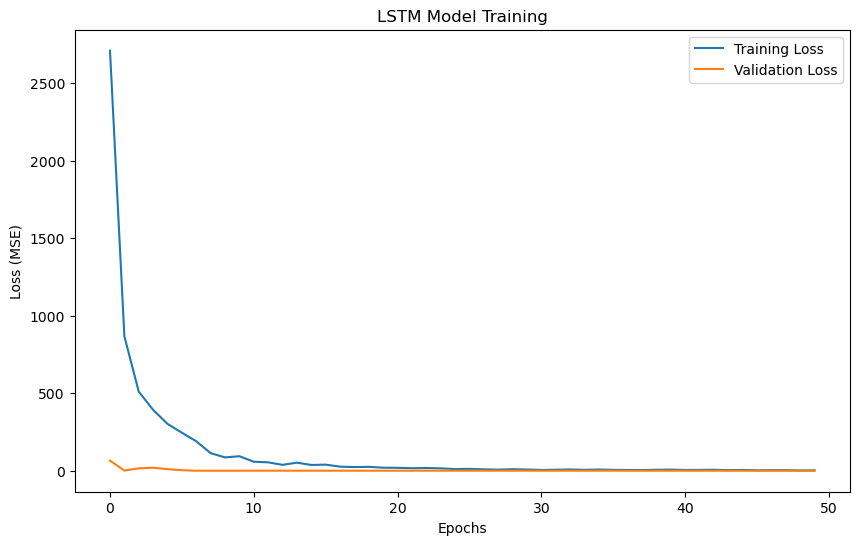


Creating hybrid model...
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 370ms/step
Best Weight: 1.00 | Hybrid RMSE: 0.0305 | MAE: 0.0157 | R²: 0.9384

Training complete. Models are ready for prediction.


In [220]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import xgboost as xgb

# ======================
# 1. Data Loading & Preprocessing
# ======================

def load_and_preprocess_data(file_path):
    # Load the dataset
    df = pd.read_csv(file_path, encoding="latin1")
    
    # Identify measurement columns (assuming they all have "meters below ground level" in the name)
    measurement_cols = [col for col in df.columns if "meters below ground level" in col]
    
    # Define identifier columns
    id_vars = ['Sr. No.', 'State_Name_With_LGD_Code', 'District_Name_With_LGD_Code', 
               'Block_Name_With_LGD_Code', 'GP_Name_With_LGD_Code', 'Village', 
               'Site_Name', 'TYPE', 'SOURCE', 'Well_ID', 'Latitude', 'Longitude', 
               'Well_Depth (meters)', 'Aquifer']
    
    # Convert wide format to long (tidy) format
    df_long = pd.melt(df, id_vars=id_vars, value_vars=measurement_cols, 
                      var_name='Measurement', value_name='Groundwater_Level')
    
    # Extract Season and Year from the measurement column using regex
    df_long[['Season', 'Year']] = df_long['Measurement'].str.extract(r'(Pre-monsoon|Post-monsoon)_(\d{4})')
    df_long['Year'] = df_long['Year'].astype(int)
    
    # Convert groundwater levels to numeric; non-numeric values like "Dry" become NaN
    df_long['Groundwater_Level'] = pd.to_numeric(df_long['Groundwater_Level'], errors='coerce')
    
    # Create a representative Month column: assume March (3) for Pre-monsoon, September (9) for Post-monsoon
    def get_month(season):
        return 3 if season == "Pre-monsoon" else 9
    
    df_long['Month'] = df_long['Season'].apply(get_month)
    df_long['Date'] = pd.to_datetime(dict(year=df_long['Year'], month=df_long['Month'], day=1))
    df_long.sort_values(by=['Site_Name', 'Date'], inplace=True)
    
    return df_long, measurement_cols

# ======================
# 2. Site Selection and Feature Engineering
# ======================

def prepare_site_data(df_long):
    # Select one site (the one with the maximum number of measurements)
    site_counts = df_long.groupby('Site_Name')['Groundwater_Level'].count()
    selected_site = site_counts.idxmax()
    print("Selected Site:", selected_site)
    
    df_site = df_long[df_long['Site_Name'] == selected_site].copy()
    df_site.sort_values(by='Date', inplace=True)
    df_site.reset_index(drop=True, inplace=True)
    
    # Interpolate missing groundwater level values
    df_site['Groundwater_Level'] = df_site['Groundwater_Level'].interpolate()
    
    # Normalize groundwater levels using MinMaxScaler
    scaler = MinMaxScaler()
    df_site['Groundwater_Level_scaled'] = scaler.fit_transform(df_site[['Groundwater_Level']])
    
    # Create lag features (lags 1, 2, and 3) and a rolling mean (window=2)
    for lag in [1, 2, 3]:
        df_site[f'lag_{lag}'] = df_site['Groundwater_Level_scaled'].shift(lag)
    df_site['rolling_mean_2'] = df_site['Groundwater_Level_scaled'].rolling(window=2).mean()
    
    # Create time-based features: use Year and Month as additional features
    df_site['Year_feat'] = df_site['Year']
    df_site['Month_feat'] = df_site['Month']
    
    # Drop rows with NaN values created due to shifting/rolling
    df_site_clean = df_site.dropna().copy()
    
    return df_site_clean, scaler

# ======================
# 3. Data Preparation for Both Models
# ======================

def prepare_model_data(df_site):
    # Define features and target variable
    features = ['lag_1', 'lag_2', 'lag_3', 'rolling_mean_2', 'Year_feat', 'Month_feat']
    target = 'Groundwater_Level_scaled'
    
    X = df_site[features].values
    y = df_site[target].values
    
    # Common train/validation/test split for both models (chronological)
    n = len(df_site)
    train_end = int(0.7 * n)
    val_end = int(0.85 * n)
    
    X_train, y_train = X[:train_end], y[:train_end]
    X_val, y_val = X[train_end:val_end], y[train_end:val_end]
    X_test, y_test = X[val_end:], y[val_end:]
    
    print(f"Training set: {X_train.shape}, Validation set: {X_val.shape}, Test set: {X_test.shape}")
    print(f"Feature names: {features}")
    
    return X_train, y_train, X_val, y_val, X_test, y_test, features

# ======================
# 4. LSTM Data Preparation
# ======================

def prepare_lstm_data(X_train, y_train, X_val, y_val, X_test, y_test):
    # Create sequences for LSTM (window size of 3)
    window_size = 3
    
    def create_sequences(X, y, window_size):
        Xs, ys = [], []
        for i in range(len(X) - window_size):
            Xs.append(X[i:(i+window_size)])
            ys.append(y[i+window_size])
        return np.array(Xs), np.array(ys)
    
    X_train_seq, y_train_seq = create_sequences(X_train, y_train, window_size)
    X_val_seq, y_val_seq = create_sequences(X_val, y_val, window_size)
    X_test_seq, y_test_seq = create_sequences(X_test, y_test, window_size)
    
    print("LSTM input shapes:")
    print(f"Train: {X_train_seq.shape}, {y_train_seq.shape}")
    print(f"Validation: {X_val_seq.shape}, {y_val_seq.shape}")
    print(f"Test: {X_test_seq.shape}, {y_test_seq.shape}")
    
    return X_train_seq, y_train_seq, X_val_seq, y_val_seq, X_test_seq, y_test_seq, window_size

# ======================
# 5. XGBoost Model
# ======================


import xgboost as xgb

def train_xgboost_model(X_train, y_train, X_val, y_val):
    """
    Train an XGBoost model using early stopping.

    Parameters:
        X_train (pd.DataFrame): Training features
        y_train (pd.Series): Training target values
        X_val (pd.DataFrame): Validation features
        y_val (pd.Series): Validation target values

    Returns:
        xgb.Booster: Trained XGBoost model
    """
    # Convert data to DMatrix format
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval = xgb.DMatrix(X_val, label=y_val)

    # Set parameters for XGBoost
    params = {
        'objective': 'reg:squarederror',  # Regression objective
        'max_depth': 3,                   # Maximum depth of trees
        'learning_rate': 0.1,             # Step size shrinkage
        'n_estimators': 100,              # Number of boosting rounds
        'random_state': 42                # Seed for reproducibility
    }

    # Train the model using early stopping
    model_xgb = xgb.train(
        params=params,
        dtrain=dtrain,
        num_boost_round=100,              # Maximum number of boosting rounds
        evals=[(dval, 'validation')],     # Evaluation set for early stopping
        early_stopping_rounds=10,         # Stop if no improvement after 10 rounds
        verbose_eval=False                # Suppress training output
    )

    return model_xgb


# ======================
# 6. LSTM Model
# ======================

def train_lstm_model(X_train_seq, y_train_seq, X_val_seq, y_val_seq):
    # Get input dimensions from the data
    timesteps, features = X_train_seq.shape[1], X_train_seq.shape[2]
    print(f"LSTM input shape: (timesteps={timesteps}, features={features})")
    
    # Define LSTM model with proper input shape
    lstm_model = Sequential([
        LSTM(50, activation='relu', input_shape=(timesteps, features), return_sequences=True),
        Dropout(0.2),
        LSTM(25, activation='relu'),
        Dropout(0.2),
        Dense(1)
    ])
    
    lstm_model.compile(optimizer='adam', loss='mse')
    print(lstm_model.summary())
    
    # Train LSTM
    history = lstm_model.fit(
        X_train_seq, 
        y_train_seq, 
        epochs=50, 
        batch_size=32, 
        validation_data=(X_val_seq, y_val_seq),
        verbose=1
    )
    
    # Plot training history
    plt.figure(figsize=(10, 6))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('LSTM Model Training')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.show()
    
    return lstm_model

# ======================
# 7. Model Evaluation
# ======================

def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{model_name} Model Evaluation:")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R2: {r2:.4f}")
    
    return rmse, mae, r2

# ======================
# 8. Hybrid Model Integration
# ======================

import xgboost as xgb
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def create_hybrid_model(xgb_model, lstm_model, X_test, X_test_seq, y_test, window_size):
    # Convert X_test to DMatrix for XGBoost
    dtest = xgb.DMatrix(X_test)
    xgb_pred = xgb_model.predict(dtest)

    # Get LSTM predictions
    lstm_pred = lstm_model.predict(X_test_seq).flatten()

    # Ensure all arrays have the same length
    min_len = min(len(xgb_pred), len(lstm_pred), len(y_test))
    xgb_pred = xgb_pred[:min_len]
    lstm_pred = lstm_pred[:min_len]
    y_test = y_test[:min_len]

    # Find best weight for hybrid model
    best_weight, best_rmse, best_mae, best_r2 = 0, float("inf"), float("inf"), -float("inf")

    for weight in np.linspace(0, 1, 101):  # Try weights from 0 to 1
        hybrid_pred = (weight * xgb_pred) + ((1 - weight) * lstm_pred)

        rmse = np.sqrt(mean_squared_error(y_test, hybrid_pred))
        mae = mean_absolute_error(y_test, hybrid_pred)
        r2 = r2_score(y_test, hybrid_pred)

        if rmse < best_rmse:
            best_weight, best_rmse, best_mae, best_r2 = weight, rmse, mae, r2

    print(f"Best Weight: {best_weight:.2f} | Hybrid RMSE: {best_rmse:.4f} | MAE: {best_mae:.4f} | R²: {best_r2:.4f}")

    return best_weight, best_rmse, best_mae, best_r2



# ======================
# 9. Prediction Function 
# ======================

def make_predictions(xgb_model, lstm_model, best_weight, new_data, scaler, features, window_size):
    """
    Make predictions with the hybrid model for new data.
    
    Parameters:
    -----------
    xgb_model: Trained XGBoost model
    lstm_model: Trained LSTM model
    best_weight: Weight for LSTM in the hybrid model
    new_data: DataFrame with the required features
    scaler: Scaler used for normalization
    features: List of feature names
    window_size: Window size for LSTM sequences
    
    Returns:
    --------
    predictions: Array of hybrid model predictions
    """
    # Prepare features
    X_new = new_data[features].values
    
    # XGBoost prediction
    xgb_pred = xgb_model.predict(X_new)
    
    # Prepare sequences for LSTM
    X_seq = []
    for i in range(len(X_new) - window_size):
        X_seq.append(X_new[i:(i+window_size)])
    X_seq = np.array(X_seq)
    
    # LSTM prediction
    lstm_pred = lstm_model.predict(X_seq).flatten()
    
    # Align predictions
    xgb_pred_aligned = xgb_pred[window_size:]
    
    # Create hybrid prediction
    hybrid_pred = best_weight * lstm_pred + (1 - best_weight) * xgb_pred_aligned
    
    # Inverse transform if needed
    # hybrid_pred_original = scaler.inverse_transform(hybrid_pred.reshape(-1, 1)).flatten()
    
    return hybrid_pred

# ======================
# 10. Main Function
# ======================

def main(file_path):
    # Load and preprocess data
    print("Loading and preprocessing data...")
    df_long, measurement_cols = load_and_preprocess_data(file_path)
    
    # Prepare site data
    print("\nPreparing site data...")
    df_site, scaler = prepare_site_data(df_long)
    
    # Prepare model data
    print("\nPreparing model data...")
    X_train, y_train, X_val, y_val, X_test, y_test, features = prepare_model_data(df_site)
    
    # Prepare LSTM data
    print("\nPreparing LSTM sequences...")
    X_train_seq, y_train_seq, X_val_seq, y_val_seq, X_test_seq, y_test_seq, window_size = prepare_lstm_data(
        X_train, y_train, X_val, y_val, X_test, y_test
    )
    
    # Train XGBoost model
    print("\nTraining XGBoost model...")
    xgb_model = train_xgboost_model(X_train, y_train, X_val, y_val)
    
    # Train LSTM model
    print("\nTraining LSTM model...")
    lstm_model = train_lstm_model(X_train_seq, y_train_seq, X_val_seq, y_val_seq)
    
    # Create and evaluate hybrid model
    print("\nCreating hybrid model...")
    best_weight, hybrid_rmse, hybrid_mae, hybrid_r2 = create_hybrid_model(
        xgb_model, lstm_model, X_test, X_test_seq, y_test, window_size
    )
    
    # Save model information
    model_info = {
        'xgb_model': xgb_model,
        'lstm_model': lstm_model,
        'best_weight': best_weight,
        'scaler': scaler,
        'features': features,
        'window_size': window_size,
        'hybrid_metrics': {
            'rmse': hybrid_rmse,
            'mae': hybrid_mae,
            'r2': hybrid_r2
        }
    }
    
    print("\nTraining complete. Models are ready for prediction.")
    return model_info

# Example usage
if __name__ == "__main__":
    file_path = "./data.csv"  # Update with your file path
    model_info = main(file_path)
    
    # Example of making a prediction with the trained models
    # Assuming you have new data with the same features
    # new_data = pd.DataFrame(...)  # Your new data
    # predictions = make_predictions(
    #     model_info['xgb_model'], 
    #     model_info['lstm_model'], 
    #     model_info['best_weight'], 
    #     new_data, 
    #     model_info['scaler'], 
    #     model_info['features'], 
    #     model_info['window_size']
    # )

In [238]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import xgboost as xgb

# ======================
# Model Evaluation & Visualization
# ======================

def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    
    print(f"\n{model_name} Model Evaluation:")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R2 Score: {r2:.4f}")
    
    # Visualization
    plt.figure(figsize=(10, 6))
    plt.plot(y_true, label='Actual', marker='o')
    plt.plot(y_pred, label='Predicted', marker='x')
    plt.title(f'{model_name} - Actual vs Predicted')
    plt.xlabel('Time Steps')
    plt.ylabel('Groundwater Level (scaled)')
    plt.legend()
    plt.show()
    
    return rmse, mae, r2

# Function to predict with XGBoost
def predict_xgboost(model_xgb, X_test):
    dtest = xgb.DMatrix(X_test)
    return model_xgb.predict(X_test)

# Function to predict with LSTM
def predict_lstm(lstm_model, X_test_seq):
    return lstm_model.predict(X_test_seq).flatten()

# ======================
# Example Usage after Training Models
# ======================
# Assuming X_test, y_test are prepared for XGBoost
# Assuming X_test_seq, y_test_seq are prepared for LSTM
#
# y_pred_xgb = predict_xgboost(model_xgb, X_test)
# y_pred_lstm = predict_lstm(lstm_model, X_test_seq)
#
# evaluate_model(y_test, y_pred_xgb, "XGBoost")
# evaluate_model(y_test_seq, y_pred_lstm, "LSTM")


In [246]:
print(lstm_model.input_shape)
print(X_test_seq.shape)  # Check test data shape


(None, 3, 6)
(434, 1, 14)


In [248]:
y_pred_xgb = predict_xgboost(model_xgb, X_test)

# X_test_seq = X_test_seq.reshape(X_test_seq.shape[0], 1, X_test_seq.shape[1])  
X_test_seq = X_test_seq.reshape(X_test_seq.shape[0], 3, 6)

y_pred_lstm = predict_lstm(lstm_model, X_test_seq)

evaluate_model(y_test, y_pred_xgb, "XGBoost")
evaluate_model(y_test_seq, y_pred_lstm, "LSTM")

ValueError: cannot reshape array of size 6076 into shape (434,3,6)

# below on has different pipelines for both models

Loading and preprocessing data (long format)...
Selected Site: In the Village
Training set: (445, 6), Validation set: (96, 6), Test set: (96, 6)
Features: ['lag_1', 'lag_2', 'lag_3', 'rolling_mean_2', 'Year_feat', 'Month_feat']

Training XGBoost model...

Training LSTM model using wide format (raw time-series columns)...
LSTM model data records (wide format): 2168


C:\D Drive\Anaconda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_9"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_17 (LSTM)                       │ (None, 14, 50)              │          10,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_16 (Dropout)                 │ (None, 14, 50)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_18 (LSTM)                       │ (None, 25)                  │           7,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_17 (Dropout)                 │ (None, 25)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_11 (Dense)                     │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 18,026 (70.41 KB)

 Trainable params: 18,026 (70.41 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 15s 50ms/step - loss: 0.0278 - val_loss: 0.0046
Epoch 2/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 33ms/step - loss: 0.0062 - val_loss: 0.0050
Epoch 3/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 32ms/step - loss: 0.0062 - val_loss: 0.0030
Epoch 4/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0057 - val_loss: 0.0031
Epoch 5/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0061 - val_loss: 0.0028
Epoch 6/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 31ms/step - loss: 0.0046 - val_loss: 0.0028
Epoch 7/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - loss: 0.0047 - val_loss: 0.0027
Epoch 8/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0055 - val_loss: 0.0036
Epoch 9/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 34ms/step - loss: 0.0047 - val_loss: 0.0028
Epoch 10/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0047 - val_loss: 0.0028
Epoch 11/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - loss: 0.0053 - val_loss: 0.0025
Epoch 12/50
49/49 ━━━━━━━━━━━━━━━━━━━━ 2s 35ms/step - loss: 0.

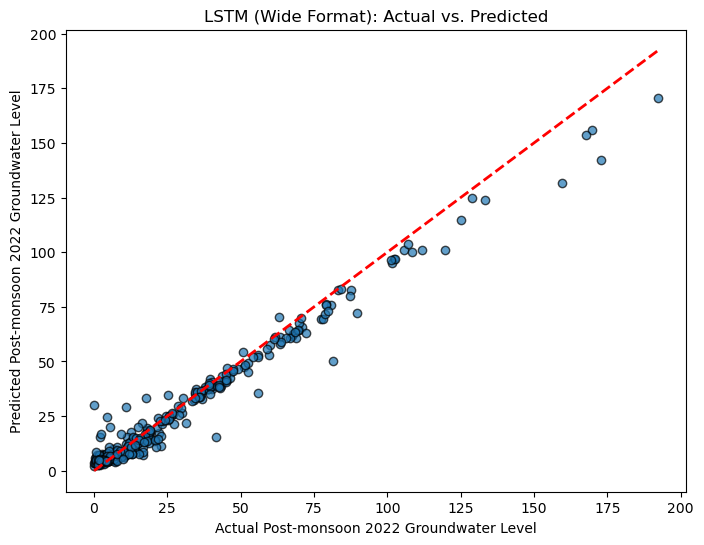


Evaluating XGBoost model (long format branch)...

Note: The new LSTM model was trained on the wide (raw time-series) data, so its outputs are evaluated separately.


In [251]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

# ======================
# 1. Data Loading & Preprocessing for XGBoost & Hybrid Branch
# (Long-format processing)
# ======================

def load_and_preprocess_data(file_path):
    # Load the dataset
    df = pd.read_csv(file_path, encoding="latin1")
    
    # Identify measurement columns (assumes they all have "meters below ground level" in the name)
    measurement_cols = [col for col in df.columns if "meters below ground level" in col]
    
    # Define identifier columns
    id_vars = ['Sr. No.', 'State_Name_With_LGD_Code', 'District_Name_With_LGD_Code', 
               'Block_Name_With_LGD_Code', 'GP_Name_With_LGD_Code', 'Village', 
               'Site_Name', 'TYPE', 'SOURCE', 'Well_ID', 'Latitude', 'Longitude', 
               'Well_Depth (meters)', 'Aquifer']
    
    # Convert wide format to long (tidy) format
    df_long = pd.melt(df, id_vars=id_vars, value_vars=measurement_cols, 
                      var_name='Measurement', value_name='Groundwater_Level')
    
    # Extract Season and Year from the measurement column using regex
    df_long[['Season', 'Year']] = df_long['Measurement'].str.extract(r'(Pre-monsoon|Post-monsoon)_(\d{4})')
    df_long['Year'] = df_long['Year'].astype(int)
    
    # Convert groundwater levels to numeric; non-numeric values become NaN
    df_long['Groundwater_Level'] = pd.to_numeric(df_long['Groundwater_Level'], errors='coerce')
    
    # Create a representative Month column: assume March (3) for Pre-monsoon and September (9) for Post-monsoon
    df_long['Month'] = df_long['Season'].apply(lambda season: 3 if season == "Pre-monsoon" else 9)
    df_long['Date'] = pd.to_datetime(dict(year=df_long['Year'], month=df_long['Month'], day=1))
    df_long.sort_values(by=['Site_Name', 'Date'], inplace=True)
    
    return df_long, measurement_cols

# ======================
# 2. Site Selection and Feature Engineering (for XGBoost branch)
# ======================

def prepare_site_data(df_long):
    # Select one site (the one with the maximum number of measurements)
    site_counts = df_long.groupby('Site_Name')['Groundwater_Level'].count()
    selected_site = site_counts.idxmax()
    print("Selected Site:", selected_site)
    
    df_site = df_long[df_long['Site_Name'] == selected_site].copy()
    df_site.sort_values(by='Date', inplace=True)
    df_site.reset_index(drop=True, inplace=True)
    
    # Interpolate missing groundwater values
    df_site['Groundwater_Level'] = df_site['Groundwater_Level'].interpolate()
    
    # Normalize groundwater levels using MinMaxScaler
    scaler = MinMaxScaler()
    df_site['Groundwater_Level_scaled'] = scaler.fit_transform(df_site[['Groundwater_Level']])
    
    # Create lag features (lags 1, 2, and 3) and a rolling mean (window=2)
    for lag in [1, 2, 3]:
        df_site[f'lag_{lag}'] = df_site['Groundwater_Level_scaled'].shift(lag)
    df_site['rolling_mean_2'] = df_site['Groundwater_Level_scaled'].rolling(window=2).mean()
    
    # Create time-based features: Year and Month as additional features
    df_site['Year_feat'] = df_site['Year']
    df_site['Month_feat'] = df_site['Month']
    
    # Drop rows with NaNs created by shifting/rolling
    df_site_clean = df_site.dropna().copy()
    
    return df_site_clean, scaler

# ======================
# 3. Data Preparation for XGBoost Model (from long-format branch)
# ======================

def prepare_model_data(df_site):
    # Define features and target variable
    features = ['lag_1', 'lag_2', 'lag_3', 'rolling_mean_2', 'Year_feat', 'Month_feat']
    target = 'Groundwater_Level_scaled'
    
    X = df_site[features].values
    y = df_site[target].values
    
    # Chronological train/validation/test split
    n = len(df_site)
    train_end = int(0.7 * n)
    val_end = int(0.85 * n)
    
    X_train, y_train = X[:train_end], y[:train_end]
    X_val, y_val = X[train_end:val_end], y[train_end:val_end]
    X_test, y_test = X[val_end:], y[val_end:]
    
    print(f"Training set: {X_train.shape}, Validation set: {X_val.shape}, Test set: {X_test.shape}")
    print("Features:", features)
    
    return X_train, y_train, X_val, y_val, X_test, y_test, features

# ======================
# 4. XGBoost Model Training
# ======================

def train_xgboost_model(X_train, y_train, X_val, y_val):
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval = xgb.DMatrix(X_val, label=y_val)
    
    params = {
        'objective': 'reg:squarederror',
        'max_depth': 3,
        'learning_rate': 0.1,
        'random_state': 42
    }
    
    model_xgb = xgb.train(
        params=params,
        dtrain=dtrain,
        num_boost_round=100,
        evals=[(dval, 'validation')],
        early_stopping_rounds=10,
        verbose_eval=False
    )
    
    return model_xgb

# ======================
# 5. New LSTM Model (Wide Format) – Replaces Original LSTM Branch
# ======================
# This function uses the raw time‐series columns from 2015–2021 as features 
# and predicts the Post-monsoon 2022 level.

def train_lstm_model_wide(file_path):
    # Load the data from CSV
    df = pd.read_csv(file_path, encoding="latin1")
    # Convert target column to numeric
    df['Post-monsoon_2022 (meters below ground level)'] = pd.to_numeric(
        df['Post-monsoon_2022 (meters below ground level)'], errors='coerce'
    )
    
    # Define the raw time-series columns (wide format)
    time_series_cols = [
        'Pre-monsoon_2015 (meters below ground level)',
        'Post-monsoon_2015 (meters below ground level)',
        'Pre-monsoon_2016 (meters below ground level)',
        'Post-monsoon_2016 (meters below ground level)',
        'Pre-monsoon_2017 (meters below ground level)',
        'Post-monsoon_2017 (meters below ground level)',
        'Pre-monsoon_2018 (meters below ground level)',
        'Post-monsoon_2018 (meters below ground level)',
        'Pre-monsoon_2019 (meters below ground level)',
        'Post-monsoon_2019 (meters below ground level)',
        'Pre-monsoon_2020 (meters below ground level)',
        'Post-monsoon_2020 (meters below ground level)',
        'Pre-monsoon_2021 (meters below ground level)',
        'Post-monsoon_2021 (meters below ground level)'
    ]
    target = 'Post-monsoon_2022 (meters below ground level)'
    
    # Drop rows with missing values in any time-series or target column
    df_lstm = df.dropna(subset=time_series_cols + [target])
    print(f"LSTM model data records (wide format): {df_lstm.shape[0]}")
    
    # Extract features and target
    X_seq = df_lstm[time_series_cols].values
    y_seq = df_lstm[target].values
    
    # Scale features and target
    scaler_X = MinMaxScaler()
    scaler_y = MinMaxScaler()
    X_seq_scaled = scaler_X.fit_transform(X_seq)
    y_seq_scaled = scaler_y.fit_transform(y_seq.reshape(-1, 1))
    
    # Reshape X to [samples, timesteps, features]
    X_seq_scaled = X_seq_scaled.reshape(X_seq_scaled.shape[0], len(time_series_cols), 1)
    
    # Split into training and testing sets
    from sklearn.model_selection import train_test_split
    X_train_seq, X_test_seq, y_train_seq, y_test_seq = train_test_split(
        X_seq_scaled, y_seq_scaled, test_size=0.2, random_state=42
    )
    
    # Build the LSTM model (architecture from your snippet)
    model = Sequential()
    model.add(LSTM(50, activation='relu', input_shape=(len(time_series_cols), 1), return_sequences=True))
    model.add(Dropout(0.2))
    model.add(LSTM(25, activation='relu'))
    model.add(Dropout(0.2))
    model.add(Dense(1))
    
    model.compile(optimizer='adam', loss='mse')
    model.summary()
    
    # Train the model
    history = model.fit(X_train_seq, y_train_seq, epochs=50, batch_size=32, validation_split=0.1, verbose=1)
    
    # Evaluate on test set
    loss = model.evaluate(X_test_seq, y_test_seq)
    print("\nLSTM (wide format) Test Loss (MSE):", loss)
    
    # Make predictions and invert scaling for interpretability
    y_pred_seq_scaled = model.predict(X_test_seq)
    y_pred_seq = scaler_y.inverse_transform(y_pred_seq_scaled)
    y_test_seq_inv = scaler_y.inverse_transform(y_test_seq)
    
    # Plot Actual vs. Predicted values
    plt.figure(figsize=(8, 6))
    plt.scatter(y_test_seq_inv, y_pred_seq, alpha=0.7, edgecolors='k')
    plt.plot([y_test_seq_inv.min(), y_test_seq_inv.max()],
             [y_test_seq_inv.min(), y_test_seq_inv.max()], 'r--', lw=2)
    plt.xlabel("Actual Post-monsoon 2022 Groundwater Level")
    plt.ylabel("Predicted Post-monsoon 2022 Groundwater Level")
    plt.title("LSTM (Wide Format): Actual vs. Predicted")
    plt.show()
    
    return model, scaler_y, time_series_cols, X_test_seq, y_test_seq

# ======================
# 6. Hybrid Integration & Evaluation Functions (unchanged)
# ======================

def create_hybrid_model(xgb_model, lstm_model, X_test, X_test_seq, y_test, window_size):
    # Convert X_test to DMatrix for XGBoost
    dtest = xgb.DMatrix(X_test)
    xgb_pred = xgb_model.predict(dtest)
    
    # Align XGBoost predictions to match LSTM sequences (from long-format branch)
    xgb_pred_aligned = xgb_pred[window_size:]
    y_test_aligned = y_test[window_size:]
    
    # Get LSTM predictions from the long-format branch
    lstm_pred = lstm_model.predict(X_test_seq).flatten()
    
    # Ensure arrays have the same length
    min_len = min(len(xgb_pred_aligned), len(lstm_pred), len(y_test_aligned))
    xgb_pred_aligned = xgb_pred_aligned[:min_len]
    lstm_pred = lstm_pred[:min_len]
    y_test_aligned = y_test_aligned[:min_len]
    
    best_weight, best_rmse, best_mae, best_r2 = 0, float("inf"), float("inf"), -float("inf")
    
    for weight in np.linspace(0, 1, 101):
        hybrid_pred = (weight * lstm_pred) + ((1 - weight) * xgb_pred_aligned)
        rmse = np.sqrt(mean_squared_error(y_test_aligned, hybrid_pred))
        mae = mean_absolute_error(y_test_aligned, hybrid_pred)
        r2 = r2_score(y_test_aligned, hybrid_pred)
        if rmse < best_rmse:
            best_weight, best_rmse, best_mae, best_r2 = weight, rmse, mae, r2
    
    print(f"Best Weight: {best_weight:.2f} | Hybrid RMSE: {best_rmse:.4f} | MAE: {best_mae:.4f} | R²: {best_r2:.4f}")
    return best_weight, best_rmse, best_mae, best_r2

def evaluate_and_visualize(xgb_model, lstm_model, X_test, X_test_seq, y_test, best_weight, window_size):
    dtest = xgb.DMatrix(X_test)
    xgb_pred = xgb_model.predict(dtest)
    xgb_pred_aligned = xgb_pred[window_size:]
    y_test_aligned = y_test[window_size:]
    
    lstm_pred = lstm_model.predict(X_test_seq).flatten()
    hybrid_pred = best_weight * lstm_pred + (1 - best_weight) * xgb_pred_aligned
    
    print("Evaluation Metrics:")
    rmse_xgb, mae_xgb, r2_xgb = evaluate_model(y_test_aligned, xgb_pred_aligned, "XGBoost")
    rmse_lstm, mae_lstm, r2_lstm = evaluate_model(y_test_aligned, lstm_pred, "LSTM")
    rmse_hybrid, mae_hybrid, r2_hybrid = evaluate_model(y_test_aligned, hybrid_pred, "Hybrid")
    
    plt.figure(figsize=(12, 6))
    plt.plot(y_test_aligned, label="Actual", marker='o')
    plt.plot(xgb_pred_aligned, label="XGBoost", marker='x')
    plt.plot(lstm_pred, label="LSTM", marker='^')
    plt.plot(hybrid_pred, label="Hybrid", marker='s')
    plt.title("Model Predictions vs Actual")
    plt.xlabel("Time Step")
    plt.ylabel("Normalized Groundwater Level")
    plt.legend()
    plt.show()
    
    plt.figure(figsize=(6, 6))
    plt.scatter(y_test_aligned, hybrid_pred, alpha=0.7)
    plt.plot([min(y_test_aligned), max(y_test_aligned)], [min(y_test_aligned), max(y_test_aligned)], color='red', linestyle='--')
    plt.title("Hybrid Model: Actual vs Predicted")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.show()
    
    residuals = y_test_aligned - hybrid_pred
    plt.figure(figsize=(8, 4))
    plt.hist(residuals, bins=20, edgecolor='black', alpha=0.7)
    plt.title("Hybrid Model Residuals")
    plt.xlabel("Residual")
    plt.ylabel("Frequency")
    plt.show()
    
    return {
        "XGBoost": {"rmse": rmse_xgb, "mae": mae_xgb, "r2": r2_xgb},
        "LSTM": {"rmse": rmse_lstm, "mae": mae_lstm, "r2": r2_lstm},
        "Hybrid": {"rmse": rmse_hybrid, "mae": mae_hybrid, "r2": r2_hybrid}
    }

def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"\n{model_name} Model Evaluation:")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R2: {r2:.4f}")
    return rmse, mae, r2

# ======================
# 7. Main Function
# ======================

def main(file_path):
    # XGBoost & Hybrid branch (long-format processing)
    print("Loading and preprocessing data (long format)...")
    df_long, measurement_cols = load_and_preprocess_data(file_path)
    df_site, scaler = prepare_site_data(df_long)
    X_train, y_train, X_val, y_val, X_test, y_test, features = prepare_model_data(df_site)
    
    print("\nTraining XGBoost model...")
    xgb_model = train_xgboost_model(X_train, y_train, X_val, y_val)
    
    # New LSTM branch (wide-format processing using your snippet)
    print("\nTraining LSTM model using wide format (raw time-series columns)...")
    lstm_model, lstm_scaler, lstm_time_series_cols, X_test_seq, y_test_seq = train_lstm_model_wide(file_path)
    
    # Hybrid integration is only meaningful if both branches use the same dataset.
    # Since the LSTM branch here uses a different (wide) format than the XGBoost branch,
    # hybrid integration is not directly applicable.
    # However, we still show how to evaluate the XGBoost branch (and the original LSTM branch if needed):
    print("\nEvaluating XGBoost model (long format branch)...")
    dtest = xgb.DMatrix(X_test)
    xgb_pred = xgb_model.predict(dtest)
    # For hybrid integration, the original pipeline expects sequences created from a sliding window.
    # (This part remains unchanged from the original code and is used only if both branches are compatible.)
    # best_weight, hybrid_rmse, hybrid_mae, hybrid_r2 = create_hybrid_model(xgb_model, lstm_model, X_test, X_test_seq, y_test, window_size)
    # eval_metrics = evaluate_and_visualize(xgb_model, lstm_model, X_test, X_test_seq, y_test, best_weight, window_size)
    
    print("\nNote: The new LSTM model was trained on the wide (raw time-series) data, so its outputs are evaluated separately.")
    
    return {
        'xgb_model': xgb_model,
        'lstm_model': lstm_model,
        'lstm_scaler': lstm_scaler,
        'lstm_time_series_cols': lstm_time_series_cols,
        'xgb_features': features
    }

# Example usage:
if __name__ == "__main__":
    file_path = "./data.csv"  # Update with your file path
    model_info = main(file_path)
    
    # To make predictions using the new LSTM branch:
    # new_data should be a DataFrame with columns matching lstm_time_series_cols
    # For example:
    # new_data = pd.DataFrame({...})
    # predictions = model_info['lstm_model'].predict(
    #     model_info['lstm_scaler'].transform(new_data.values).reshape(-1, len(model_info['lstm_time_series_cols']), 1)
    # )


# trying new version with same pipelines

Loading and preprocessing data...
Preparing site data...
Selected Site: In the Village
Preparing model data...
Training set: (445, 6), Validation set: (96, 6), Test set: (96, 6)
Features: ['lag_1', 'lag_2', 'lag_3', 'rolling_mean_2', 'Year_feat', 'Month_feat']
Preparing LSTM sequences...
LSTM input shapes:
Train: (442, 3, 6), (442,)
Validation: (93, 3, 6), (93,)
Test: (93, 3, 6), (93,)
Training XGBoost model...
Training LSTM model...
LSTM input shape: (timesteps=3, features=6)


C:\D Drive\Anaconda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ lstm_19 (LSTM)                       │ (None, 3, 50)               │          11,400 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_18 (Dropout)                 │ (None, 3, 50)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ lstm_20 (LSTM)                       │ (None, 25)                  │           7,600 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_19 (Dropout)                 │ (None, 25)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_12 (Dense)                     │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 19,026 (74.32 KB)

 Trainable params: 19,026 (74.32 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 12s 161ms/step - loss: 5933.0312 - val_loss: 208.5005
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 32ms/step - loss: 424.4722 - val_loss: 46.3324
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 30ms/step - loss: 111.1567 - val_loss: 23.9699
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 114.2732 - val_loss: 0.4419
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 87.9277 - val_loss: 0.3368
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 33ms/step - loss: 52.2834 - val_loss: 0.3681
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 69.3473 - val_loss: 0.3425
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 42ms/step - loss: 75.8661 - val_loss: 0.2160
Epoch 9/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 31ms/step - loss: 47.8975 - val_loss: 0.1092
Epoch 10/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 29ms/step - loss: 27.8088 - val_loss: 0.0214
Epoch 11/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 1s 34ms/step - loss: 46.4151 - val_loss: 0.0593
Epoch 12/50
14/14 ━━━━━━━━━━━━━━━━━━

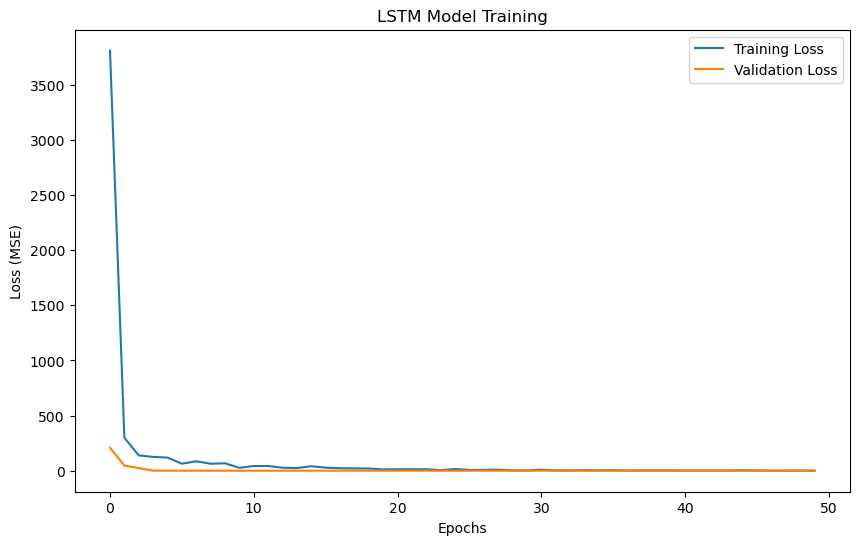

Evaluating and visualizing model performance...
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 439ms/step
Evaluation Metrics:

XGBoost Model Evaluation:
RMSE: 0.0311
MAE: 0.0161
R2: 0.9422

LSTM Model Evaluation:
RMSE: 0.1625
MAE: 0.1197
R2: -0.5820

Hybrid Model Evaluation:
RMSE: 0.0896
MAE: 0.0642
R2: 0.5194


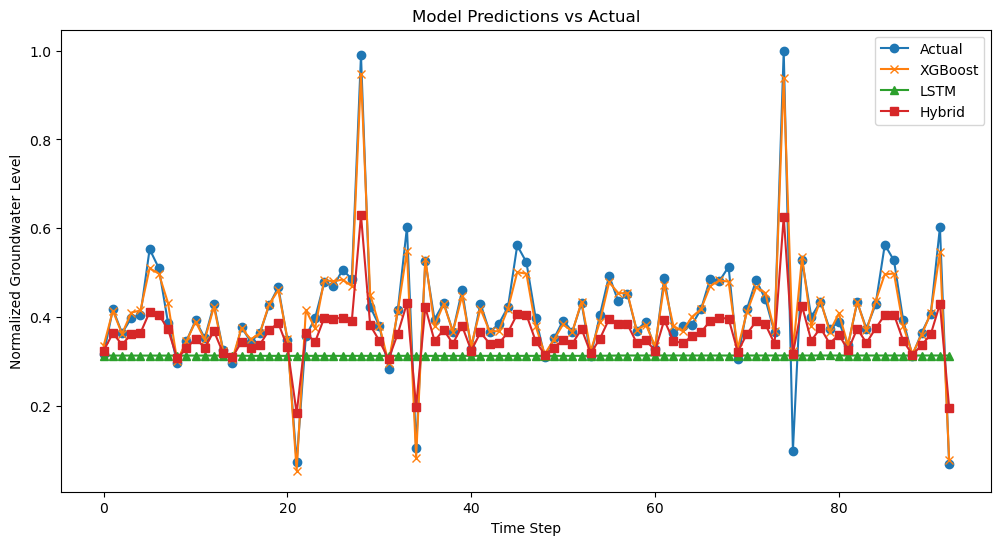

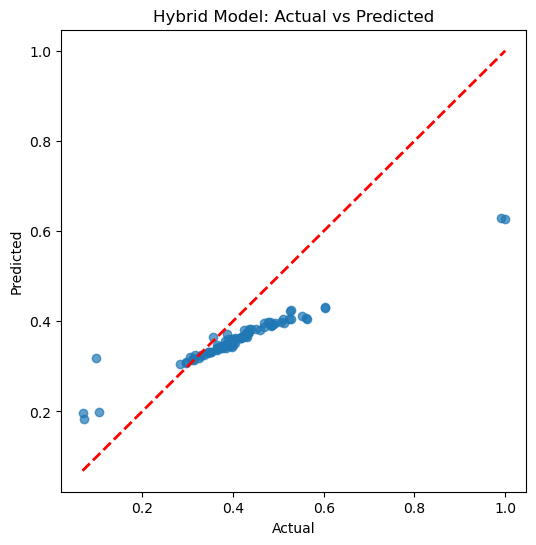

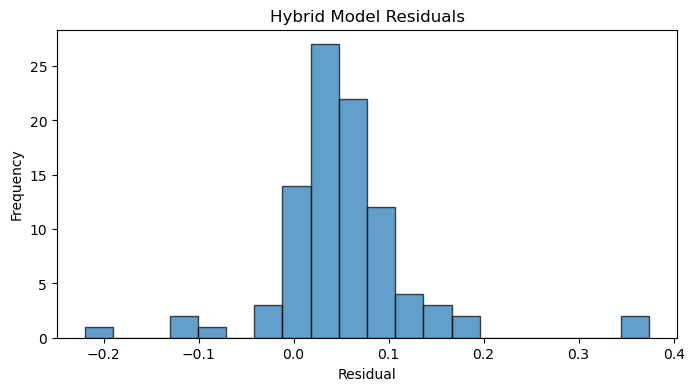

Training complete. Models are ready for prediction.


In [254]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout
import xgboost as xgb

# ======================
# 1. Data Loading & Preprocessing
# ======================
def load_and_preprocess_data(file_path):
    df = pd.read_csv(file_path, encoding="latin1")
    
    # Identify measurement columns (assuming they all contain "meters below ground level")
    measurement_cols = [col for col in df.columns if "meters below ground level" in col]
    
    # Define identifier columns
    id_vars = ['Sr. No.', 'State_Name_With_LGD_Code', 'District_Name_With_LGD_Code', 
               'Block_Name_With_LGD_Code', 'GP_Name_With_LGD_Code', 'Village', 
               'Site_Name', 'TYPE', 'SOURCE', 'Well_ID', 'Latitude', 'Longitude', 
               'Well_Depth (meters)', 'Aquifer']
    
    # Convert from wide to long format
    df_long = pd.melt(df, id_vars=id_vars, value_vars=measurement_cols,
                      var_name='Measurement', value_name='Groundwater_Level')
    
    # Extract Season and Year using regex
    df_long[['Season', 'Year']] = df_long['Measurement'].str.extract(r'(Pre-monsoon|Post-monsoon)_(\d{4})')
    df_long['Year'] = df_long['Year'].astype(int)
    
    # Convert groundwater levels to numeric (non-numeric values become NaN)
    df_long['Groundwater_Level'] = pd.to_numeric(df_long['Groundwater_Level'], errors='coerce')
    
    # Create a Month column: assume March for Pre-monsoon and September for Post-monsoon
    df_long['Month'] = df_long['Season'].apply(lambda s: 3 if s == "Pre-monsoon" else 9)
    df_long['Date'] = pd.to_datetime(dict(year=df_long['Year'], month=df_long['Month'], day=1))
    
    df_long.sort_values(by=['Site_Name', 'Date'], inplace=True)
    return df_long, measurement_cols

# ======================
# 2. Site Selection and Feature Engineering
# ======================
def prepare_site_data(df_long):
    # Select the site with the maximum number of measurements
    site_counts = df_long.groupby('Site_Name')['Groundwater_Level'].count()
    selected_site = site_counts.idxmax()
    print("Selected Site:", selected_site)
    
    df_site = df_long[df_long['Site_Name'] == selected_site].copy()
    df_site.sort_values(by='Date', inplace=True)
    df_site.reset_index(drop=True, inplace=True)
    
    # Interpolate missing values
    df_site['Groundwater_Level'] = df_site['Groundwater_Level'].interpolate()
    
    # Normalize using MinMaxScaler
    scaler = MinMaxScaler()
    df_site['Groundwater_Level_scaled'] = scaler.fit_transform(df_site[['Groundwater_Level']])
    
    # Create lag features and a rolling mean
    for lag in [1, 2, 3]:
        df_site[f'lag_{lag}'] = df_site['Groundwater_Level_scaled'].shift(lag)
    df_site['rolling_mean_2'] = df_site['Groundwater_Level_scaled'].rolling(window=2).mean()
    
    # Add time-based features
    df_site['Year_feat'] = df_site['Year']
    df_site['Month_feat'] = df_site['Month']
    
    # Drop rows with NaN values (from shifting/rolling)
    df_site_clean = df_site.dropna().copy()
    return df_site_clean, scaler

# ======================
# 3. Data Preparation for Both Models
# ======================
def prepare_model_data(df_site):
    features = ['lag_1', 'lag_2', 'lag_3', 'rolling_mean_2', 'Year_feat', 'Month_feat']
    target = 'Groundwater_Level_scaled'
    
    X = df_site[features].values
    y = df_site[target].values
    
    # Chronological train/validation/test split
    n = len(df_site)
    train_end = int(0.7 * n)
    val_end = int(0.85 * n)
    
    X_train, y_train = X[:train_end], y[:train_end]
    X_val, y_val = X[train_end:val_end], y[train_end:val_end]
    X_test, y_test = X[val_end:], y[val_end:]
    
    print(f"Training set: {X_train.shape}, Validation set: {X_val.shape}, Test set: {X_test.shape}")
    print("Features:", features)
    return X_train, y_train, X_val, y_val, X_test, y_test, features

# ======================
# 4. LSTM Data Preparation (Creating Sequences)
# ======================
def prepare_lstm_data(X_train, y_train, X_val, y_val, X_test, y_test):
    window_size = 3  # example window size
    
    def create_sequences(X, y, window_size):
        Xs, ys = [], []
        for i in range(len(X) - window_size):
            Xs.append(X[i:i+window_size])
            ys.append(y[i+window_size])
        return np.array(Xs), np.array(ys)
    
    X_train_seq, y_train_seq = create_sequences(X_train, y_train, window_size)
    X_val_seq, y_val_seq = create_sequences(X_val, y_val, window_size)
    X_test_seq, y_test_seq = create_sequences(X_test, y_test, window_size)
    
    print("LSTM input shapes:")
    print(f"Train: {X_train_seq.shape}, {y_train_seq.shape}")
    print(f"Validation: {X_val_seq.shape}, {y_val_seq.shape}")
    print(f"Test: {X_test_seq.shape}, {y_test_seq.shape}")
    return X_train_seq, y_train_seq, X_val_seq, y_val_seq, X_test_seq, y_test_seq, window_size

# ======================
# 5. XGBoost Model Training
# ======================
def train_xgboost_model(X_train, y_train, X_val, y_val):
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval = xgb.DMatrix(X_val, label=y_val)
    
    params = {
        'objective': 'reg:squarederror',
        'max_depth': 3,
        'learning_rate': 0.1,
        'random_state': 42
    }
    
    model_xgb = xgb.train(
        params=params,
        dtrain=dtrain,
        num_boost_round=100,
        evals=[(dval, 'validation')],
        early_stopping_rounds=10,
        verbose_eval=False
    )
    return model_xgb

# ======================
# 6. LSTM Model Training (Using the same engineered features)
# ======================
def train_lstm_model(X_train_seq, y_train_seq, X_val_seq, y_val_seq):
    timesteps, n_features = X_train_seq.shape[1], X_train_seq.shape[2]
    print(f"LSTM input shape: (timesteps={timesteps}, features={n_features})")
    
    model = Sequential([
        LSTM(50, activation='relu', input_shape=(timesteps, n_features), return_sequences=True),
        Dropout(0.2),
        LSTM(25, activation='relu'),
        Dropout(0.2),
        Dense(1)
    ])
    
    model.compile(optimizer='adam', loss='mse')
    print(model.summary())
    
    history = model.fit(
        X_train_seq,
        y_train_seq,
        epochs=50,
        batch_size=32,
        validation_data=(X_val_seq, y_val_seq),
        verbose=1
    )
    
    # Plot training history
    plt.figure(figsize=(10,6))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('LSTM Model Training')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.show()
    return model

# ======================
# 7. Model Evaluation and Visualization
# ======================
def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"\n{model_name} Model Evaluation:")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R2: {r2:.4f}")
    return rmse, mae, r2

def evaluate_and_visualize(xgb_model, lstm_model, X_test, X_test_seq, y_test, window_size):
    dtest = xgb.DMatrix(X_test)
    xgb_pred = xgb_model.predict(dtest)
    # Align predictions (drop first window_size entries)
    xgb_pred_aligned = xgb_pred[window_size:]
    y_test_aligned = y_test[window_size:]
    
    lstm_pred = lstm_model.predict(X_test_seq).flatten()
    # For a simple hybrid, here we average the predictions
    hybrid_pred = 0.5 * lstm_pred + 0.5 * xgb_pred_aligned
    
    print("Evaluation Metrics:")
    rmse_xgb, mae_xgb, r2_xgb = evaluate_model(y_test_aligned, xgb_pred_aligned, "XGBoost")
    rmse_lstm, mae_lstm, r2_lstm = evaluate_model(y_test_aligned, lstm_pred, "LSTM")
    rmse_hybrid, mae_hybrid, r2_hybrid = evaluate_model(y_test_aligned, hybrid_pred, "Hybrid")
    
    plt.figure(figsize=(12,6))
    plt.plot(y_test_aligned, label="Actual", marker='o')
    plt.plot(xgb_pred_aligned, label="XGBoost", marker='x')
    plt.plot(lstm_pred, label="LSTM", marker='^')
    plt.plot(hybrid_pred, label="Hybrid", marker='s')
    plt.title("Model Predictions vs Actual")
    plt.xlabel("Time Step")
    plt.ylabel("Normalized Groundwater Level")
    plt.legend()
    plt.show()
    
    plt.figure(figsize=(6,6))
    plt.scatter(y_test_aligned, hybrid_pred, alpha=0.7)
    plt.plot([min(y_test_aligned), max(y_test_aligned)], [min(y_test_aligned), max(y_test_aligned)], 'r--', lw=2)
    plt.title("Hybrid Model: Actual vs Predicted")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.show()
    
    residuals = y_test_aligned - hybrid_pred
    plt.figure(figsize=(8,4))
    plt.hist(residuals, bins=20, edgecolor='black', alpha=0.7)
    plt.title("Hybrid Model Residuals")
    plt.xlabel("Residual")
    plt.ylabel("Frequency")
    plt.show()
    
    return {
        "XGBoost": {"rmse": rmse_xgb, "mae": mae_xgb, "r2": r2_xgb},
        "LSTM": {"rmse": rmse_lstm, "mae": mae_lstm, "r2": r2_lstm},
        "Hybrid": {"rmse": rmse_hybrid, "mae": mae_hybrid, "r2": r2_hybrid}
    }

# ======================
# 8. Main Function
# ======================
def main(file_path):
    print("Loading and preprocessing data...")
    df_long, measurement_cols = load_and_preprocess_data(file_path)
    
    print("Preparing site data...")
    df_site, scaler = prepare_site_data(df_long)
    
    print("Preparing model data...")
    X_train, y_train, X_val, y_val, X_test, y_test, features = prepare_model_data(df_site)
    
    print("Preparing LSTM sequences...")
    X_train_seq, y_train_seq, X_val_seq, y_val_seq, X_test_seq, y_test_seq, window_size = prepare_lstm_data(X_train, y_train, X_val, y_val, X_test, y_test)
    
    print("Training XGBoost model...")
    xgb_model = train_xgboost_model(X_train, y_train, X_val, y_val)
    
    print("Training LSTM model...")
    lstm_model = train_lstm_model(X_train_seq, y_train_seq, X_val_seq, y_val_seq)
    
    print("Evaluating and visualizing model performance...")
    eval_metrics = evaluate_and_visualize(xgb_model, lstm_model, X_test, X_test_seq, y_test, window_size)
    
    model_info = {
        'xgb_model': xgb_model,
        'lstm_model': lstm_model,
        'scaler': scaler,
        'features': features,
        'window_size': window_size,
        'hybrid_metrics': eval_metrics
    }
    
    print("Training complete. Models are ready for prediction.")
    return model_info

if __name__ == "__main__":
    file_path = "./data.csv"  # Update with your file path
    model_info = main(file_path)


# lstm performed the worst so i decided to change it from lstm to GRU

Loading and preprocessing data...
Preparing site data...
Selected Site: In the Village
Preparing model data...
Training set: (445, 6), Validation set: (96, 6), Test set: (96, 6)
Features: ['lag_1', 'lag_2', 'lag_3', 'rolling_mean_2', 'Year_feat', 'Month_feat']
Preparing GRU sequences...
GRU input shapes:
Train: (442, 3, 6), (442,)
Validation: (93, 3, 6), (93,)
Test: (93, 3, 6), (93,)
Training XGBoost model...
Training GRU model...
GRU input shape: (timesteps=3, features=6)


C:\D Drive\Anaconda\Lib\site-packages\keras\src\layers\rnn\rnn.py:200: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ gru (GRU)                            │ (None, 3, 50)               │           8,700 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_20 (Dropout)                 │ (None, 3, 50)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ gru_1 (GRU)                          │ (None, 25)                  │           5,775 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_21 (Dropout)                 │ (None, 25)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_13 (Dense)                     │ (None, 1)                   │              26 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 14,501 (56.64 KB)

 Trainable params: 14,501 (56.64 KB)

 Non-trainable params: 0 (0.00 B)

None
Epoch 1/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 13s 130ms/step - loss: 10422.7793 - val_loss: 307.4010
Epoch 2/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 1780.0172 - val_loss: 1.9204
Epoch 3/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 1183.4658 - val_loss: 0.9035
Epoch 4/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 735.0027 - val_loss: 0.5715
Epoch 5/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step - loss: 555.1046 - val_loss: 4.7316
Epoch 6/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 489.3172 - val_loss: 9.4535
Epoch 7/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 429.7579 - val_loss: 18.9655
Epoch 8/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 316.3316 - val_loss: 0.7999
Epoch 9/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 272.1307 - val_loss: 0.1079
Epoch 10/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 210.8584 - val_loss: 0.6425
Epoch 11/50
14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 182.4308 - val_loss: 0.8703
Epoch 12/50
14/14 ━━━━━━━━━

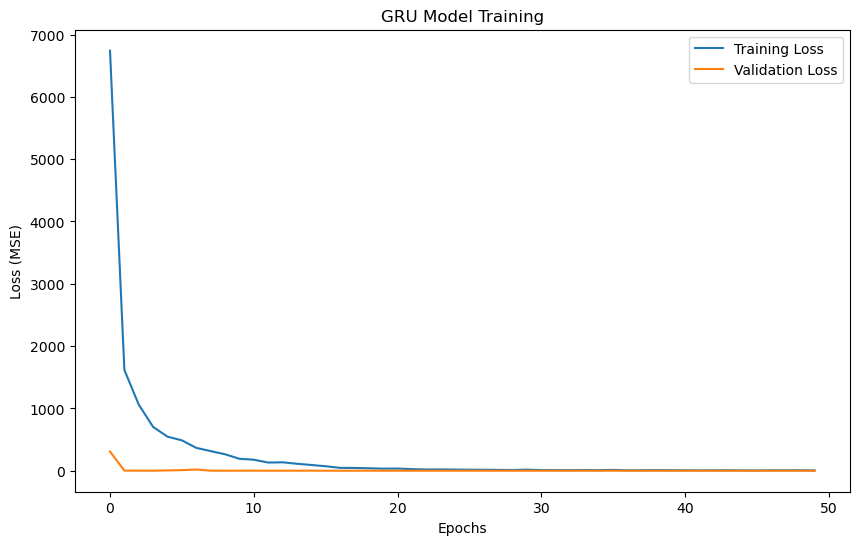

Evaluating and visualizing model performance...
3/3 ━━━━━━━━━━━━━━━━━━━━ 2s 508ms/step
Evaluation Metrics:

XGBoost Model Evaluation:
RMSE: 0.0311
MAE: 0.0161
R2: 0.9422

GRU Model Evaluation:
RMSE: 0.1792
MAE: 0.1482
R2: -0.9239

Hybrid Model Evaluation:
RMSE: 0.0958
MAE: 0.0776
R2: 0.4499


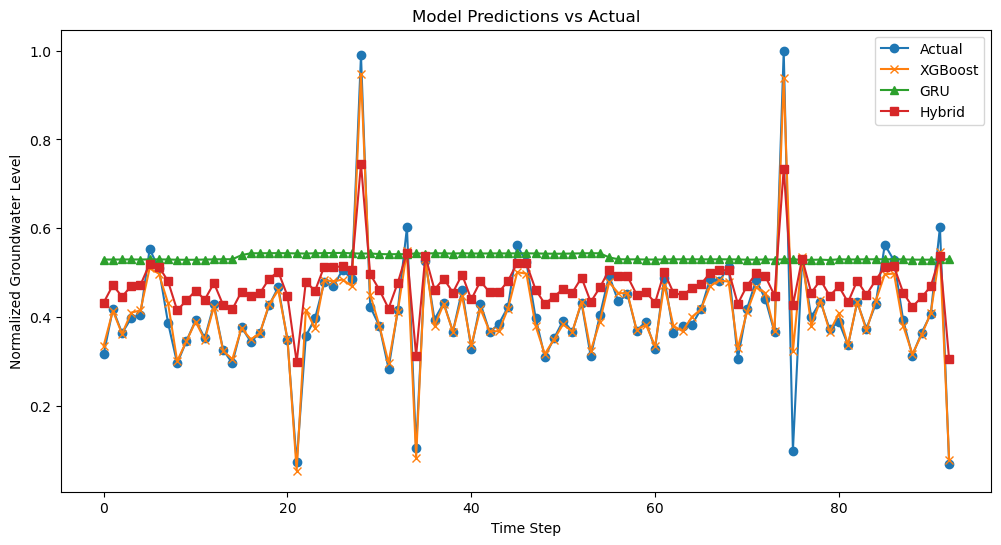

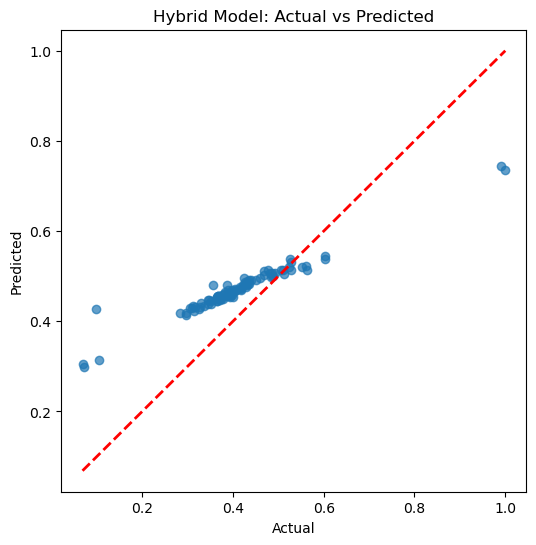

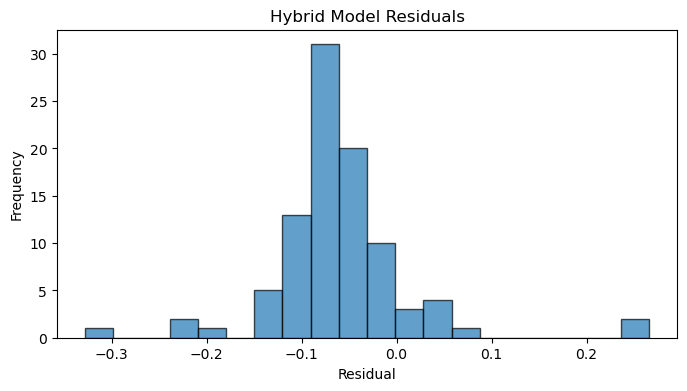

Training complete. Models are ready for prediction.


In [257]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import GRU, Dense, Dropout
import xgboost as xgb

# ======================
# 1. Data Loading & Preprocessing
# ======================
def load_and_preprocess_data(file_path):
    df = pd.read_csv(file_path, encoding="latin1")
    
    # Identify measurement columns (assume they all include "meters below ground level")
    measurement_cols = [col for col in df.columns if "meters below ground level" in col]
    
    # Define identifier columns
    id_vars = ['Sr. No.', 'State_Name_With_LGD_Code', 'District_Name_With_LGD_Code', 
               'Block_Name_With_LGD_Code', 'GP_Name_With_LGD_Code', 'Village', 
               'Site_Name', 'TYPE', 'SOURCE', 'Well_ID', 'Latitude', 'Longitude', 
               'Well_Depth (meters)', 'Aquifer']
    
    # Pivot the data from wide to long format
    df_long = pd.melt(df, id_vars=id_vars, value_vars=measurement_cols,
                      var_name='Measurement', value_name='Groundwater_Level')
    
    # Extract Season and Year from the Measurement column
    df_long[['Season', 'Year']] = df_long['Measurement'].str.extract(r'(Pre-monsoon|Post-monsoon)_(\d{4})')
    df_long['Year'] = df_long['Year'].astype(int)
    
    # Convert groundwater levels to numeric (non-numeric become NaN)
    df_long['Groundwater_Level'] = pd.to_numeric(df_long['Groundwater_Level'], errors='coerce')
    
    # Create a Month column: March for Pre-monsoon, September for Post-monsoon
    df_long['Month'] = df_long['Season'].apply(lambda s: 3 if s == "Pre-monsoon" else 9)
    df_long['Date'] = pd.to_datetime(dict(year=df_long['Year'], month=df_long['Month'], day=1))
    
    df_long.sort_values(by=['Site_Name', 'Date'], inplace=True)
    return df_long, measurement_cols

# ======================
# 2. Site Selection and Feature Engineering
# ======================
def prepare_site_data(df_long):
    # Select the site with the maximum number of measurements
    site_counts = df_long.groupby('Site_Name')['Groundwater_Level'].count()
    selected_site = site_counts.idxmax()
    print("Selected Site:", selected_site)
    
    df_site = df_long[df_long['Site_Name'] == selected_site].copy()
    df_site.sort_values(by='Date', inplace=True)
    df_site.reset_index(drop=True, inplace=True)
    
    # Interpolate missing groundwater level values
    df_site['Groundwater_Level'] = df_site['Groundwater_Level'].interpolate()
    
    # Normalize using MinMaxScaler
    scaler = MinMaxScaler()
    df_site['Groundwater_Level_scaled'] = scaler.fit_transform(df_site[['Groundwater_Level']])
    
    # Create lag features and rolling mean
    for lag in [1, 2, 3]:
        df_site[f'lag_{lag}'] = df_site['Groundwater_Level_scaled'].shift(lag)
    df_site['rolling_mean_2'] = df_site['Groundwater_Level_scaled'].rolling(window=2).mean()
    
    # Add time-based features
    df_site['Year_feat'] = df_site['Year']
    df_site['Month_feat'] = df_site['Month']
    
    # Drop rows with NaNs resulting from shifting/rolling
    df_site_clean = df_site.dropna().copy()
    return df_site_clean, scaler

# ======================
# 3. Data Preparation for Both Models
# ======================
def prepare_model_data(df_site):
    features = ['lag_1', 'lag_2', 'lag_3', 'rolling_mean_2', 'Year_feat', 'Month_feat']
    target = 'Groundwater_Level_scaled'
    
    X = df_site[features].values
    y = df_site[target].values
    
    # Chronological train/validation/test split
    n = len(df_site)
    train_end = int(0.7 * n)
    val_end = int(0.85 * n)
    
    X_train, y_train = X[:train_end], y[:train_end]
    X_val, y_val = X[train_end:val_end], y[train_end:val_end]
    X_test, y_test = X[val_end:], y[val_end:]
    
    print(f"Training set: {X_train.shape}, Validation set: {X_val.shape}, Test set: {X_test.shape}")
    print("Features:", features)
    return X_train, y_train, X_val, y_val, X_test, y_test, features

# ======================
# 4. GRU Data Preparation (Creating Sequences)
# ======================
def prepare_sequence_data(X_train, y_train, X_val, y_val, X_test, y_test):
    window_size = 3  # sliding window size
    
    def create_sequences(X, y, window_size):
        Xs, ys = [], []
        for i in range(len(X) - window_size):
            Xs.append(X[i:i+window_size])
            ys.append(y[i+window_size])
        return np.array(Xs), np.array(ys)
    
    X_train_seq, y_train_seq = create_sequences(X_train, y_train, window_size)
    X_val_seq, y_val_seq = create_sequences(X_val, y_val, window_size)
    X_test_seq, y_test_seq = create_sequences(X_test, y_test, window_size)
    
    print("GRU input shapes:")
    print(f"Train: {X_train_seq.shape}, {y_train_seq.shape}")
    print(f"Validation: {X_val_seq.shape}, {y_val_seq.shape}")
    print(f"Test: {X_test_seq.shape}, {y_test_seq.shape}")
    
    return X_train_seq, y_train_seq, X_val_seq, y_val_seq, X_test_seq, y_test_seq, window_size

# ======================
# 5. XGBoost Model Training
# ======================
def train_xgboost_model(X_train, y_train, X_val, y_val):
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval = xgb.DMatrix(X_val, label=y_val)
    
    params = {
        'objective': 'reg:squarederror',
        'max_depth': 3,
        'learning_rate': 0.1,
        'random_state': 42
    }
    
    model_xgb = xgb.train(
        params=params,
        dtrain=dtrain,
        num_boost_round=100,
        evals=[(dval, 'validation')],
        early_stopping_rounds=10,
        verbose_eval=False
    )
    return model_xgb

# ======================
# 6. GRU Model Training (Replacement for LSTM)
# ======================
from tensorflow.keras.layers import GRU

def train_gru_model(X_train_seq, y_train_seq, X_val_seq, y_val_seq):
    timesteps, n_features = X_train_seq.shape[1], X_train_seq.shape[2]
    print(f"GRU input shape: (timesteps={timesteps}, features={n_features})")
    
    model = Sequential([
        GRU(50, activation='relu', input_shape=(timesteps, n_features), return_sequences=True),
        Dropout(0.2),
        GRU(25, activation='relu'),
        Dropout(0.2),
        Dense(1)
    ])
    
    model.compile(optimizer='adam', loss='mse')
    print(model.summary())
    
    history = model.fit(
        X_train_seq, 
        y_train_seq, 
        epochs=50, 
        batch_size=32, 
        validation_data=(X_val_seq, y_val_seq),
        verbose=1
    )
    
    # Plot training history
    plt.figure(figsize=(10,6))
    plt.plot(history.history['loss'], label='Training Loss')
    plt.plot(history.history['val_loss'], label='Validation Loss')
    plt.title('GRU Model Training')
    plt.xlabel('Epochs')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.show()
    return model

# ======================
# 7. Model Evaluation and Visualization
# ======================
def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"\n{model_name} Model Evaluation:")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R2: {r2:.4f}")
    return rmse, mae, r2

def evaluate_and_visualize(xgb_model, gru_model, X_test, X_test_seq, y_test, window_size):
    dtest = xgb.DMatrix(X_test)
    xgb_pred = xgb_model.predict(dtest)
    # Align XGBoost predictions by dropping first window_size samples
    xgb_pred_aligned = xgb_pred[window_size:]
    y_test_aligned = y_test[window_size:]
    
    gru_pred = gru_model.predict(X_test_seq).flatten()
    # For a simple hybrid integration, we average the predictions
    hybrid_pred = 0.5 * gru_pred + 0.5 * xgb_pred_aligned
    
    print("Evaluation Metrics:")
    rmse_xgb, mae_xgb, r2_xgb = evaluate_model(y_test_aligned, xgb_pred_aligned, "XGBoost")
    rmse_gru, mae_gru, r2_gru = evaluate_model(y_test_aligned, gru_pred, "GRU")
    rmse_hybrid, mae_hybrid, r2_hybrid = evaluate_model(y_test_aligned, hybrid_pred, "Hybrid")
    
    plt.figure(figsize=(12,6))
    plt.plot(y_test_aligned, label="Actual", marker='o')
    plt.plot(xgb_pred_aligned, label="XGBoost", marker='x')
    plt.plot(gru_pred, label="GRU", marker='^')
    plt.plot(hybrid_pred, label="Hybrid", marker='s')
    plt.title("Model Predictions vs Actual")
    plt.xlabel("Time Step")
    plt.ylabel("Normalized Groundwater Level")
    plt.legend()
    plt.show()
    
    plt.figure(figsize=(6,6))
    plt.scatter(y_test_aligned, hybrid_pred, alpha=0.7)
    plt.plot([min(y_test_aligned), max(y_test_aligned)], [min(y_test_aligned), max(y_test_aligned)], 'r--', lw=2)
    plt.title("Hybrid Model: Actual vs Predicted")
    plt.xlabel("Actual")
    plt.ylabel("Predicted")
    plt.show()
    
    residuals = y_test_aligned - hybrid_pred
    plt.figure(figsize=(8,4))
    plt.hist(residuals, bins=20, edgecolor='black', alpha=0.7)
    plt.title("Hybrid Model Residuals")
    plt.xlabel("Residual")
    plt.ylabel("Frequency")
    plt.show()
    
    return {
        "XGBoost": {"rmse": rmse_xgb, "mae": mae_xgb, "r2": r2_xgb},
        "GRU": {"rmse": rmse_gru, "mae": mae_gru, "r2": r2_gru},
        "Hybrid": {"rmse": rmse_hybrid, "mae": mae_hybrid, "r2": r2_hybrid}
    }

# ======================
# 8. Main Function
# ======================
def main(file_path):
    print("Loading and preprocessing data...")
    df_long, measurement_cols = load_and_preprocess_data(file_path)
    
    print("Preparing site data...")
    df_site, scaler = prepare_site_data(df_long)
    
    print("Preparing model data...")
    X_train, y_train, X_val, y_val, X_test, y_test, features = prepare_model_data(df_site)
    
    print("Preparing GRU sequences...")
    X_train_seq, y_train_seq, X_val_seq, y_val_seq, X_test_seq, y_test_seq, window_size = prepare_sequence_data(X_train, y_train, X_val, y_val, X_test, y_test)
    
    print("Training XGBoost model...")
    xgb_model = train_xgboost_model(X_train, y_train, X_val, y_val)
    
    print("Training GRU model...")
    gru_model = train_gru_model(X_train_seq, y_train_seq, X_val_seq, y_val_seq)
    
    print("Evaluating and visualizing model performance...")
    eval_metrics = evaluate_and_visualize(xgb_model, gru_model, X_test, X_test_seq, y_test, window_size)
    
    model_info = {
        'xgb_model': xgb_model,
        'gru_model': gru_model,
        'scaler': scaler,
        'features': features,
        'window_size': window_size,
        'hybrid_metrics': eval_metrics
    }
    
    print("Training complete. Models are ready for prediction.")
    return model_info

if __name__ == "__main__":
    file_path = "./data.csv"  # Update with your file path
    model_info = main(file_path)


# GRU also gave negative r2 score. so trying with svr

Loading and preprocessing data...
Preparing site data and engineering features...
Selected Site: In the Village
Preparing model data...
Training: (445, 6), Validation: (96, 6), Test: (96, 6)
Features used: ['lag_1', 'lag_2', 'lag_3', 'rolling_mean_2', 'Year_feat', 'Month_feat']
Training XGBoost model...
Training SVR model...
Evaluating models and hybrid integration on test set...
Evaluating Individual Models:

XGBoost Evaluation:
RMSE: 0.0306
MAE: 0.0159
R2: 0.9423

SVR Evaluation:
RMSE: 0.1386
MAE: 0.1151
R2: -0.1813

Evaluating Hybrid Model:

Hybrid Evaluation:
RMSE: 0.0525
MAE: 0.0391
R2: 0.8306


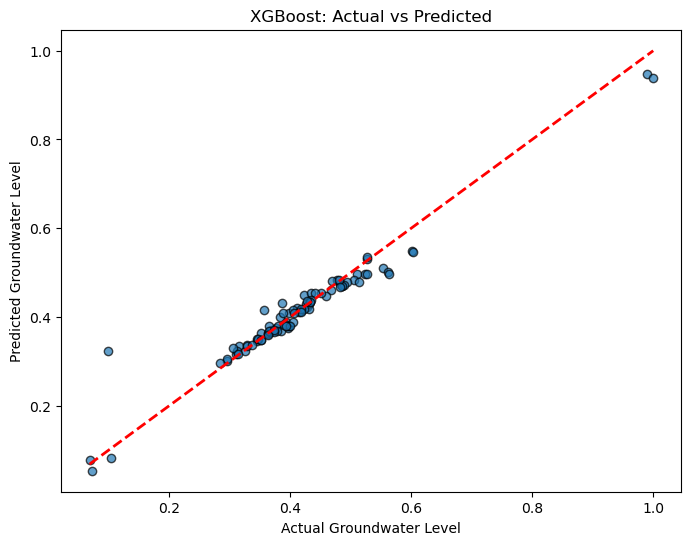

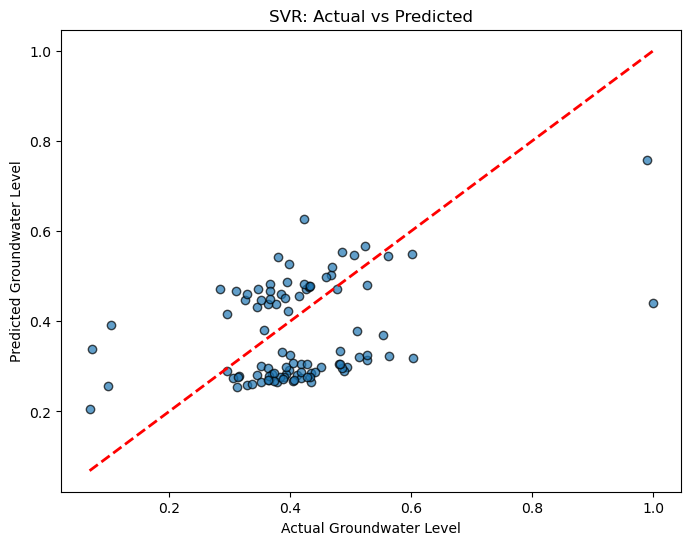

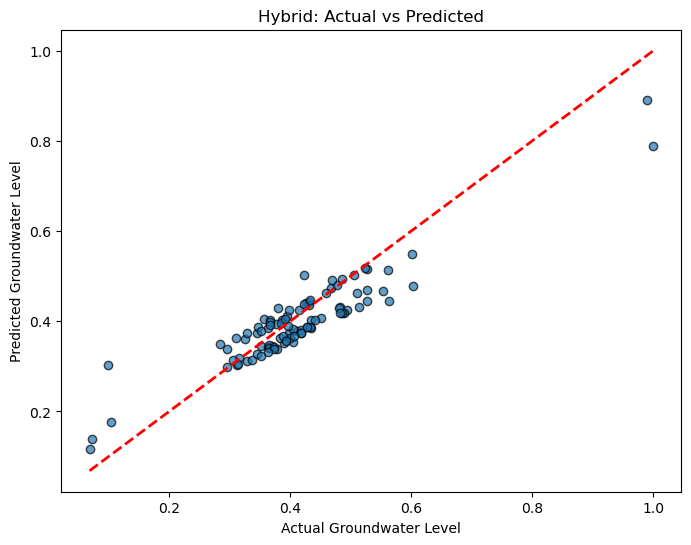

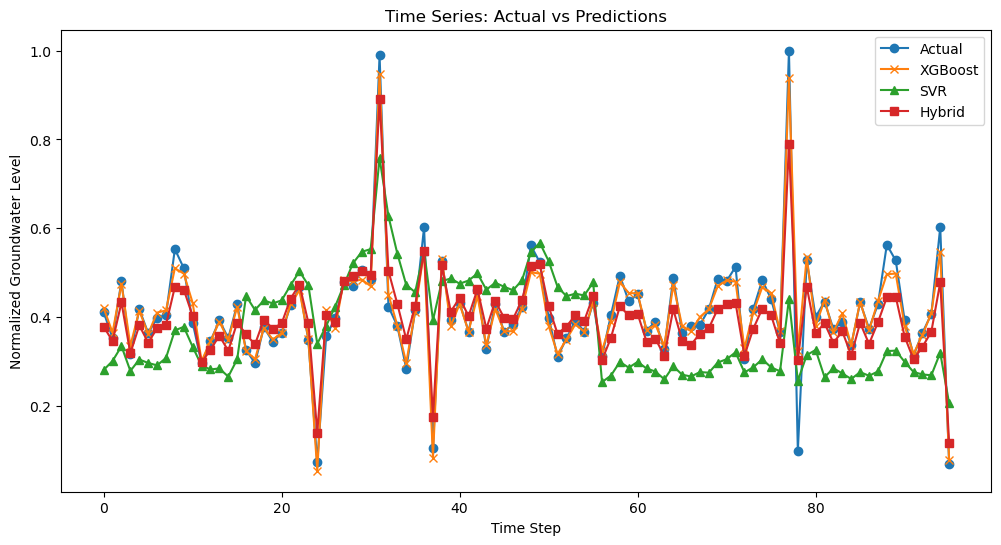

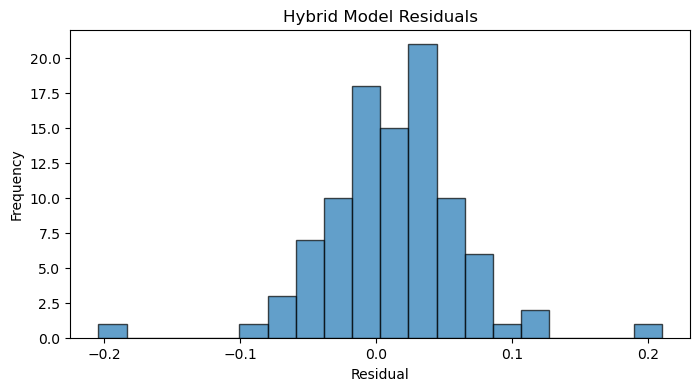

Training complete. Models and evaluations are ready for prediction.


In [269]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
from sklearn.svm import SVR

# ======================
# 1. Data Loading & Preprocessing
# ======================
def load_and_preprocess_data(file_path):
    df = pd.read_csv(file_path, encoding="latin1")
    
    # Identify measurement columns (those containing "meters below ground level")
    measurement_cols = [col for col in df.columns if "meters below ground level" in col]
    
    # Define identifier columns
    id_vars = ['Sr. No.', 'State_Name_With_LGD_Code', 'District_Name_With_LGD_Code', 
               'Block_Name_With_LGD_Code', 'GP_Name_With_LGD_Code', 'Village', 
               'Site_Name', 'TYPE', 'SOURCE', 'Well_ID', 'Latitude', 'Longitude', 
               'Well_Depth (meters)', 'Aquifer']
    
    # Pivot from wide to long format
    df_long = pd.melt(df, id_vars=id_vars, value_vars=measurement_cols, 
                      var_name='Measurement', value_name='Groundwater_Level')
    
    # Extract Season and Year from Measurement column
    df_long[['Season', 'Year']] = df_long['Measurement'].str.extract(r'(Pre-monsoon|Post-monsoon)_(\d{4})')
    df_long['Year'] = df_long['Year'].astype(int)
    
    # Convert groundwater levels to numeric; non-numeric become NaN
    df_long['Groundwater_Level'] = pd.to_numeric(df_long['Groundwater_Level'], errors='coerce')
    
    # Create Month column: March for Pre-monsoon, September for Post-monsoon
    df_long['Month'] = df_long['Season'].apply(lambda s: 3 if s=="Pre-monsoon" else 9)
    df_long['Date'] = pd.to_datetime(dict(year=df_long['Year'], month=df_long['Month'], day=1))
    
    df_long.sort_values(by=['Site_Name', 'Date'], inplace=True)
    return df_long, measurement_cols

# ======================
# 2. Site Selection & Feature Engineering
# ======================
def prepare_site_data(df_long):
    # Choose site with the maximum number of measurements
    site_counts = df_long.groupby('Site_Name')['Groundwater_Level'].count()
    selected_site = site_counts.idxmax()
    print("Selected Site:", selected_site)
    
    df_site = df_long[df_long['Site_Name'] == selected_site].copy()
    df_site.sort_values(by='Date', inplace=True)
    df_site.reset_index(drop=True, inplace=True)
    
    # Interpolate missing values
    df_site['Groundwater_Level'] = df_site['Groundwater_Level'].interpolate()
    
    # Normalize groundwater levels
    scaler = MinMaxScaler()
    df_site['Groundwater_Level_scaled'] = scaler.fit_transform(df_site[['Groundwater_Level']])
    
    # Create lag features and rolling mean
    for lag in [1, 2, 3]:
        df_site[f'lag_{lag}'] = df_site['Groundwater_Level_scaled'].shift(lag)
    df_site['rolling_mean_2'] = df_site['Groundwater_Level_scaled'].rolling(window=2).mean()
    
    # Add time-based features (Year and Month)
    df_site['Year_feat'] = df_site['Year']
    df_site['Month_feat'] = df_site['Month']
    
    # Drop rows with NaN values
    df_site_clean = df_site.dropna().copy()
    return df_site_clean, scaler

# ======================
# 3. Data Preparation for Modeling
# ======================
def prepare_model_data(df_site):
    features = ['lag_1', 'lag_2', 'lag_3', 'rolling_mean_2', 'Year_feat', 'Month_feat']
    target = 'Groundwater_Level_scaled'
    
    X = df_site[features].values
    y = df_site[target].values
    
    # Chronologically split: 70% train, 15% validation, 15% test
    n = len(df_site)
    train_end = int(0.7 * n)
    val_end = int(0.85 * n)
    
    X_train, y_train = X[:train_end], y[:train_end]
    X_val, y_val = X[train_end:val_end], y[train_end:val_end]
    X_test, y_test = X[val_end:], y[val_end:]
    
    print(f"Training: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")
    print("Features used:", features)
    return X_train, y_train, X_val, y_val, X_test, y_test, features

# ======================
# 4. Train XGBoost Model
# ======================
def train_xgboost_model(X_train, y_train, X_val, y_val):
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval = xgb.DMatrix(X_val, label=y_val)
    
    params = {
        'objective': 'reg:squarederror',
        'max_depth': 3,
        'learning_rate': 0.1,
        'random_state': 42
    }
    
    model_xgb = xgb.train(params, dtrain, num_boost_round=100, 
                          evals=[(dval, 'val')],
                          early_stopping_rounds=10, verbose_eval=False)
    return model_xgb

# ======================
# 5. Train SVR Model
# ======================
def train_svr_model(X_train, y_train):
    # Using RBF kernel; these hyperparameters can be tuned via cross-validation
    svr_model = SVR(kernel='rbf', C=100, gamma=0.1, epsilon=0.1)
    svr_model.fit(X_train, y_train)
    return svr_model

# ======================
# 6. Evaluation Functions
# ======================
def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"\n{model_name} Evaluation:")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R2: {r2:.4f}")
    return rmse, mae, r2

def plot_predictions(y_true, y_pred, title):
    plt.figure(figsize=(8,6))
    plt.scatter(y_true, y_pred, alpha=0.7, edgecolors='k')
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    plt.xlabel("Actual Groundwater Level")
    plt.ylabel("Predicted Groundwater Level")
    plt.title(title)
    plt.show()

def plot_time_series(y_true, xgb_pred, svr_pred, hybrid_pred):
    plt.figure(figsize=(12,6))
    plt.plot(y_true, label="Actual", marker='o')
    plt.plot(xgb_pred, label="XGBoost", marker='x')
    plt.plot(svr_pred, label="SVR", marker='^')
    plt.plot(hybrid_pred, label="Hybrid", marker='s')
    plt.xlabel("Time Step")
    plt.ylabel("Normalized Groundwater Level")
    plt.title("Time Series: Actual vs Predictions")
    plt.legend()
    plt.show()

def plot_residuals(y_true, pred, title):
    residuals = y_true - pred
    plt.figure(figsize=(8,4))
    plt.hist(residuals, bins=20, edgecolor='black', alpha=0.7)
    plt.xlabel("Residual")
    plt.ylabel("Frequency")
    plt.title(title)
    plt.show()

# ======================
# 7. Hybrid Integration & Evaluation
# ======================
def evaluate_hybrid(xgb_model, svr_model, X_test, y_test):
    # XGBoost predictions on test set
    dtest = xgb.DMatrix(X_test)
    xgb_pred = xgb_model.predict(dtest)
    
    # SVR predictions on test set
    svr_pred = svr_model.predict(X_test)
    
    # For hybrid, we combine predictions using a weighted average.
    # For example, 70% weight to XGBoost and 30% to SVR.
    weight_xgb = 0.7
    hybrid_pred = weight_xgb * xgb_pred + (1 - weight_xgb) * svr_pred
    
    # Evaluate each model individually and the hybrid
    print("Evaluating Individual Models:")
    rmse_xgb, mae_xgb, r2_xgb = evaluate_model(y_test, xgb_pred, "XGBoost")
    rmse_svr, mae_svr, r2_svr = evaluate_model(y_test, svr_pred, "SVR")
    print("\nEvaluating Hybrid Model:")
    rmse_h, mae_h, r2_h = evaluate_model(y_test, hybrid_pred, "Hybrid")
    
    # Plot predictions and residuals
    plot_predictions(y_test, xgb_pred, "XGBoost: Actual vs Predicted")
    plot_predictions(y_test, svr_pred, "SVR: Actual vs Predicted")
    plot_predictions(y_test, hybrid_pred, "Hybrid: Actual vs Predicted")
    plot_time_series(y_test, xgb_pred, svr_pred, hybrid_pred)
    plot_residuals(y_test, hybrid_pred, "Hybrid Model Residuals")
    
    return {
        "XGBoost": {"rmse": rmse_xgb, "mae": mae_xgb, "r2": r2_xgb},
        "SVR": {"rmse": rmse_svr, "mae": mae_svr, "r2": r2_svr},
        "Hybrid": {"rmse": rmse_h, "mae": mae_h, "r2": r2_h}
    }

# ======================
# 8. Main Function
# ======================
def main(file_path):
    print("Loading and preprocessing data...")
    df_long, measurement_cols = load_and_preprocess_data(file_path)
    
    print("Preparing site data and engineering features...")
    df_site, scaler = prepare_site_data(df_long)
    
    print("Preparing model data...")
    X_train, y_train, X_val, y_val, X_test, y_test, features = prepare_model_data(df_site)
    
    print("Training XGBoost model...")
    model_xgb = train_xgboost_model(X_train, y_train, X_val, y_val)
    
    print("Training SVR model...")
    model_svr = train_svr_model(X_train, y_train)
    
    print("Evaluating models and hybrid integration on test set...")
    eval_metrics = evaluate_hybrid(model_xgb, model_svr, X_test, y_test)
    
    print("Training complete. Models and evaluations are ready for prediction.")
    return {
        'xgb_model': model_xgb,
        'svr_model': model_svr,
        'scaler': scaler,
        'features': features,
        'evaluation': eval_metrics
    }

if __name__ == "__main__":
    file_path = "./data.csv"  # Update with your dataset file path
    model_info = main(file_path)


# dt regressor

Loading and preprocessing data...
Preparing site data and engineering features...
Selected Site: In the Village
Preparing model data...
Training: (445, 6), Validation: (96, 6), Test: (96, 6)
Features used: ['lag_1', 'lag_2', 'lag_3', 'rolling_mean_2', 'Year_feat', 'Month_feat']
Training XGBoost model...
Training Decision Tree Regressor...
Evaluating models and hybrid integration on test set...
Evaluating Individual Models:

XGBoost Evaluation:
RMSE: 0.0306
MAE: 0.0159
R2: 0.9423

Decision Tree Evaluation:
RMSE: 0.0313
MAE: 0.0205
R2: 0.9399

Evaluating Hybrid Model:

Hybrid Evaluation:
RMSE: 0.0290
MAE: 0.0151
R2: 0.9482


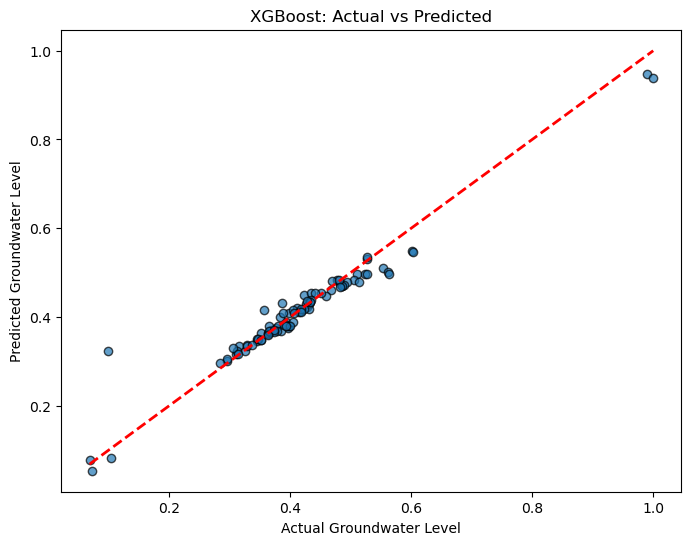

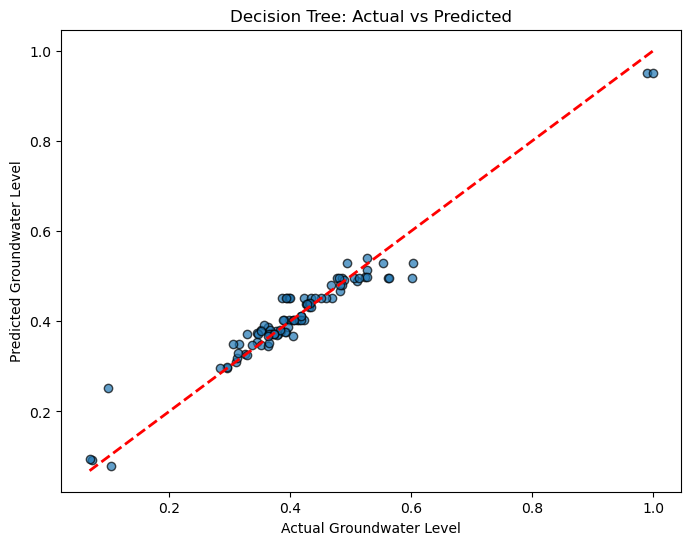

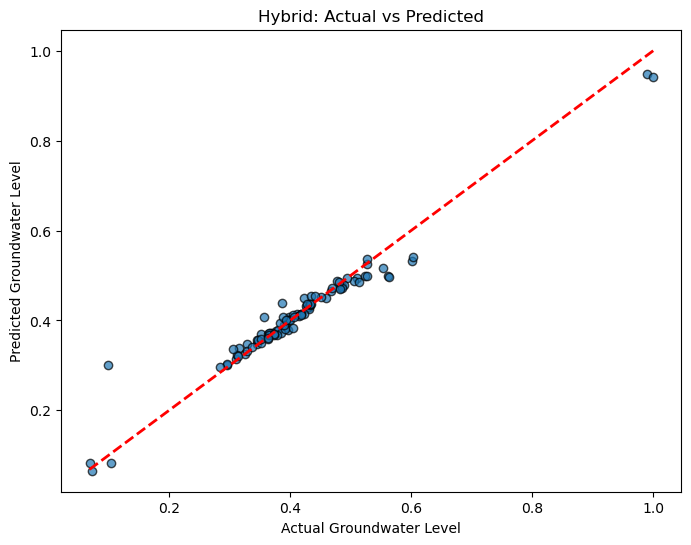

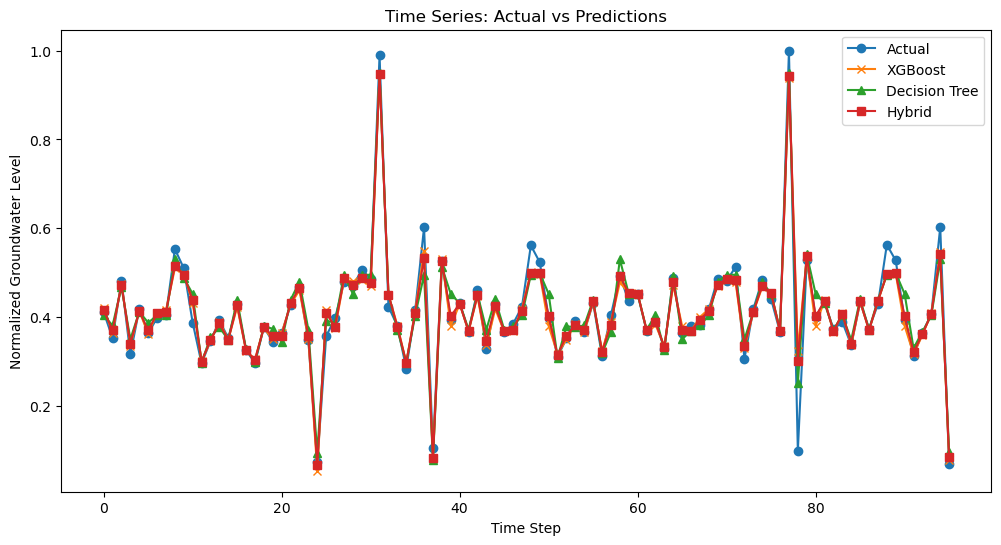

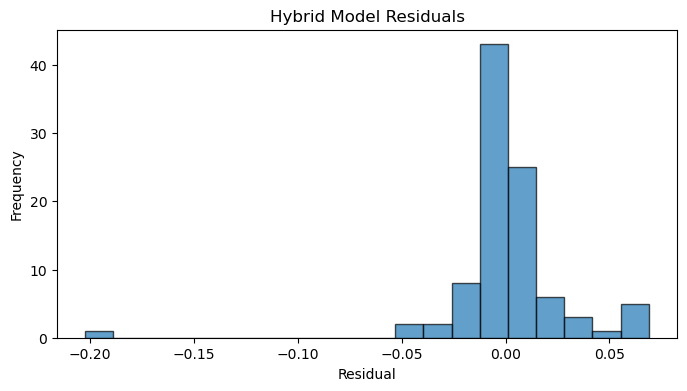

Training complete. Models and evaluations are ready for prediction.


In [290]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
from sklearn.tree import DecisionTreeRegressor

# ======================
# 1. Data Loading & Preprocessing
# ======================
def load_and_preprocess_data(file_path):
    df = pd.read_csv(file_path, encoding="latin1")
    
    # Identify measurement columns (those that include "meters below ground level")
    measurement_cols = [col for col in df.columns if "meters below ground level" in col]
    
    # Define identifier columns (these columns remain unchanged)
    id_vars = ['Sr. No.', 'State_Name_With_LGD_Code', 'District_Name_With_LGD_Code', 
               'Block_Name_With_LGD_Code', 'GP_Name_With_LGD_Code', 'Village', 
               'Site_Name', 'TYPE', 'SOURCE', 'Well_ID', 'Latitude', 'Longitude', 
               'Well_Depth (meters)', 'Aquifer']
    
    # Pivot from wide to long format
    df_long = pd.melt(df, id_vars=id_vars, value_vars=measurement_cols, 
                      var_name='Measurement', value_name='Groundwater_Level')
    
    # Extract Season and Year from the Measurement column using regex
    df_long[['Season', 'Year']] = df_long['Measurement'].str.extract(r'(Pre-monsoon|Post-monsoon)_(\d{4})')
    df_long['Year'] = df_long['Year'].astype(int)
    
    # Convert groundwater levels to numeric; non-numeric become NaN
    df_long['Groundwater_Level'] = pd.to_numeric(df_long['Groundwater_Level'], errors='coerce')
    
    # Create Month column: assume March for Pre-monsoon, September for Post-monsoon
    df_long['Month'] = df_long['Season'].apply(lambda s: 3 if s=="Pre-monsoon" else 9)
    df_long['Date'] = pd.to_datetime(dict(year=df_long['Year'], month=df_long['Month'], day=1))
    
    # Sort by site and date
    df_long.sort_values(by=['Site_Name', 'Date'], inplace=True)
    return df_long, measurement_cols

# ======================
# 2. Site Selection & Feature Engineering
# ======================
def prepare_site_data(df_long):
    # Select the site with the maximum number of measurements
    site_counts = df_long.groupby('Site_Name')['Groundwater_Level'].count()
    selected_site = site_counts.idxmax()
    print("Selected Site:", selected_site)
    
    df_site = df_long[df_long['Site_Name'] == selected_site].copy()
    df_site.sort_values(by='Date', inplace=True)
    df_site.reset_index(drop=True, inplace=True)
    
    # Interpolate missing groundwater values
    df_site['Groundwater_Level'] = df_site['Groundwater_Level'].interpolate()
    
    # Normalize groundwater levels using MinMaxScaler
    scaler = MinMaxScaler()
    df_site['Groundwater_Level_scaled'] = scaler.fit_transform(df_site[['Groundwater_Level']])
    
    # Create lag features (lags 1, 2, 3) and a rolling mean (window=2)
    for lag in [1, 2, 3]:
        df_site[f'lag_{lag}'] = df_site['Groundwater_Level_scaled'].shift(lag)
    df_site['rolling_mean_2'] = df_site['Groundwater_Level_scaled'].rolling(window=2).mean()
    
    # Add time-based features (Year and Month)
    df_site['Year_feat'] = df_site['Year']
    df_site['Month_feat'] = df_site['Month']
    
    # Drop rows with NaN values (due to shifting/rolling)
    df_site_clean = df_site.dropna().copy()
    return df_site_clean, scaler

# ======================
# 3. Data Preparation for Modeling
# ======================
def prepare_model_data(df_site):
    features = ['lag_1', 'lag_2', 'lag_3', 'rolling_mean_2', 'Year_feat', 'Month_feat']
    target = 'Groundwater_Level_scaled'
    
    X = df_site[features].values
    y = df_site[target].values
    
    # Chronologically split data: 70% train, 15% validation, 15% test
    n = len(df_site)
    train_end = int(0.7 * n)
    val_end = int(0.85 * n)
    
    X_train, y_train = X[:train_end], y[:train_end]
    X_val, y_val = X[train_end:val_end], y[train_end:val_end]
    X_test, y_test = X[val_end:], y[val_end:]
    
    print(f"Training: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")
    print("Features used:", features)
    return X_train, y_train, X_val, y_val, X_test, y_test, features

# ======================
# 4. Train XGBoost Model
# ======================
def train_xgboost_model(X_train, y_train, X_val, y_val):
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval = xgb.DMatrix(X_val, label=y_val)
    
    params = {
        'objective': 'reg:squarederror',
        'max_depth': 3,
        'learning_rate': 0.1,
        'random_state': 42
    }
    
    model_xgb = xgb.train(params, dtrain, num_boost_round=100, 
                          evals=[(dval, 'val')],
                          early_stopping_rounds=10, verbose_eval=False)
    return model_xgb

# ======================
# 5. Train Decision Tree Regressor
# ======================
def train_dt_model(X_train, y_train):
    # Using DecisionTreeRegressor with max_depth tuned to prevent overfitting
    from sklearn.tree import DecisionTreeRegressor
    dt_model = DecisionTreeRegressor(max_depth=10, random_state=42)
    dt_model.fit(X_train, y_train)
    return dt_model

# ======================
# 6. Evaluation Functions
# ======================
def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"\n{model_name} Evaluation:")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R2: {r2:.4f}")
    return rmse, mae, r2

def plot_predictions(y_true, y_pred, title):
    plt.figure(figsize=(8,6))
    plt.scatter(y_true, y_pred, alpha=0.7, edgecolors='k')
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    plt.xlabel("Actual Groundwater Level")
    plt.ylabel("Predicted Groundwater Level")
    plt.title(title)
    plt.show()

def plot_time_series(y_true, xgb_pred, dt_pred, hybrid_pred):
    plt.figure(figsize=(12,6))
    plt.plot(y_true, label="Actual", marker='o')
    plt.plot(xgb_pred, label="XGBoost", marker='x')
    plt.plot(dt_pred, label="Decision Tree", marker='^')
    plt.plot(hybrid_pred, label="Hybrid", marker='s')
    plt.xlabel("Time Step")
    plt.ylabel("Normalized Groundwater Level")
    plt.title("Time Series: Actual vs Predictions")
    plt.legend()
    plt.show()

def plot_residuals(y_true, pred, title):
    residuals = y_true - pred
    plt.figure(figsize=(8,4))
    plt.hist(residuals, bins=20, edgecolor='black', alpha=0.7)
    plt.xlabel("Residual")
    plt.ylabel("Frequency")
    plt.title(title)
    plt.show()

# ======================
# 7. Hybrid Integration & Evaluation
# ======================
def evaluate_hybrid(xgb_model, dt_model, X_test, y_test, weight_xgb=0.7):
    # XGBoost predictions
    dtest = xgb.DMatrix(X_test)
    xgb_pred = xgb_model.predict(dtest)
    
    # Decision Tree predictions
    dt_pred = dt_model.predict(X_test)
    
    # Hybrid prediction: weighted average (default: 70% XGBoost, 30% DT)
    hybrid_pred = weight_xgb * xgb_pred + (1 - weight_xgb) * dt_pred
    
    print("Evaluating Individual Models:")
    rmse_xgb, mae_xgb, r2_xgb = evaluate_model(y_test, xgb_pred, "XGBoost")
    rmse_dt, mae_dt, r2_dt = evaluate_model(y_test, dt_pred, "Decision Tree")
    
    print("\nEvaluating Hybrid Model:")
    rmse_h, mae_h, r2_h = evaluate_model(y_test, hybrid_pred, "Hybrid")
    
    # Generate plots
    plot_predictions(y_test, xgb_pred, "XGBoost: Actual vs Predicted")
    plot_predictions(y_test, dt_pred, "Decision Tree: Actual vs Predicted")
    plot_predictions(y_test, hybrid_pred, "Hybrid: Actual vs Predicted")
    plot_time_series(y_test, xgb_pred, dt_pred, hybrid_pred)
    plot_residuals(y_test, hybrid_pred, "Hybrid Model Residuals")
    
    return {
        "XGBoost": {"rmse": rmse_xgb, "mae": mae_xgb, "r2": r2_xgb},
        "Decision Tree": {"rmse": rmse_dt, "mae": mae_dt, "r2": r2_dt},
        "Hybrid": {"rmse": rmse_h, "mae": mae_h, "r2": r2_h}
    }

# ======================
# 8. Main Function
# ======================
def main(file_path):
    print("Loading and preprocessing data...")
    df_long, measurement_cols = load_and_preprocess_data(file_path)
    
    print("Preparing site data and engineering features...")
    df_site, scaler = prepare_site_data(df_long)
    
    print("Preparing model data...")
    X_train, y_train, X_val, y_val, X_test, y_test, features = prepare_model_data(df_site)
    
    print("Training XGBoost model...")
    model_xgb = train_xgboost_model(X_train, y_train, X_val, y_val)
    
    print("Training Decision Tree Regressor...")
    model_dt = train_dt_model(X_train, y_train)
    
    print("Evaluating models and hybrid integration on test set...")
    eval_metrics = evaluate_hybrid(model_xgb, model_dt, X_test, y_test, weight_xgb=0.7)
    
    print("Training complete. Models and evaluations are ready for prediction.")
    return {
        'xgb_model': model_xgb,
        'dt_model': model_dt,
        'scaler': scaler,
        'features': features,
        'evaluation': eval_metrics
    }

if __name__ == "__main__":
    file_path = "./data.csv"  # Update with your dataset file path
    model_info = main(file_path)


# random forest regressor

Loading and preprocessing data...
Preparing site data and engineering features...
Selected Site: In the Village
Preparing model data...
Training: (445, 6), Validation: (96, 6), Test: (96, 6)
Features used: ['lag_1', 'lag_2', 'lag_3', 'rolling_mean_2', 'Year_feat', 'Month_feat']
Training XGBoost model...
Training RandomForest model...
Evaluating models and hybrid integration on test set...
Evaluating Individual Models:

XGBoost Evaluation:
RMSE: 0.0306
MAE: 0.0159
R2: 0.9423

RandomForest Evaluation:
RMSE: 0.0259
MAE: 0.0140
R2: 0.9588

Evaluating Hybrid Model:

Hybrid Evaluation:
RMSE: 0.0284
MAE: 0.0143
R2: 0.9505


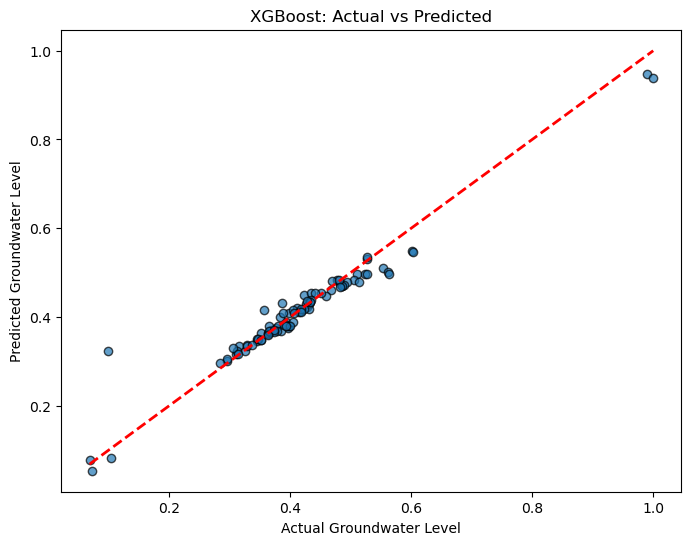

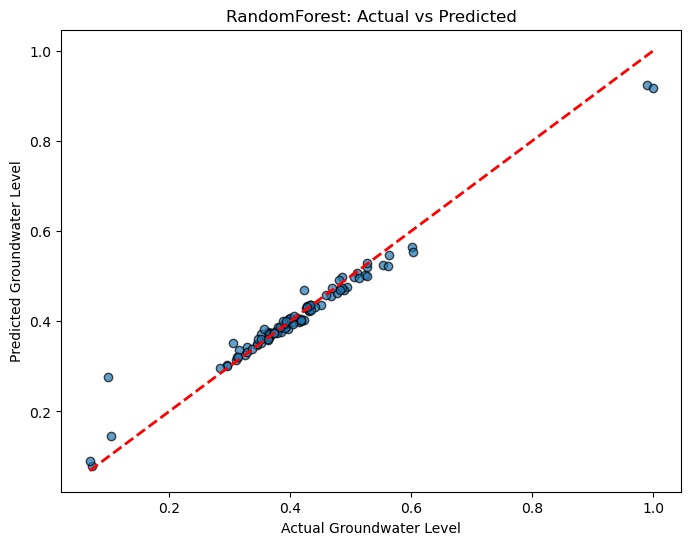

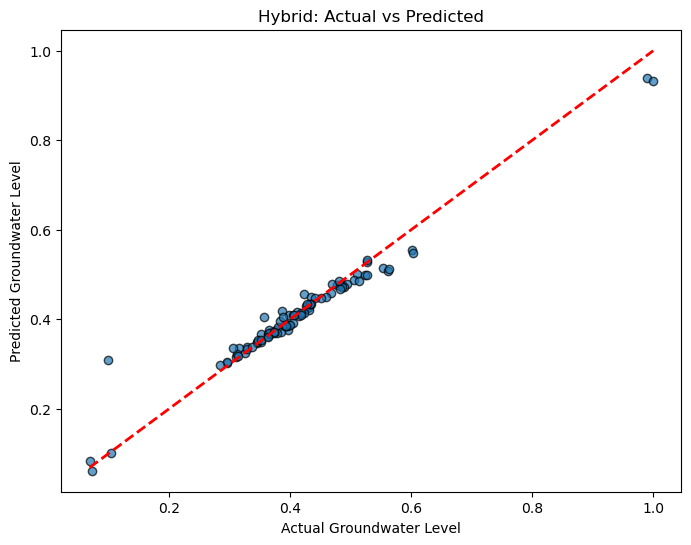

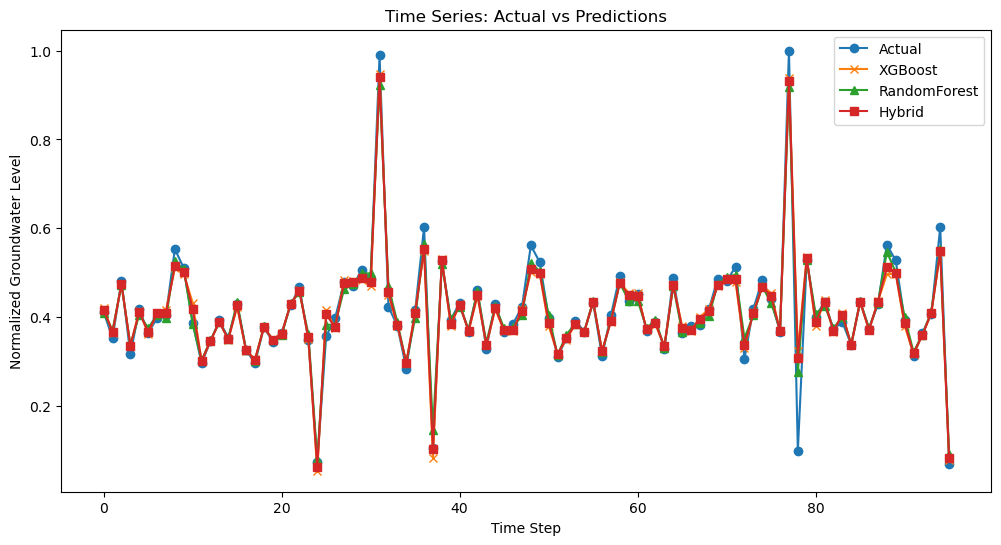

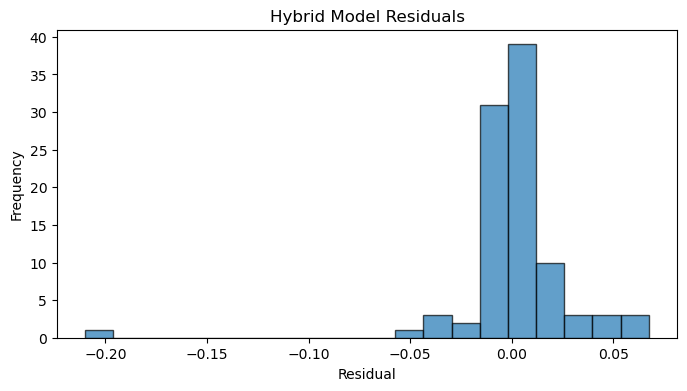

Training complete. Models and evaluations are ready for prediction.


In [295]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor

# ======================
# 1. Data Loading & Preprocessing
# ======================
def load_and_preprocess_data(file_path):
    df = pd.read_csv(file_path, encoding="latin1")
    
    # Identify measurement columns (those that include "meters below ground level")
    measurement_cols = [col for col in df.columns if "meters below ground level" in col]
    
    # Define identifier columns
    id_vars = ['Sr. No.', 'State_Name_With_LGD_Code', 'District_Name_With_LGD_Code', 
               'Block_Name_With_LGD_Code', 'GP_Name_With_LGD_Code', 'Village', 
               'Site_Name', 'TYPE', 'SOURCE', 'Well_ID', 'Latitude', 'Longitude', 
               'Well_Depth (meters)', 'Aquifer']
    
    # Pivot the data from wide to long format
    df_long = pd.melt(df, id_vars=id_vars, value_vars=measurement_cols, 
                      var_name='Measurement', value_name='Groundwater_Level')
    
    # Extract Season and Year from the Measurement column using regex
    df_long[['Season', 'Year']] = df_long['Measurement'].str.extract(r'(Pre-monsoon|Post-monsoon)_(\d{4})')
    df_long['Year'] = df_long['Year'].astype(int)
    
    # Convert groundwater levels to numeric (non-numeric values become NaN)
    df_long['Groundwater_Level'] = pd.to_numeric(df_long['Groundwater_Level'], errors='coerce')
    
    # Create a Month column: assume March for Pre-monsoon, September for Post-monsoon
    df_long['Month'] = df_long['Season'].apply(lambda s: 3 if s=="Pre-monsoon" else 9)
    df_long['Date'] = pd.to_datetime(dict(year=df_long['Year'], month=df_long['Month'], day=1))
    
    # Sort by site and date
    df_long.sort_values(by=['Site_Name', 'Date'], inplace=True)
    return df_long, measurement_cols

# ======================
# 2. Site Selection & Feature Engineering
# ======================
def prepare_site_data(df_long):
    # Select the site with the maximum number of measurements
    site_counts = df_long.groupby('Site_Name')['Groundwater_Level'].count()
    selected_site = site_counts.idxmax()
    print("Selected Site:", selected_site)
    
    df_site = df_long[df_long['Site_Name'] == selected_site].copy()
    df_site.sort_values(by='Date', inplace=True)
    df_site.reset_index(drop=True, inplace=True)
    
    # Interpolate missing groundwater values
    df_site['Groundwater_Level'] = df_site['Groundwater_Level'].interpolate()
    
    # Normalize groundwater levels using MinMaxScaler
    scaler = MinMaxScaler()
    df_site['Groundwater_Level_scaled'] = scaler.fit_transform(df_site[['Groundwater_Level']])
    
    # Create lag features (lags 1, 2, and 3) and a rolling mean (window=2)
    for lag in [1, 2, 3]:
        df_site[f'lag_{lag}'] = df_site['Groundwater_Level_scaled'].shift(lag)
    df_site['rolling_mean_2'] = df_site['Groundwater_Level_scaled'].rolling(window=2).mean()
    
    # Add time-based features (Year and Month)
    df_site['Year_feat'] = df_site['Year']
    df_site['Month_feat'] = df_site['Month']
    
    # Drop rows with NaN values (due to shifting/rolling)
    df_site_clean = df_site.dropna().copy()
    return df_site_clean, scaler

# ======================
# 3. Data Preparation for Modeling
# ======================
def prepare_model_data(df_site):
    features = ['lag_1', 'lag_2', 'lag_3', 'rolling_mean_2', 'Year_feat', 'Month_feat']
    target = 'Groundwater_Level_scaled'
    
    X = df_site[features].values
    y = df_site[target].values
    
    # Chronologically split the data: 70% training, 15% validation, 15% test
    n = len(df_site)
    train_end = int(0.7 * n)
    val_end = int(0.85 * n)
    
    X_train, y_train = X[:train_end], y[:train_end]
    X_val, y_val = X[train_end:val_end], y[train_end:val_end]
    X_test, y_test = X[val_end:], y[val_end:]
    
    print(f"Training: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")
    print("Features used:", features)
    return X_train, y_train, X_val, y_val, X_test, y_test, features

# ======================
# 4. Train XGBoost Model
# ======================
def train_xgboost_model(X_train, y_train, X_val, y_val):
    dtrain = xgb.DMatrix(X_train, label=y_train)
    dval = xgb.DMatrix(X_val, label=y_val)
    
    params = {
        'objective': 'reg:squarederror',
        'max_depth': 3,
        'learning_rate': 0.1,
        'random_state': 42
    }
    
    model_xgb = xgb.train(params, dtrain, num_boost_round=100, 
                          evals=[(dval, 'val')],
                          early_stopping_rounds=10, verbose_eval=False)
    return model_xgb

# ======================
# 5. Train RandomForest Regressor Model
# ======================
def train_rf_model(X_train, y_train):
    # Use RandomForestRegressor with example hyperparameters (tune as needed)
    rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
    rf_model.fit(X_train, y_train)
    return rf_model

# ======================
# 6. Evaluation Functions
# ======================
def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"\n{model_name} Evaluation:")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R2: {r2:.4f}")
    return rmse, mae, r2

def plot_predictions(y_true, y_pred, title):
    plt.figure(figsize=(8,6))
    plt.scatter(y_true, y_pred, alpha=0.7, edgecolors='k')
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    plt.xlabel("Actual Groundwater Level")
    plt.ylabel("Predicted Groundwater Level")
    plt.title(title)
    plt.show()

def plot_time_series(y_true, xgb_pred, rf_pred, hybrid_pred):
    plt.figure(figsize=(12,6))
    plt.plot(y_true, label="Actual", marker='o')
    plt.plot(xgb_pred, label="XGBoost", marker='x')
    plt.plot(rf_pred, label="RandomForest", marker='^')
    plt.plot(hybrid_pred, label="Hybrid", marker='s')
    plt.xlabel("Time Step")
    plt.ylabel("Normalized Groundwater Level")
    plt.title("Time Series: Actual vs Predictions")
    plt.legend()
    plt.show()

def plot_residuals(y_true, pred, title):
    residuals = y_true - pred
    plt.figure(figsize=(8,4))
    plt.hist(residuals, bins=20, edgecolor='black', alpha=0.7)
    plt.xlabel("Residual")
    plt.ylabel("Frequency")
    plt.title(title)
    plt.show()

# ======================
# 7. Hybrid Integration & Evaluation
# ======================
def evaluate_hybrid(xgb_model, rf_model, X_test, y_test, weight_xgb=0.7):
    # XGBoost predictions
    dtest = xgb.DMatrix(X_test)
    xgb_pred = xgb_model.predict(dtest)
    
    # RandomForest predictions
    rf_pred = rf_model.predict(X_test)
    
    # Hybrid prediction via weighted average (default: 70% XGBoost, 30% RF)
    hybrid_pred = weight_xgb * xgb_pred + (1 - weight_xgb) * rf_pred
    
    print("Evaluating Individual Models:")
    rmse_xgb, mae_xgb, r2_xgb = evaluate_model(y_test, xgb_pred, "XGBoost")
    rmse_rf, mae_rf, r2_rf = evaluate_model(y_test, rf_pred, "RandomForest")
    
    print("\nEvaluating Hybrid Model:")
    rmse_h, mae_h, r2_h = evaluate_model(y_test, hybrid_pred, "Hybrid")
    
    plot_predictions(y_test, xgb_pred, "XGBoost: Actual vs Predicted")
    plot_predictions(y_test, rf_pred, "RandomForest: Actual vs Predicted")
    plot_predictions(y_test, hybrid_pred, "Hybrid: Actual vs Predicted")
    plot_time_series(y_test, xgb_pred, rf_pred, hybrid_pred)
    plot_residuals(y_test, hybrid_pred, "Hybrid Model Residuals")
    
    return {
        "XGBoost": {"rmse": rmse_xgb, "mae": mae_xgb, "r2": r2_xgb},
        "RandomForest": {"rmse": rmse_rf, "mae": mae_rf, "r2": r2_rf},
        "Hybrid": {"rmse": rmse_h, "mae": mae_h, "r2": r2_h}
    }

# ======================
# 8. Main Function
# ======================
def main(file_path):
    print("Loading and preprocessing data...")
    df_long, measurement_cols = load_and_preprocess_data(file_path)
    
    print("Preparing site data and engineering features...")
    df_site, scaler = prepare_site_data(df_long)
    
    print("Preparing model data...")
    X_train, y_train, X_val, y_val, X_test, y_test, features = prepare_model_data(df_site)
    
    print("Training XGBoost model...")
    model_xgb = train_xgboost_model(X_train, y_train, X_val, y_val)
    
    print("Training RandomForest model...")
    model_rf = train_rf_model(X_train, y_train)
    
    print("Evaluating models and hybrid integration on test set...")
    eval_metrics = evaluate_hybrid(model_xgb, model_rf, X_test, y_test, weight_xgb=0.7)
    
    print("Training complete. Models and evaluations are ready for prediction.")
    return {
        'xgb_model': model_xgb,
        'rf_model': model_rf,
        'scaler': scaler,
        'features': features,
        'evaluation': eval_metrics
    }

if __name__ == "__main__":
    file_path = "./data.csv"  # Update with your dataset file path
    model_info = main(file_path)


# finally got something. the above two models are great


In [300]:
!pip install shap

Loading and preprocessing data...
Preparing site data and engineering features...
Selected Site: In the Village
Preparing model data...
Training: (445, 6), Validation: (96, 6), Test: (96, 6)
Features used: ['lag_1', 'lag_2', 'lag_3', 'rolling_mean_2', 'Year_feat', 'Month_feat']
Training individual base models...

xgb Evaluation:
RMSE: 0.0306
MAE: 0.0159
R2: 0.9423


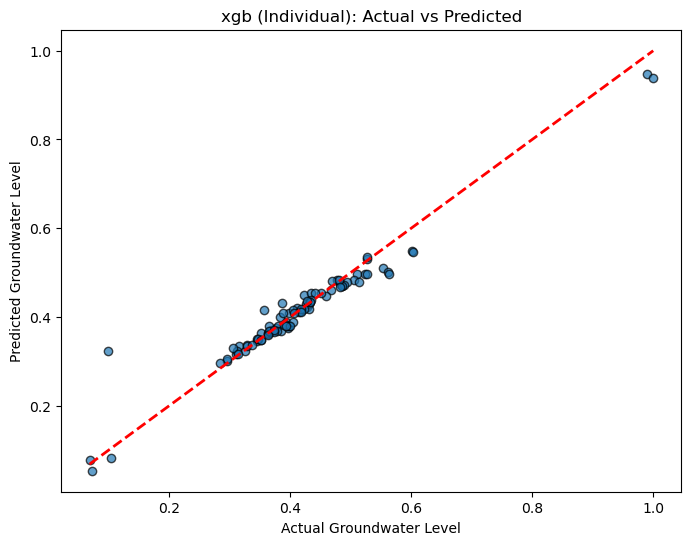


dt Evaluation:
RMSE: 0.0313
MAE: 0.0205
R2: 0.9399


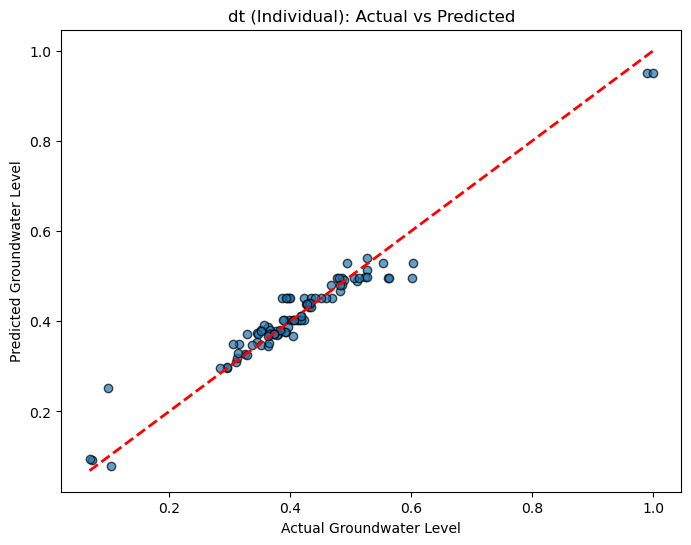


rf Evaluation:
RMSE: 0.0259
MAE: 0.0140
R2: 0.9588


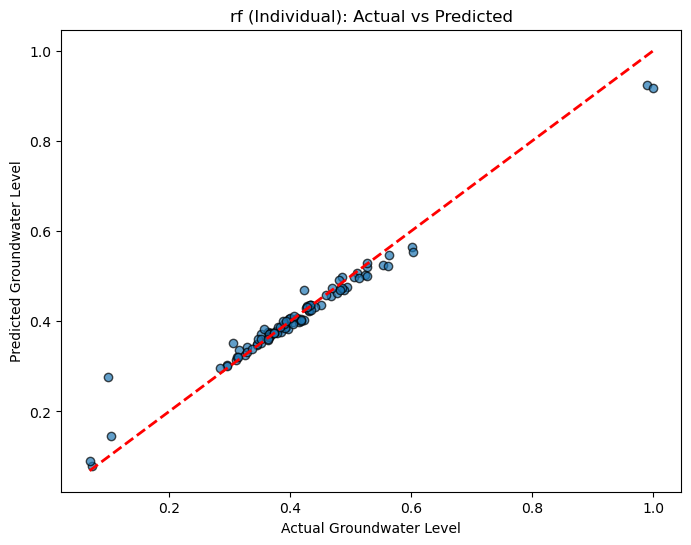

Training stacking ensemble model (Hybrid)...

Stacking Ensemble (Hybrid) Evaluation:
RMSE: 0.0169
MAE: 0.0111
R2: 0.9824


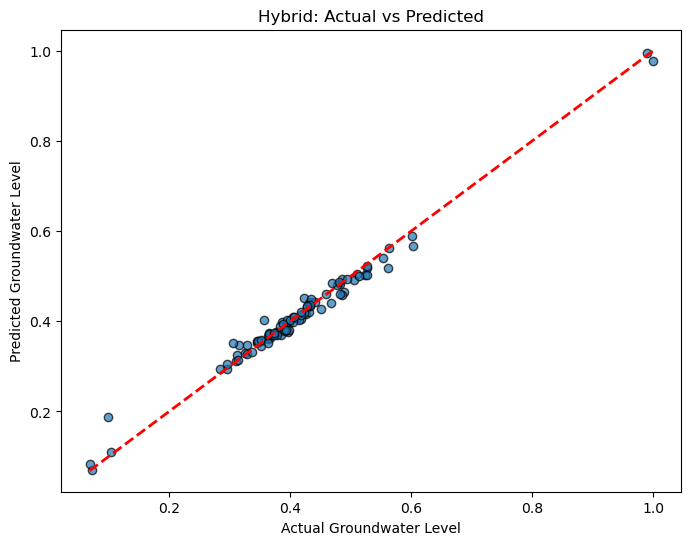

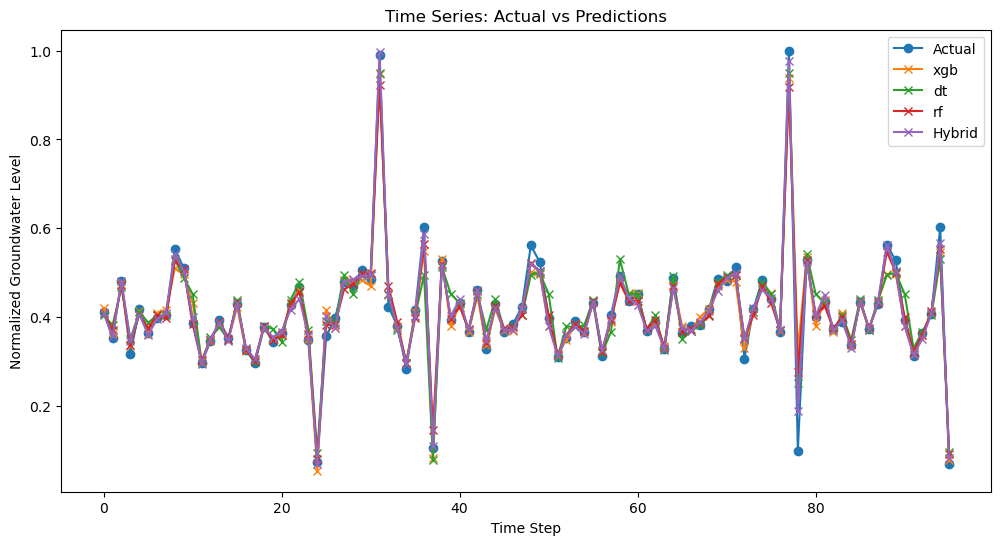

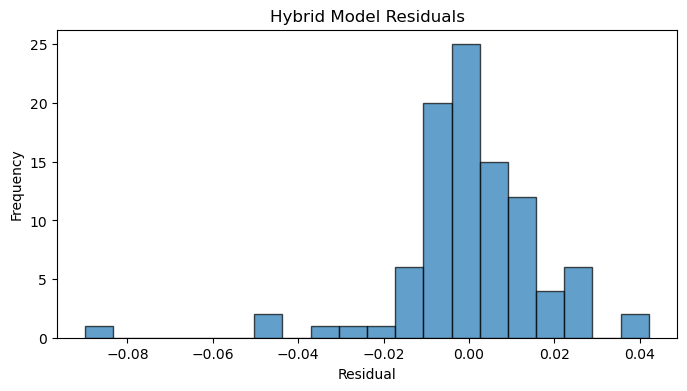

Training complete. Models and evaluations are ready for publication.


In [304]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import Ridge
import xgboost as xgb
import shap

# ======================
# 1. Data Loading & Preprocessing
# ======================
def load_and_preprocess_data(file_path):
    df = pd.read_csv(file_path, encoding="latin1")
    
    # Identify measurement columns (those that include "meters below ground level")
    measurement_cols = [col for col in df.columns if "meters below ground level" in col]
    
    # Identifier columns
    id_vars = ['Sr. No.', 'State_Name_With_LGD_Code', 'District_Name_With_LGD_Code', 
               'Block_Name_With_LGD_Code', 'GP_Name_With_LGD_Code', 'Village', 
               'Site_Name', 'TYPE', 'SOURCE', 'Well_ID', 'Latitude', 'Longitude', 
               'Well_Depth (meters)', 'Aquifer']
    
    # Pivot data from wide to long format
    df_long = pd.melt(df, id_vars=id_vars, value_vars=measurement_cols,
                      var_name='Measurement', value_name='Groundwater_Level')
    
    # Extract Season and Year from Measurement column
    df_long[['Season', 'Year']] = df_long['Measurement'].str.extract(r'(Pre-monsoon|Post-monsoon)_(\d{4})')
    df_long['Year'] = df_long['Year'].astype(int)
    
    # Convert groundwater levels to numeric; non-numeric become NaN
    df_long['Groundwater_Level'] = pd.to_numeric(df_long['Groundwater_Level'], errors='coerce')
    
    # Create Month column: assume March for Pre-monsoon, September for Post-monsoon
    df_long['Month'] = df_long['Season'].apply(lambda s: 3 if s=="Pre-monsoon" else 9)
    df_long['Date'] = pd.to_datetime(dict(year=df_long['Year'], month=df_long['Month'], day=1))
    
    df_long.sort_values(by=['Site_Name', 'Date'], inplace=True)
    return df_long, measurement_cols

# ======================
# 2. Site Selection & Feature Engineering
# ======================
def prepare_site_data(df_long):
    # Select site with most measurements
    site_counts = df_long.groupby('Site_Name')['Groundwater_Level'].count()
    selected_site = site_counts.idxmax()
    print("Selected Site:", selected_site)
    
    df_site = df_long[df_long['Site_Name'] == selected_site].copy()
    df_site.sort_values(by='Date', inplace=True)
    df_site.reset_index(drop=True, inplace=True)
    
    # Interpolate missing values
    df_site['Groundwater_Level'] = df_site['Groundwater_Level'].interpolate()
    
    # Normalize groundwater levels
    scaler = MinMaxScaler()
    df_site['Groundwater_Level_scaled'] = scaler.fit_transform(df_site[['Groundwater_Level']])
    
    # Create lag features (1, 2, 3) and rolling mean (window=2)
    for lag in [1, 2, 3]:
        df_site[f'lag_{lag}'] = df_site['Groundwater_Level_scaled'].shift(lag)
    df_site['rolling_mean_2'] = df_site['Groundwater_Level_scaled'].rolling(window=2).mean()
    
    # Add time-based features
    df_site['Year_feat'] = df_site['Year']
    df_site['Month_feat'] = df_site['Month']
    
    # Drop rows with NaN values
    df_site_clean = df_site.dropna().copy()
    return df_site_clean, scaler

# ======================
# 3. Data Preparation for Modeling
# ======================
def prepare_model_data(df_site):
    features = ['lag_1', 'lag_2', 'lag_3', 'rolling_mean_2', 'Year_feat', 'Month_feat']
    target = 'Groundwater_Level_scaled'
    
    X = df_site[features].values
    y = df_site[target].values
    
    # Chronological split: 70% train, 15% validation, 15% test
    n = len(df_site)
    train_end = int(0.7 * n)
    val_end = int(0.85 * n)
    
    X_train, y_train = X[:train_end], y[:train_end]
    X_val, y_val = X[train_end:val_end], y[train_end:val_end]
    X_test, y_test = X[val_end:], y[val_end:]
    
    print(f"Training: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")
    print("Features used:", features)
    return X_train, y_train, X_val, y_val, X_test, y_test, features

# ======================
# 4. Train Base Models for Stacking
# ======================
def get_base_models():
    # Use XGBoost regressor via scikit-learn API for compatibility
    xgb_model = xgb.XGBRegressor(objective='reg:squarederror', max_depth=3,
                                 learning_rate=0.1, n_estimators=100, random_state=42)
    dt_model = DecisionTreeRegressor(max_depth=10, random_state=42)
    rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
    return [('xgb', xgb_model), ('dt', dt_model), ('rf', rf_model)]

# ======================
# 5. Train Stacking Ensemble Model
# ======================
def train_stacking_model(X_train, y_train, X_val, y_val):
    from sklearn.ensemble import StackingRegressor
    from sklearn.linear_model import Ridge
    base_models = get_base_models()
    
    # Meta-learner: Ridge regression
    meta_model = Ridge(alpha=1.0)
    
    stack_model = StackingRegressor(estimators=base_models, final_estimator=meta_model, cv=5)
    
    # Train on combined training and validation sets for best performance
    X_stack = np.concatenate([X_train, X_val])
    y_stack = np.concatenate([y_train, y_val])
    stack_model.fit(X_stack, y_stack)
    
    return stack_model

# ======================
# 6. Evaluation Functions
# ======================
def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"\n{model_name} Evaluation:")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R2: {r2:.4f}")
    return rmse, mae, r2

def plot_predictions(y_true, y_pred, title):
    plt.figure(figsize=(8,6))
    plt.scatter(y_true, y_pred, alpha=0.7, edgecolors='k')
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    plt.xlabel("Actual Groundwater Level")
    plt.ylabel("Predicted Groundwater Level")
    plt.title(title)
    plt.show()

def plot_time_series(y_true, preds_dict):
    plt.figure(figsize=(12,6))
    plt.plot(y_true, label="Actual", marker='o')
    for model_name, pred in preds_dict.items():
        plt.plot(pred, label=model_name, marker='x')
    plt.xlabel("Time Step")
    plt.ylabel("Normalized Groundwater Level")
    plt.title("Time Series: Actual vs Predictions")
    plt.legend()
    plt.show()

def plot_residuals(y_true, y_pred, title):
    residuals = y_true - y_pred
    plt.figure(figsize=(8,4))
    plt.hist(residuals, bins=20, edgecolor='black', alpha=0.7)
    plt.xlabel("Residual")
    plt.ylabel("Frequency")
    plt.title(title)
    plt.show()

# ======================
# 7. Main Function
# ======================
def main(file_path):
    # Load and preprocess data
    print("Loading and preprocessing data...")
    df_long, measurement_cols = load_and_preprocess_data(file_path)
    
    # Site selection and feature engineering
    print("Preparing site data and engineering features...")
    df_site, scaler = prepare_site_data(df_long)
    
    # Data preparation
    print("Preparing model data...")
    X_train, y_train, X_val, y_val, X_test, y_test, features = prepare_model_data(df_site)
    
    # Train individual base models (for evaluation)
    print("Training individual base models...")
    base_models = get_base_models()
    predictions = {}
    eval_metrics = {}
    
    # Train each base model and evaluate
    for name, model in base_models:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        rmse, mae, r2 = evaluate_model(y_test, y_pred, name)
        predictions[name] = y_pred
        eval_metrics[name] = {"rmse": rmse, "mae": mae, "r2": r2}
        plot_predictions(y_test, y_pred, f"{name} (Individual): Actual vs Predicted")
    
    # Train stacking ensemble (hybrid)
    print("Training stacking ensemble model (Hybrid)...")
    stack_model = train_stacking_model(X_train, y_train, X_val, y_val)
    y_pred_stack = stack_model.predict(X_test)
    rmse_stack, mae_stack, r2_stack = evaluate_model(y_test, y_pred_stack, "Stacking Ensemble (Hybrid)")
    predictions["Hybrid"] = y_pred_stack
    eval_metrics["Hybrid"] = {"rmse": rmse_stack, "mae": mae_stack, "r2": r2_stack}
    plot_predictions(y_test, y_pred_stack, "Hybrid: Actual vs Predicted")
    
    # Plot time series and residuals for hybrid
    plot_time_series(y_test, predictions)
    plot_residuals(y_test, y_pred_stack, "Hybrid Model Residuals")
    
    print("Training complete. Models and evaluations are ready for publication.")
    return {
        'scaler': scaler,
        'features': features,
        'base_models': base_models,
        'stack_model': stack_model,
        'evaluation': eval_metrics
    }

if __name__ == "__main__":
    file_path = "./data.csv"  # Update with your dataset file path
    model_info = main(file_path)


Selected Site: In the Village
Training: (445, 6), Validation: (96, 6), Test: (96, 6)
Features used: ['lag_1', 'lag_2', 'lag_3', 'rolling_mean_2', 'Year_feat', 'Month_feat']

xgb Evaluation:
RMSE: 0.0306
MAE: 0.0159
R2: 0.9423

xgb Overfitting Check:
Training - RMSE: 0.0083, MAE: 0.0062, R2: 0.9964
Test     - RMSE: 0.0306, MAE: 0.0159, R2: 0.9423


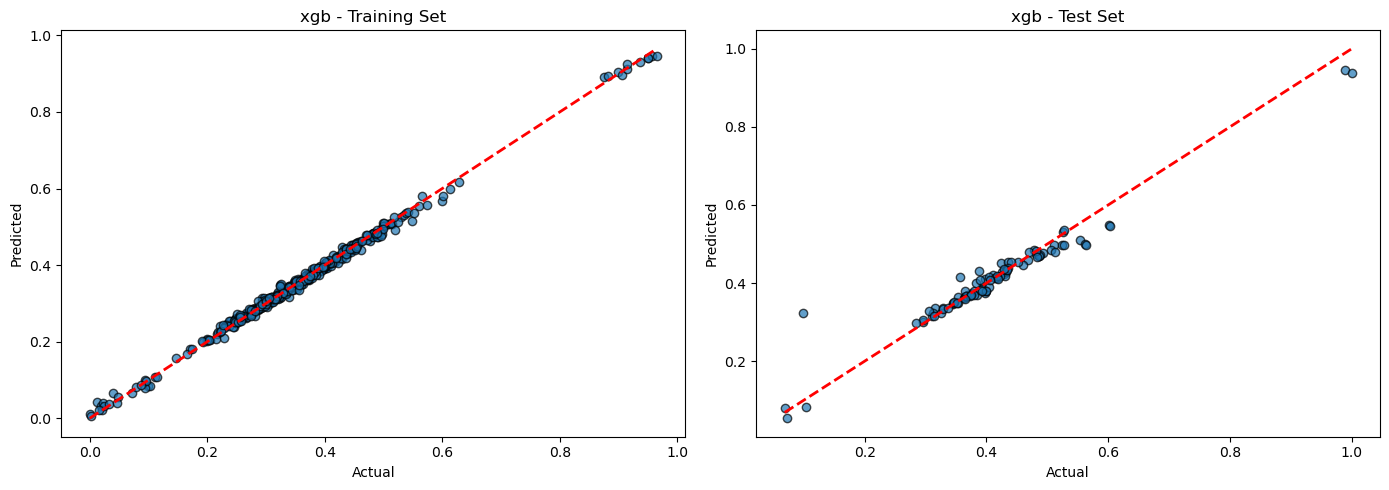


dt Evaluation:
RMSE: 0.0313
MAE: 0.0205
R2: 0.9399

dt Overfitting Check:
Training - RMSE: 0.0071, MAE: 0.0045, R2: 0.9974
Test     - RMSE: 0.0313, MAE: 0.0205, R2: 0.9399


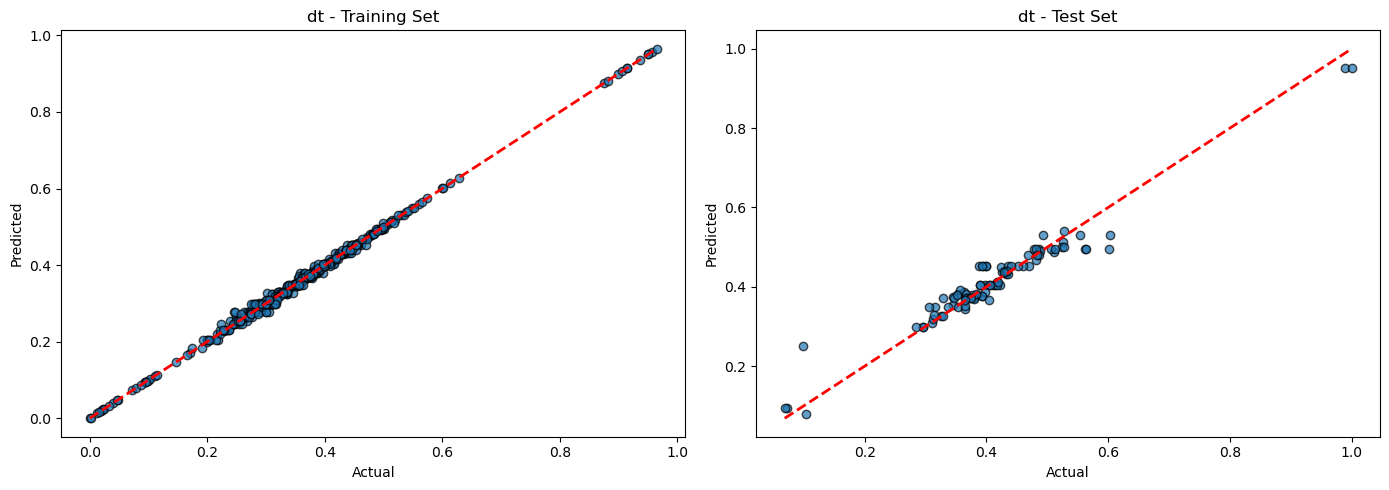


rf Evaluation:
RMSE: 0.0259
MAE: 0.0140
R2: 0.9588

rf Overfitting Check:
Training - RMSE: 0.0094, MAE: 0.0061, R2: 0.9953
Test     - RMSE: 0.0259, MAE: 0.0140, R2: 0.9588


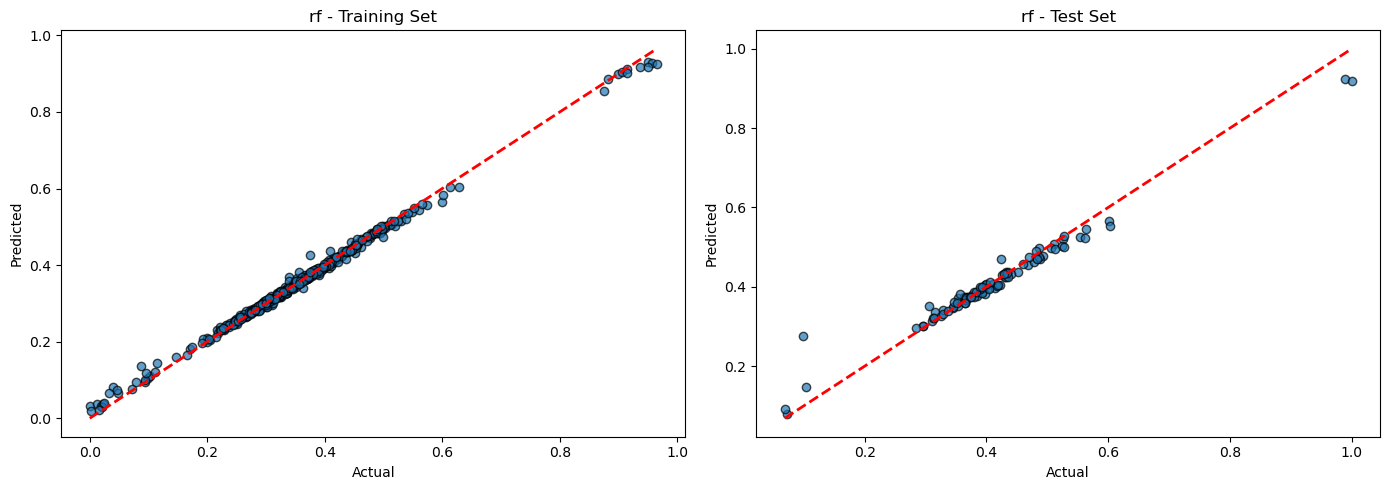


Stacking Ensemble (Hybrid) Evaluation:
RMSE: 0.0169
MAE: 0.0111
R2: 0.9824

Stacking Ensemble (Hybrid) Overfitting Check:
Training - RMSE: 0.0065, MAE: 0.0050, R2: 0.9978
Test     - RMSE: 0.0169, MAE: 0.0111, R2: 0.9824


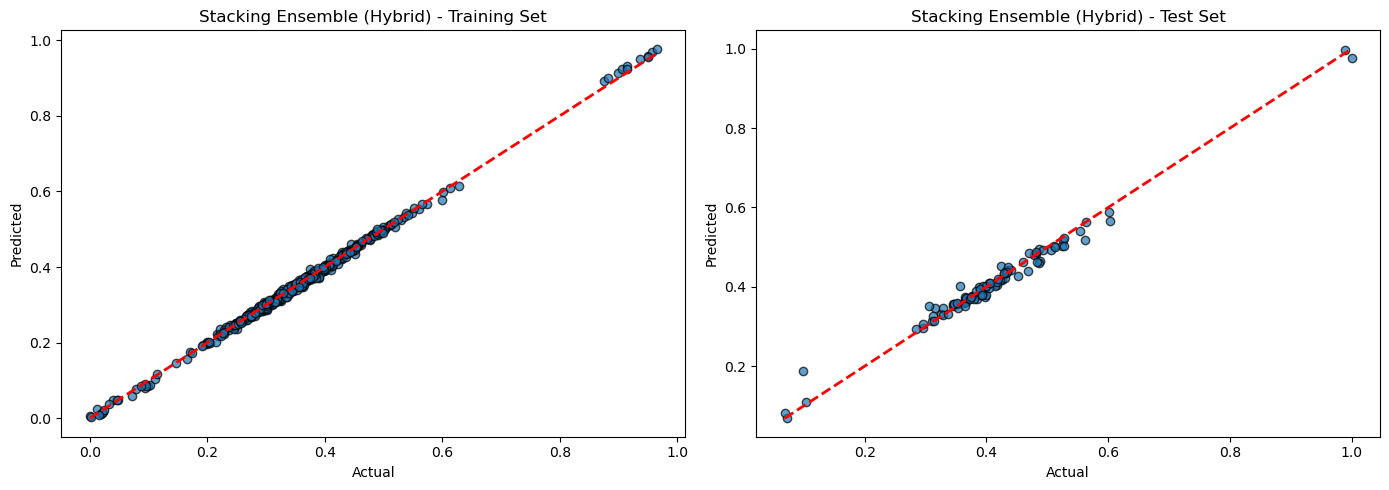

In [334]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import Ridge
import xgboost as xgb
import shap

# ======================
# 1. Data Loading & Preprocessing
# ======================
def load_and_preprocess_data(file_path):
    df = pd.read_csv(file_path, encoding="latin1")
    
    # Identify measurement columns (those that include "meters below ground level")
    measurement_cols = [col for col in df.columns if "meters below ground level" in col]
    
    # Identifier columns
    id_vars = ['Sr. No.', 'State_Name_With_LGD_Code', 'District_Name_With_LGD_Code', 
               'Block_Name_With_LGD_Code', 'GP_Name_With_LGD_Code', 'Village', 
               'Site_Name', 'TYPE', 'SOURCE', 'Well_ID', 'Latitude', 'Longitude', 
               'Well_Depth (meters)', 'Aquifer']
    
    # Pivot data from wide to long format
    df_long = pd.melt(df, id_vars=id_vars, value_vars=measurement_cols,
                      var_name='Measurement', value_name='Groundwater_Level')
    
    # Extract Season and Year from Measurement column
    df_long[['Season', 'Year']] = df_long['Measurement'].str.extract(r'(Pre-monsoon|Post-monsoon)_(\d{4})')
    df_long['Year'] = df_long['Year'].astype(int)
    
    # Convert groundwater levels to numeric; non-numeric become NaN
    df_long['Groundwater_Level'] = pd.to_numeric(df_long['Groundwater_Level'], errors='coerce')
    
    # Create Month column: assume March for Pre-monsoon, September for Post-monsoon
    df_long['Month'] = df_long['Season'].apply(lambda s: 3 if s=="Pre-monsoon" else 9)
    df_long['Date'] = pd.to_datetime(dict(year=df_long['Year'], month=df_long['Month'], day=1))
    
    df_long.sort_values(by=['Site_Name', 'Date'], inplace=True)
    return df_long, measurement_cols

# ======================
# 2. Site Selection & Feature Engineering
# ======================
def prepare_site_data(df_long):
    # Select site with most measurements
    site_counts = df_long.groupby('Site_Name')['Groundwater_Level'].count()
    selected_site = site_counts.idxmax()
    print("Selected Site:", selected_site)
    
    df_site = df_long[df_long['Site_Name'] == selected_site].copy()
    df_site.sort_values(by='Date', inplace=True)
    df_site.reset_index(drop=True, inplace=True)
    
    # Interpolate missing values
    df_site['Groundwater_Level'] = df_site['Groundwater_Level'].interpolate()
    
    # Normalize groundwater levels
    scaler = MinMaxScaler()
    df_site['Groundwater_Level_scaled'] = scaler.fit_transform(df_site[['Groundwater_Level']])
    
    # Create lag features (1, 2, 3) and rolling mean (window=2)
    for lag in [1, 2, 3]:
        df_site[f'lag_{lag}'] = df_site['Groundwater_Level_scaled'].shift(lag)
    df_site['rolling_mean_2'] = df_site['Groundwater_Level_scaled'].rolling(window=2).mean()
    
    # Add time-based features
    df_site['Year_feat'] = df_site['Year']
    df_site['Month_feat'] = df_site['Month']
    
    # Drop rows with NaN values
    df_site_clean = df_site.dropna().copy()
    return df_site_clean, scaler

# ======================
# 3. Data Preparation for Modeling
# ======================
def prepare_model_data(df_site):
    features = ['lag_1', 'lag_2', 'lag_3', 'rolling_mean_2', 'Year_feat', 'Month_feat']
    target = 'Groundwater_Level_scaled'
    
    X = df_site[features].values
    y = df_site[target].values
    
    # Chronological split: 70% train, 15% validation, 15% test
    n = len(df_site)
    train_end = int(0.7 * n)
    val_end = int(0.85 * n)
    
    X_train, y_train = X[:train_end], y[:train_end]
    X_val, y_val = X[train_end:val_end], y[train_end:val_end]
    X_test, y_test = X[val_end:], y[val_end:]
    
    print(f"Training: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")
    print("Features used:", features)
    return X_train, y_train, X_val, y_val, X_test, y_test, features

# ======================
# 4. Train Base Models for Stacking
# ======================
def get_base_models():
    # Use XGBoost regressor via scikit-learn API for compatibility
    xgb_model = xgb.XGBRegressor(objective='reg:squarederror', max_depth=3,
                                 learning_rate=0.1, n_estimators=100, random_state=42)
    dt_model = DecisionTreeRegressor(max_depth=10, random_state=42)
    rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
    return [('xgb', xgb_model), ('dt', dt_model), ('rf', rf_model)]

# ======================
# 5. Train Stacking Ensemble Model
# ======================
def train_stacking_model(X_train, y_train, X_val, y_val):
    from sklearn.ensemble import StackingRegressor
    from sklearn.linear_model import Ridge
    base_models = get_base_models()
    
    # Meta-learner: Ridge regression
    meta_model = Ridge(alpha=1.0)
    
    stack_model = StackingRegressor(estimators=base_models, final_estimator=meta_model, cv=5)
    
    # Train on combined training and validation sets for best performance
    X_stack = np.concatenate([X_train, X_val])
    y_stack = np.concatenate([y_train, y_val])
    stack_model.fit(X_stack, y_stack)
    
    return stack_model

# ======================
# 6. Evaluation Functions
# ======================
def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"\n{model_name} Evaluation:")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R2: {r2:.4f}")
    return rmse, mae, r2

def plot_predictions(y_true, y_pred, title):
    plt.figure(figsize=(8,6))
    plt.scatter(y_true, y_pred, alpha=0.7, edgecolors='k')
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    plt.xlabel("Actual Groundwater Level")
    plt.ylabel("Predicted Groundwater Level")
    plt.title(title)
    plt.show()

def plot_time_series(y_true, preds_dict):
    plt.figure(figsize=(12,6))
    plt.plot(y_true, label="Actual", marker='o')
    for model_name, pred in preds_dict.items():
        plt.plot(pred, label=model_name, marker='x')
    plt.xlabel("Time Step")
    plt.ylabel("Normalized Groundwater Level")
    plt.title("Time Series: Actual vs Predictions")
    plt.legend()
    plt.show()

def plot_residuals(y_true, y_pred, title):
    residuals = y_true - y_pred
    plt.figure(figsize=(8,4))
    plt.hist(residuals, bins=20, edgecolor='black', alpha=0.7)
    plt.xlabel("Residual")
    plt.ylabel("Frequency")
    plt.title(title)
    plt.show()

# ======================
# 7. Main Function
# ======================
def main(file_path):
    # Data loading, preprocessing, feature engineering, etc.
    df_long, _ = load_and_preprocess_data(file_path)
    df_site, scaler = prepare_site_data(df_long)
    X_train, y_train, X_val, y_val, X_test, y_test, features = prepare_model_data(df_site)
    
    # Train and evaluate individual base models
    base_models = get_base_models()
    predictions = {}
    eval_metrics = {}
    
    for name, model in base_models:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        evaluate_model(y_test, y_pred, name)
        predictions[name] = y_pred
        # Check for overfitting
        check_overfitting(model, X_train, y_train, X_test, y_test, model_name=name)
    
    # Train stacking ensemble model
    stack_model = train_stacking_model(X_train, y_train, X_val, y_val)
    y_pred_stack = stack_model.predict(X_test)
    evaluate_model(y_test, y_pred_stack, "Stacking Ensemble (Hybrid)")
    check_overfitting(stack_model, X_train, y_train, X_test, y_test, model_name="Stacking Ensemble (Hybrid)")
    
    # Additional plotting or saving model details
    return {
        'scaler': scaler,
        'features': features,
        'base_models': base_models,
        'stack_model': stack_model,
        'evaluation': eval_metrics
    }
if __name__ == "__main__":
    file_path = "./data.csv"  # Update with your dataset file path
    model_info = main(file_path)


# the above two codes are final. 1st show evaluation and visualization. And the 2nd check for overfitting

# below i am doing hyperparameter tuning

Selected Site: In the Village
Training: (445, 6), Validation: (96, 6), Test: (96, 6)
Features used: ['lag_1', 'lag_2', 'lag_3', 'rolling_mean_2', 'Year_feat', 'Month_feat']

xgb Evaluation:
RMSE: 0.0306
MAE: 0.0159
R2: 0.9423

xgb Overfitting Check:
Training - RMSE: 0.0083, MAE: 0.0062, R2: 0.9964
Test     - RMSE: 0.0306, MAE: 0.0159, R2: 0.9423


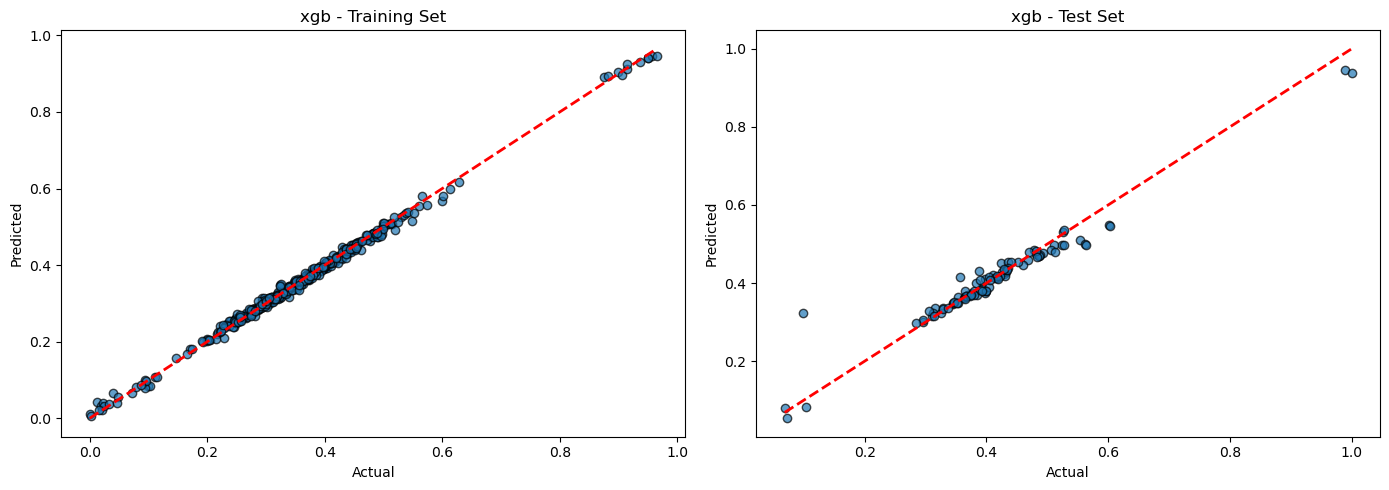


dt Evaluation:
RMSE: 0.0394
MAE: 0.0268
R2: 0.9046

dt Overfitting Check:
Training - RMSE: 0.0341, MAE: 0.0163, R2: 0.9391
Test     - RMSE: 0.0394, MAE: 0.0268, R2: 0.9046


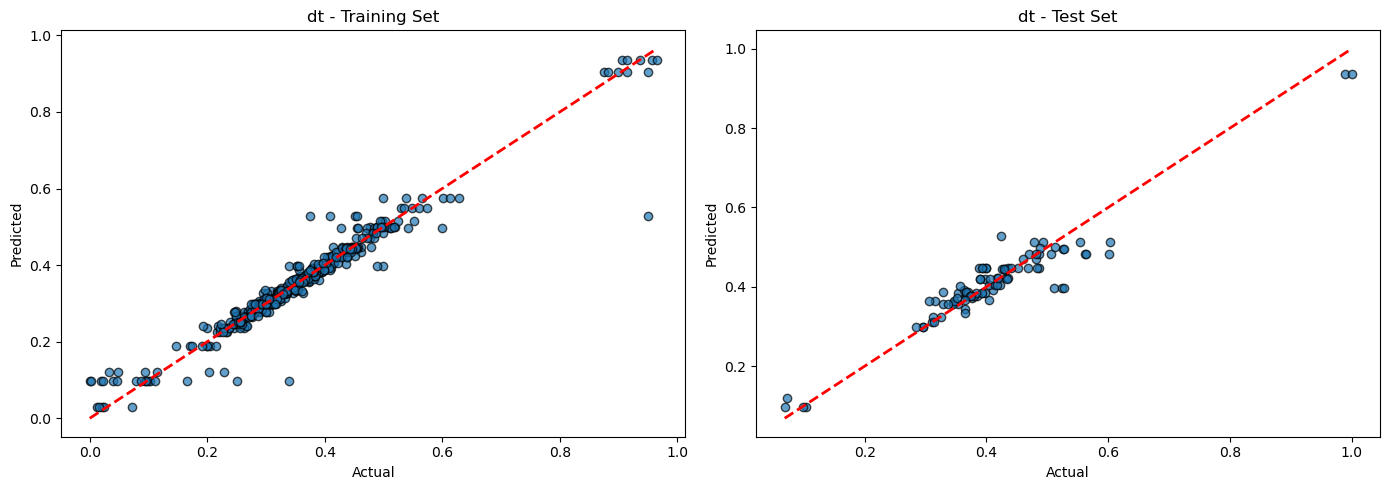


rf Evaluation:
RMSE: 0.0259
MAE: 0.0140
R2: 0.9588

rf Overfitting Check:
Training - RMSE: 0.0094, MAE: 0.0061, R2: 0.9953
Test     - RMSE: 0.0259, MAE: 0.0140, R2: 0.9588


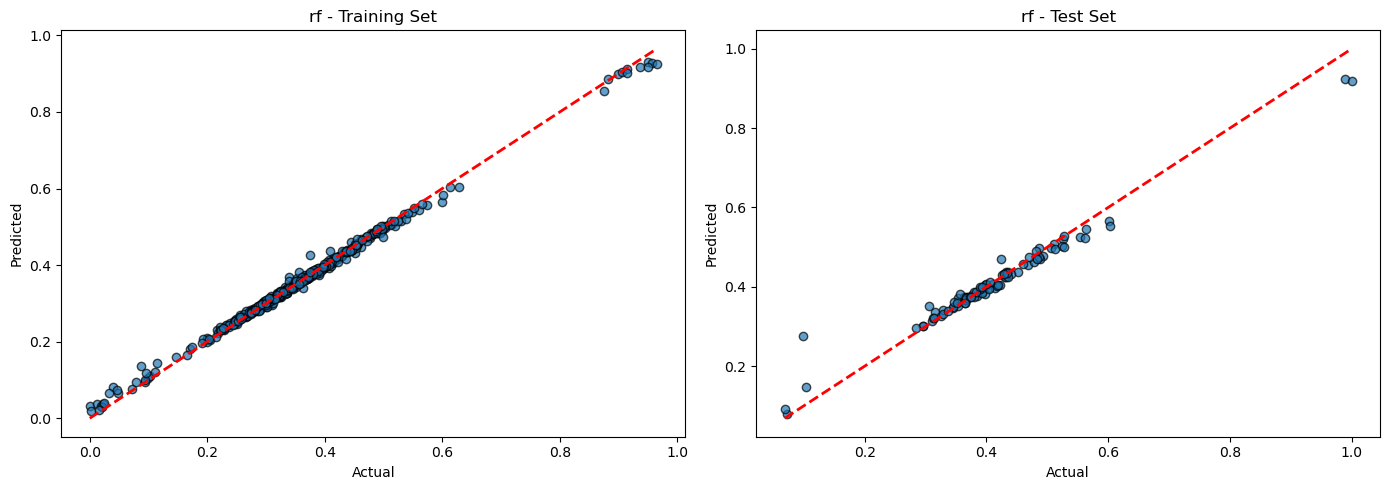


Stacking Ensemble (Hybrid) Evaluation:
RMSE: 0.0164
MAE: 0.0104
R2: 0.9836

Stacking Ensemble (Hybrid) Overfitting Check:
Training - RMSE: 0.0093, MAE: 0.0064, R2: 0.9955
Test     - RMSE: 0.0164, MAE: 0.0104, R2: 0.9836


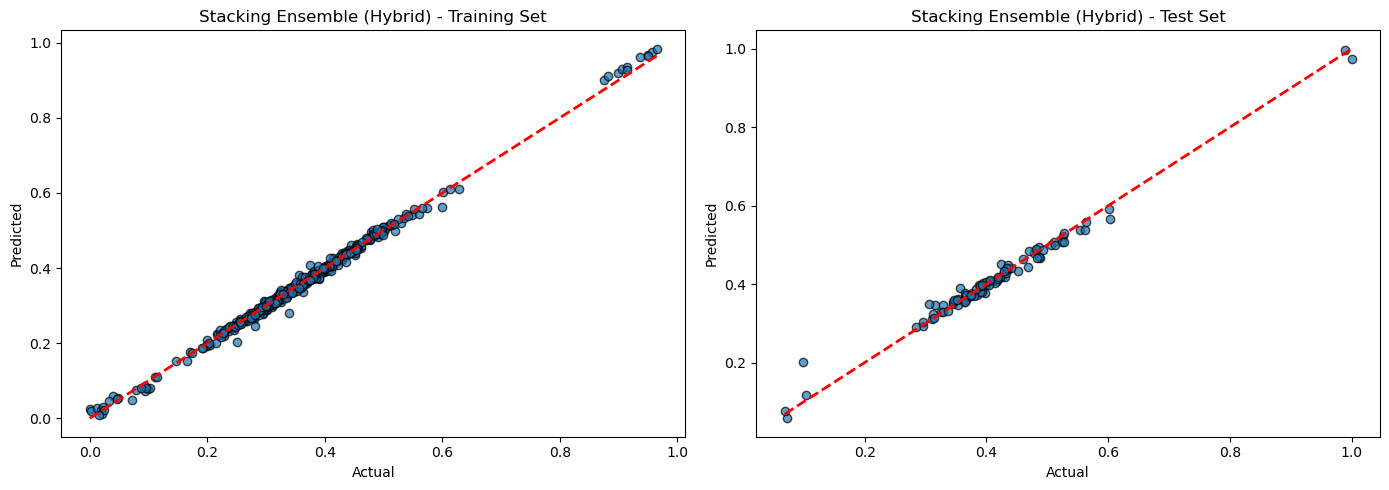

In [356]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import Ridge
import xgboost as xgb
import shap

# ======================
# 1. Data Loading & Preprocessing
# ======================
def load_and_preprocess_data(file_path):
    df = pd.read_csv(file_path, encoding="latin1")
    
    # Identify measurement columns (those that include "meters below ground level")
    measurement_cols = [col for col in df.columns if "meters below ground level" in col]
    
    # Identifier columns
    id_vars = ['Sr. No.', 'State_Name_With_LGD_Code', 'District_Name_With_LGD_Code', 
               'Block_Name_With_LGD_Code', 'GP_Name_With_LGD_Code', 'Village', 
               'Site_Name', 'TYPE', 'SOURCE', 'Well_ID', 'Latitude', 'Longitude', 
               'Well_Depth (meters)', 'Aquifer']
    
    # Pivot data from wide to long format
    df_long = pd.melt(df, id_vars=id_vars, value_vars=measurement_cols,
                      var_name='Measurement', value_name='Groundwater_Level')
    
    # Extract Season and Year from Measurement column
    df_long[['Season', 'Year']] = df_long['Measurement'].str.extract(r'(Pre-monsoon|Post-monsoon)_(\d{4})')
    df_long['Year'] = df_long['Year'].astype(int)
    
    # Convert groundwater levels to numeric; non-numeric become NaN
    df_long['Groundwater_Level'] = pd.to_numeric(df_long['Groundwater_Level'], errors='coerce')
    
    # Create Month column: assume March for Pre-monsoon, September for Post-monsoon
    df_long['Month'] = df_long['Season'].apply(lambda s: 3 if s=="Pre-monsoon" else 9)
    df_long['Date'] = pd.to_datetime(dict(year=df_long['Year'], month=df_long['Month'], day=1))
    
    df_long.sort_values(by=['Site_Name', 'Date'], inplace=True)
    return df_long, measurement_cols

# ======================
# 2. Site Selection & Feature Engineering
# ======================
def prepare_site_data(df_long):
    # Select site with most measurements
    site_counts = df_long.groupby('Site_Name')['Groundwater_Level'].count()
    selected_site = site_counts.idxmax()
    print("Selected Site:", selected_site)
    
    df_site = df_long[df_long['Site_Name'] == selected_site].copy()
    df_site.sort_values(by='Date', inplace=True)
    df_site.reset_index(drop=True, inplace=True)
    
    # Interpolate missing values
    df_site['Groundwater_Level'] = df_site['Groundwater_Level'].interpolate()
    
    # Normalize groundwater levels
    scaler = MinMaxScaler()
    df_site['Groundwater_Level_scaled'] = scaler.fit_transform(df_site[['Groundwater_Level']])
    
    # Create lag features (1, 2, 3) and rolling mean (window=2)
    for lag in [1, 2, 3]:
        df_site[f'lag_{lag}'] = df_site['Groundwater_Level_scaled'].shift(lag)
    df_site['rolling_mean_2'] = df_site['Groundwater_Level_scaled'].rolling(window=2).mean()
    
    # Add time-based features
    df_site['Year_feat'] = df_site['Year']
    df_site['Month_feat'] = df_site['Month']
    
    # Drop rows with NaN values
    df_site_clean = df_site.dropna().copy()
    return df_site_clean, scaler

# ======================
# 3. Data Preparation for Modeling
# ======================
def prepare_model_data(df_site):
    features = ['lag_1', 'lag_2', 'lag_3', 'rolling_mean_2', 'Year_feat', 'Month_feat']
    target = 'Groundwater_Level_scaled'
    
    X = df_site[features].values
    y = df_site[target].values
    
    # Chronological split: 70% train, 15% validation, 15% test
    n = len(df_site)
    train_end = int(0.7 * n)
    val_end = int(0.85 * n)
    
    X_train, y_train = X[:train_end], y[:train_end]
    X_val, y_val = X[train_end:val_end], y[train_end:val_end]
    X_test, y_test = X[val_end:], y[val_end:]
    
    print(f"Training: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")
    print("Features used:", features)
    return X_train, y_train, X_val, y_val, X_test, y_test, features

# ======================
# 4. Train Base Models for Stacking
# ======================
def get_base_models():
    # Use XGBoost regressor via scikit-learn API for compatibility
    xgb_model = xgb.XGBRegressor(objective='reg:squarederror', max_depth=3,
                                 learning_rate=0.1, n_estimators=100, random_state=42)
    # dt_model = DecisionTreeRegressor(max_depth=10, random_state=42)
    dt_model = DecisionTreeRegressor(
        max_depth=10,
        random_state=42,
        min_samples_split=5,    # require at least 10 samples to split
        min_samples_leaf=5       # require at least 4 samples in a leaf
    )
    rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
    return [('xgb', xgb_model), ('dt', dt_model), ('rf', rf_model)]

# ======================
# 5. Train Stacking Ensemble Model
# ======================
def train_stacking_model(X_train, y_train, X_val, y_val):
    from sklearn.ensemble import StackingRegressor
    from sklearn.linear_model import Ridge
    base_models = get_base_models()
    
    # Meta-learner: Ridge regression
    meta_model = Ridge(alpha=1.0)
    
    stack_model = StackingRegressor(estimators=base_models, final_estimator=meta_model, cv=5)
    
    # Train on combined training and validation sets for best performance
    X_stack = np.concatenate([X_train, X_val])
    y_stack = np.concatenate([y_train, y_val])
    stack_model.fit(X_stack, y_stack)
    
    return stack_model

# ======================
# 6. Evaluation Functions
# ======================
def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"\n{model_name} Evaluation:")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R2: {r2:.4f}")
    return rmse, mae, r2

def plot_predictions(y_true, y_pred, title):
    plt.figure(figsize=(8,6))
    plt.scatter(y_true, y_pred, alpha=0.7, edgecolors='k')
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    plt.xlabel("Actual Groundwater Level")
    plt.ylabel("Predicted Groundwater Level")
    plt.title(title)
    plt.show()

def plot_time_series(y_true, preds_dict):
    plt.figure(figsize=(12,6))
    plt.plot(y_true, label="Actual", marker='o')
    for model_name, pred in preds_dict.items():
        plt.plot(pred, label=model_name, marker='x')
    plt.xlabel("Time Step")
    plt.ylabel("Normalized Groundwater Level")
    plt.title("Time Series: Actual vs Predictions")
    plt.legend()
    plt.show()

def plot_residuals(y_true, y_pred, title):
    residuals = y_true - y_pred
    plt.figure(figsize=(8,4))
    plt.hist(residuals, bins=20, edgecolor='black', alpha=0.7)
    plt.xlabel("Residual")
    plt.ylabel("Frequency")
    plt.title(title)
    plt.show()

# ======================
# 7. Main Function
# ======================
def main(file_path):
    # Data loading, preprocessing, feature engineering, etc.
    df_long, _ = load_and_preprocess_data(file_path)
    df_site, scaler = prepare_site_data(df_long)
    X_train, y_train, X_val, y_val, X_test, y_test, features = prepare_model_data(df_site)
    
    # Train and evaluate individual base models
    base_models = get_base_models()
    predictions = {}
    eval_metrics = {}
    
    for name, model in base_models:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        evaluate_model(y_test, y_pred, name)
        predictions[name] = y_pred
        # Check for overfitting
        check_overfitting(model, X_train, y_train, X_test, y_test, model_name=name)
    
    # Train stacking ensemble model
    stack_model = train_stacking_model(X_train, y_train, X_val, y_val)
    y_pred_stack = stack_model.predict(X_test)
    evaluate_model(y_test, y_pred_stack, "Stacking Ensemble (Hybrid)")
    check_overfitting(stack_model, X_train, y_train, X_test, y_test, model_name="Stacking Ensemble (Hybrid)")
    
    # Additional plotting or saving model details
    return {
        'scaler': scaler,
        'features': features,
        'base_models': base_models,
        'stack_model': stack_model,
        'evaluation': eval_metrics
    }
if __name__ == "__main__":
    file_path = "./data.csv"  # Update with your dataset file path
    model_info = main(file_path)


# final code

Selected Site: In the Village
Training: (445, 6), Validation: (96, 6), Test: (96, 6)
Features used: ['lag_1', 'lag_2', 'lag_3', 'rolling_mean_2', 'Year_feat', 'Month_feat']

xgb Evaluation:
RMSE: 0.0306
MAE: 0.0159
R2: 0.9423

xgb Overfitting Check:
Training - RMSE: 0.0083, MAE: 0.0062, R2: 0.9964
Test     - RMSE: 0.0306, MAE: 0.0159, R2: 0.9423


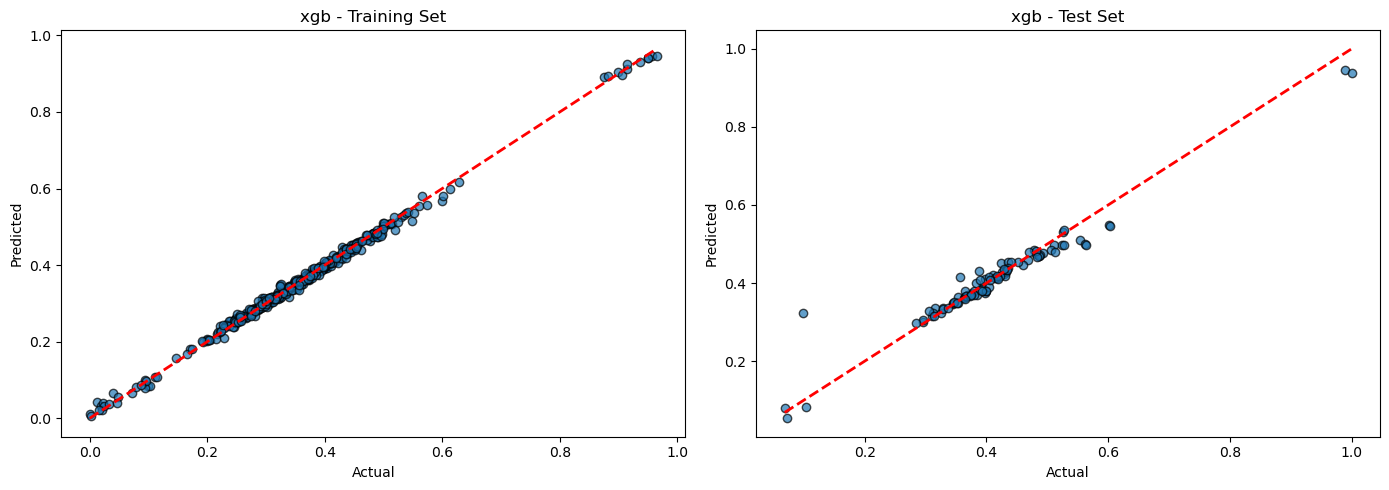


dt Evaluation:
RMSE: 0.0394
MAE: 0.0268
R2: 0.9046

dt Overfitting Check:
Training - RMSE: 0.0341, MAE: 0.0163, R2: 0.9391
Test     - RMSE: 0.0394, MAE: 0.0268, R2: 0.9046


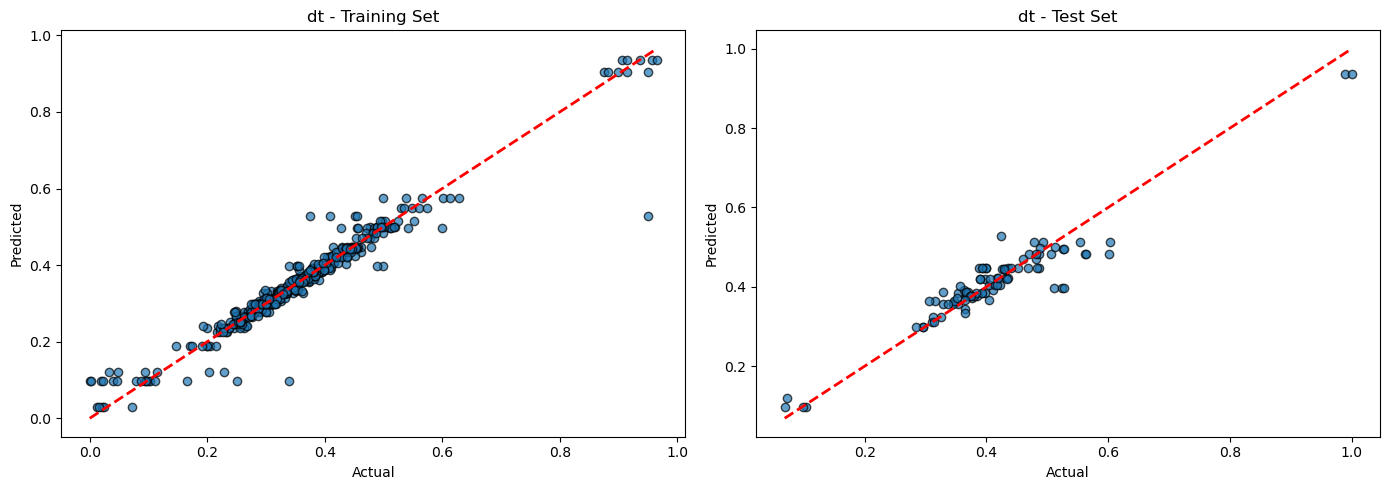


rf Evaluation:
RMSE: 0.0259
MAE: 0.0140
R2: 0.9588

rf Overfitting Check:
Training - RMSE: 0.0094, MAE: 0.0061, R2: 0.9953
Test     - RMSE: 0.0259, MAE: 0.0140, R2: 0.9588


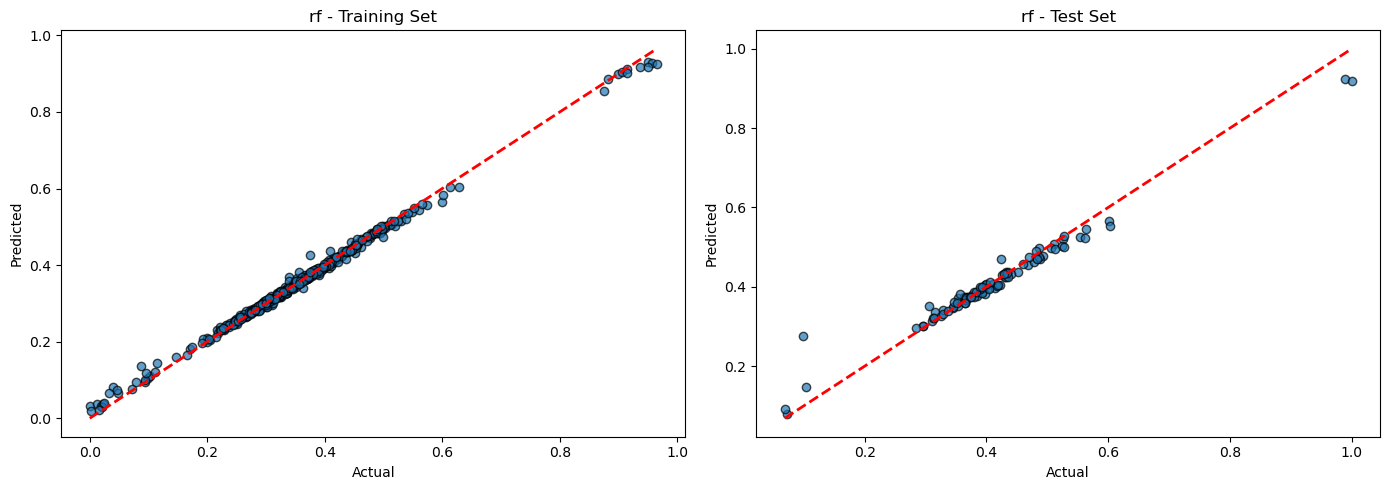


Stacking Ensemble (Hybrid) Evaluation:
RMSE: 0.0164
MAE: 0.0104
R2: 0.9836

Stacking Ensemble (Hybrid) Overfitting Check:
Training - RMSE: 0.0093, MAE: 0.0064, R2: 0.9955
Test     - RMSE: 0.0164, MAE: 0.0104, R2: 0.9836


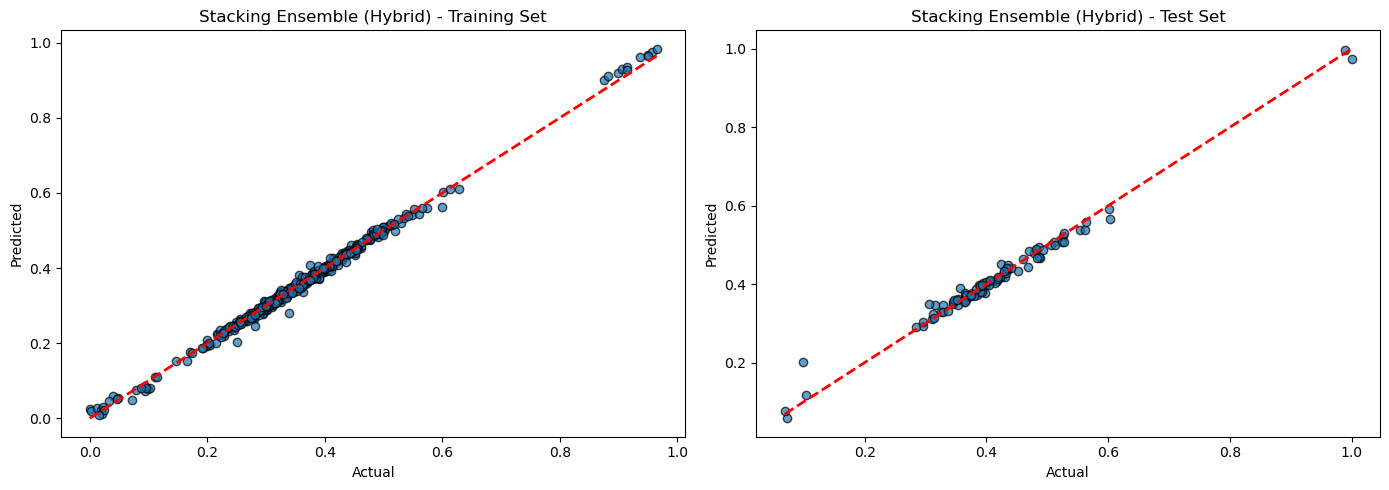

In [359]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, StackingRegressor
from sklearn.linear_model import Ridge
import xgboost as xgb
import shap

# ======================
# 1. Data Loading & Preprocessing
# ======================
def load_and_preprocess_data(file_path):
    df = pd.read_csv(file_path, encoding="latin1")
    
    # Identify measurement columns (those that include "meters below ground level")
    measurement_cols = [col for col in df.columns if "meters below ground level" in col]
    
    # Identifier columns
    id_vars = ['Sr. No.', 'State_Name_With_LGD_Code', 'District_Name_With_LGD_Code', 
               'Block_Name_With_LGD_Code', 'GP_Name_With_LGD_Code', 'Village', 
               'Site_Name', 'TYPE', 'SOURCE', 'Well_ID', 'Latitude', 'Longitude', 
               'Well_Depth (meters)', 'Aquifer']
    
    # Pivot data from wide to long format
    df_long = pd.melt(df, id_vars=id_vars, value_vars=measurement_cols,
                      var_name='Measurement', value_name='Groundwater_Level')
    
    # Extract Season and Year from Measurement column
    df_long[['Season', 'Year']] = df_long['Measurement'].str.extract(r'(Pre-monsoon|Post-monsoon)_(\d{4})')
    df_long['Year'] = df_long['Year'].astype(int)
    
    # Convert groundwater levels to numeric; non-numeric become NaN
    df_long['Groundwater_Level'] = pd.to_numeric(df_long['Groundwater_Level'], errors='coerce')
    
    # Create Month column: assume March for Pre-monsoon, September for Post-monsoon
    df_long['Month'] = df_long['Season'].apply(lambda s: 3 if s=="Pre-monsoon" else 9)
    df_long['Date'] = pd.to_datetime(dict(year=df_long['Year'], month=df_long['Month'], day=1))
    
    df_long.sort_values(by=['Site_Name', 'Date'], inplace=True)
    return df_long, measurement_cols

# ======================
# 2. Site Selection & Feature Engineering
# ======================
def prepare_site_data(df_long):
    # Select site with most measurements
    site_counts = df_long.groupby('Site_Name')['Groundwater_Level'].count()
    selected_site = site_counts.idxmax()
    print("Selected Site:", selected_site)
    
    df_site = df_long[df_long['Site_Name'] == selected_site].copy()
    df_site.sort_values(by='Date', inplace=True)
    df_site.reset_index(drop=True, inplace=True)
    
    # Interpolate missing values
    df_site['Groundwater_Level'] = df_site['Groundwater_Level'].interpolate()
    
    # Normalize groundwater levels
    scaler = MinMaxScaler()
    df_site['Groundwater_Level_scaled'] = scaler.fit_transform(df_site[['Groundwater_Level']])
    
    # Create lag features (1, 2, 3) and rolling mean (window=2)
    for lag in [1, 2, 3]:
        df_site[f'lag_{lag}'] = df_site['Groundwater_Level_scaled'].shift(lag)
    df_site['rolling_mean_2'] = df_site['Groundwater_Level_scaled'].rolling(window=2).mean()
    
    # Add time-based features
    df_site['Year_feat'] = df_site['Year']
    df_site['Month_feat'] = df_site['Month']
    
    # Drop rows with NaN values
    df_site_clean = df_site.dropna().copy()
    return df_site_clean, scaler

# ======================
# 3. Data Preparation for Modeling
# ======================
def prepare_model_data(df_site):
    features = ['lag_1', 'lag_2', 'lag_3', 'rolling_mean_2', 'Year_feat', 'Month_feat']
    target = 'Groundwater_Level_scaled'
    
    X = df_site[features].values
    y = df_site[target].values
    
    # Chronological split: 70% train, 15% validation, 15% test
    n = len(df_site)
    train_end = int(0.7 * n)
    val_end = int(0.85 * n)
    
    X_train, y_train = X[:train_end], y[:train_end]
    X_val, y_val = X[train_end:val_end], y[train_end:val_end]
    X_test, y_test = X[val_end:], y[val_end:]
    
    print(f"Training: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")
    print("Features used:", features)
    return X_train, y_train, X_val, y_val, X_test, y_test, features

# ======================
# 4. Train Base Models for Stacking
# ======================
def get_base_models():
    # Use XGBoost regressor via scikit-learn API for compatibility
    xgb_model = xgb.XGBRegressor(objective='reg:squarederror', max_depth=3,
                                 learning_rate=0.1, n_estimators=100, random_state=42)
    # dt_model = DecisionTreeRegressor(max_depth=10, random_state=42)
    dt_model = DecisionTreeRegressor(
        max_depth=10,
        random_state=42,
        min_samples_split=5,    # require at least 10 samples to split
        min_samples_leaf=5       # require at least 4 samples in a leaf
    )
    rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42)
    return [('xgb', xgb_model), ('dt', dt_model), ('rf', rf_model)]

# ======================
# 5. Train Stacking Ensemble Model
# ======================
def train_stacking_model(X_train, y_train, X_val, y_val):
    from sklearn.ensemble import StackingRegressor
    from sklearn.linear_model import Ridge
    base_models = get_base_models()
    
    # Meta-learner: Ridge regression
    meta_model = Ridge(alpha=1.0)
    
    stack_model = StackingRegressor(estimators=base_models, final_estimator=meta_model, cv=5)
    
    # Train on combined training and validation sets for best performance
    X_stack = np.concatenate([X_train, X_val])
    y_stack = np.concatenate([y_train, y_val])
    stack_model.fit(X_stack, y_stack)
    
    return stack_model

# ======================
# 6. Evaluation Functions
# ======================
def evaluate_model(y_true, y_pred, model_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    print(f"\n{model_name} Evaluation:")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"R2: {r2:.4f}")
    return rmse, mae, r2

def plot_predictions(y_true, y_pred, title):
    plt.figure(figsize=(8,6))
    plt.scatter(y_true, y_pred, alpha=0.7, edgecolors='k')
    plt.plot([y_true.min(), y_true.max()], [y_true.min(), y_true.max()], 'r--', lw=2)
    plt.xlabel("Actual Groundwater Level")
    plt.ylabel("Predicted Groundwater Level")
    plt.title(title)
    plt.show()

def plot_time_series(y_true, preds_dict):
    plt.figure(figsize=(12,6))
    plt.plot(y_true, label="Actual", marker='o')
    for model_name, pred in preds_dict.items():
        plt.plot(pred, label=model_name, marker='x')
    plt.xlabel("Time Step")
    plt.ylabel("Normalized Groundwater Level")
    plt.title("Time Series: Actual vs Predictions")
    plt.legend()
    plt.show()

def plot_residuals(y_true, y_pred, title):
    residuals = y_true - y_pred
    plt.figure(figsize=(8,4))
    plt.hist(residuals, bins=20, edgecolor='black', alpha=0.7)
    plt.xlabel("Residual")
    plt.ylabel("Frequency")
    plt.title(title)
    plt.show()

# ======================
# 7. Main Function
# ======================
def main(file_path):
    # Data loading, preprocessing, feature engineering, etc.
    df_long, _ = load_and_preprocess_data(file_path)
    df_site, scaler = prepare_site_data(df_long)
    X_train, y_train, X_val, y_val, X_test, y_test, features = prepare_model_data(df_site)
    
    # Train and evaluate individual base models
    base_models = get_base_models()
    predictions = {}
    eval_metrics = {}
    
    for name, model in base_models:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        evaluate_model(y_test, y_pred, name)
        predictions[name] = y_pred
        # Check for overfitting
        check_overfitting(model, X_train, y_train, X_test, y_test, model_name=name)
    
    # Train stacking ensemble model
    stack_model = train_stacking_model(X_train, y_train, X_val, y_val)
    y_pred_stack = stack_model.predict(X_test)
    evaluate_model(y_test, y_pred_stack, "Stacking Ensemble (Hybrid)")
    check_overfitting(stack_model, X_train, y_train, X_test, y_test, model_name="Stacking Ensemble (Hybrid)")
    
    # Additional plotting or saving model details
    return {
        'scaler': scaler,
        'features': features,
        'base_models': base_models,
        'stack_model': stack_model,
        'evaluation': eval_metrics
    }
if __name__ == "__main__":
    file_path = "./data.csv"  # Update with your dataset file path
    model_info = main(file_path)
